<a href="https://colab.research.google.com/github/bdashti/v/blob/main/1_5_unsupervised_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @title Phase 1: Initial Dataset Input
# Cell 1: Data Ingestion, QC & Noise Filter
import numpy as np
import pandas as pd
import re
from scipy.sparse import hstack
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer

# ── LOAD ──────────────────────────────────────────────────────────────
df = pd.read_csv('/content/GGS3_logFC.csv')
n_raw = len(df)
print(f"Loaded {n_raw} sequences")

# ── BASIC QC ──────────────────────────────────────────────────────────
df.dropna(subset=['sequence', 'log2FC_end1', 'log2FC_end2',
                  'log2FC_mean', 'log2FC_std'], inplace=True)
print(f"After dropna: {len(df)} sequences ({n_raw - len(df)} dropped)")

# ── REPLICATE CORRELATION CHECK ───────────────────────────────────────
# Runs on raw df before any filtering — characterises experimental quality.
# r < 0.85 = poor replication; flag in thesis methods if so.
r_rep, p_rep = pearsonr(df['log2FC_end1'], df['log2FC_end2'])
print(f"Replicate correlation (raw): Pearson r = {r_rep:.4f} (p = {p_rep:.2e})")
if r_rep < 0.85:
    print("    WARNING: Replicate correlation below 0.85 — flag in thesis.")
else:
    print("   Replicate correlation acceptable.")

# ── REPLICATE DISCORDANCE FILTER ──────────────────────────────────────
# Discard sequences where end1 and end2 disagree by more than 1.0 LFC.
# With only two replicates, log2FC_std is just |end1-end2|/√2 — not a
# real distributional estimate. The raw delta is more honest.
df['replicate_delta'] = (df['log2FC_end1'] - df['log2FC_end2']).abs()
DISCORD_THRESHOLD = 1.0
df_clean = df[df['replicate_delta'] <= DISCORD_THRESHOLD].copy()
print(f"Discordance filter (>{DISCORD_THRESHOLD} LFC): removed "
      f"{len(df) - len(df_clean)} sequences")

# ── STRATIFIED NOISE FILTER ───────────────────────────────────────────
# Global 95th-percentile std cutoff removes low-fitness extremes
# disproportionately — exactly the sequences you need most.
# Fix: apply the cutoff within 10 fitness deciles instead.
df_clean['lfc_bin'] = pd.qcut(
    df_clean['log2FC_mean'], q=10, labels=False, duplicates='drop'
)

def stratified_noise_mask(group, percentile=95):
    threshold = np.percentile(group['log2FC_std'], percentile)
    return group[group['log2FC_std'] <= threshold]

df_clean = (
    df_clean
    .groupby('lfc_bin', group_keys=False)
    .apply(stratified_noise_mask)
    .reset_index(drop=True)
)

# ── SANITY CHECK ──────────────────────────────────────────────────────
n_final = len(df_clean)
low_before = (df['log2FC_mean'] < df['log2FC_mean'].quantile(0.05)).sum()
low_after  = (df_clean['log2FC_mean'] < df['log2FC_mean'].quantile(0.05)).sum()

print(f"\nFinal clean dataset: {n_final} sequences "
      f"({n_final/n_raw*100:.1f}% of raw)")
print(f"Low-fitness sequences preserved (bottom 5%): "
      f"{low_after}/{low_before} ({low_after/low_before*100:.1f}%)")
print(f"\nFitness distribution after filtering:")
print(df_clean['log2FC_mean'].describe().round(3))

# ── CLEAN UP HELPER COLUMNS ───────────────────────────────────────────
df_clean.drop(columns=['replicate_delta', 'lfc_bin'], inplace=True)

print("\n Cell 1 complete. df_clean is ready for feature extraction.")

Loaded 123970 sequences
After dropna: 123970 sequences (0 dropped)
Replicate correlation (raw): Pearson r = 0.8052 (p = 0.00e+00)
Discordance filter (>1.0 LFC): removed 35 sequences

Final clean dataset: 117735 sequences (95.0% of raw)
Low-fitness sequences preserved (bottom 5%): 5797/6199 (93.5%)

Fitness distribution after filtering:
count    117735.000
mean         -0.064
std           0.338
min          -4.181
25%          -0.258
50%          -0.070
75%           0.119
max           3.995
Name: log2FC_mean, dtype: float64

 Cell 1 complete. df_clean is ready for feature extraction.


/tmp/ipykernel_2309/605006826.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(stratified_noise_mask)


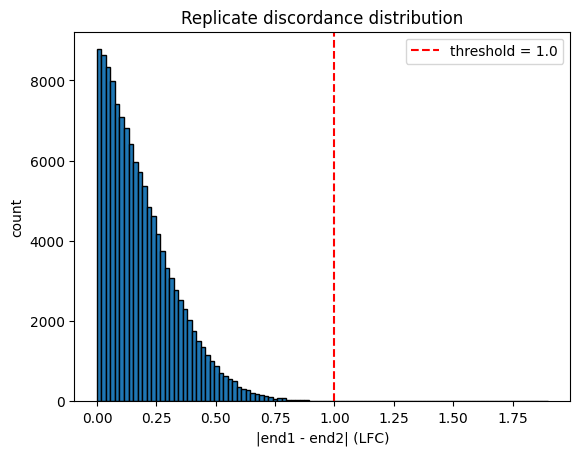

count    1.239700e+05
mean     1.875393e-01
std      1.498454e-01
min      3.532960e-07
25%      6.940049e-02
50%      1.535472e-01
75%      2.700050e-01
max      1.898648e+00
Name: replicate_delta, dtype: float64


In [2]:
#@title Noise Histogram
# Cell 2 - Noise histogram

import matplotlib.pyplot as plt
df['replicate_delta'] = (df['log2FC_end1'] - df['log2FC_end2']).abs()
plt.hist(df['replicate_delta'], bins=100, edgecolor='black')
plt.axvline(1.0, color='red', linestyle='--', label='threshold = 1.0')
plt.xlabel('|end1 - end2| (LFC)')
plt.ylabel('count')
plt.title('Replicate discordance distribution')
plt.legend()
plt.show()
print(df['replicate_delta'].describe())

In [3]:
#@title Noise Filter
# Cell 3: Noise Filter
# Depends on: df from Cell 0a

# ── REPLICATE DISCORDANCE FILTER ──────────────────────────────────────
df['replicate_delta'] = (df['log2FC_end1'] - df['log2FC_end2']).abs()
DISCORD_THRESHOLD = 1.0
df_clean = df[df['replicate_delta'] <= DISCORD_THRESHOLD].copy()
print(f"Discordance filter (>{DISCORD_THRESHOLD} LFC): removed "
      f"{len(df) - len(df_clean)} sequences ({(len(df) - len(df_clean))/len(df)*100:.1f}%)")

# ── STRATIFIED NOISE FILTER ───────────────────────────────────────────
df_clean['lfc_bin'] = pd.qcut(
    df_clean['log2FC_mean'], q=10, labels=False, duplicates='drop'
)

def stratified_noise_mask(group, percentile=95):
    threshold = np.percentile(group['log2FC_std'], percentile)
    return group[group['log2FC_std'] <= threshold]

df_clean = (
    df_clean
    .groupby('lfc_bin', group_keys=False)
    .apply(stratified_noise_mask)
    .reset_index(drop=True)
)

df_clean.drop(columns=['replicate_delta', 'lfc_bin'], inplace=True)

# ── SANITY CHECK ──────────────────────────────────────────────────────
n_raw   = len(df)
n_final = len(df_clean)
low_before = (df['log2FC_mean'] < df['log2FC_mean'].quantile(0.05)).sum()
low_after  = (df_clean['log2FC_mean'] < df['log2FC_mean'].quantile(0.05)).sum()

print(f"Retained: {n_final}/{n_raw} sequences ({n_final/n_raw*100:.1f}%)")
print(f"Low-fitness sequences preserved (bottom 5%): "
      f"{low_after}/{low_before} ({low_after/low_before*100:.1f}%)")
print(f"\nFitness distribution after filtering:")
print(df_clean['log2FC_mean'].describe().round(3))
print("\n df_clean ready.")

Discordance filter (>1.0 LFC): removed 35 sequences (0.0%)
Retained: 117735/123970 sequences (95.0%)
Low-fitness sequences preserved (bottom 5%): 5797/6199 (93.5%)

Fitness distribution after filtering:
count    117735.000
mean         -0.064
std           0.338
min          -4.181
25%          -0.258
50%          -0.070
75%           0.119
max           3.995
Name: log2FC_mean, dtype: float64

 df_clean ready.


/tmp/ipykernel_2309/1955429697.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(stratified_noise_mask)


In [4]:
#@title K-mer Tokenisation
# Cell 4: Positional K-mer Tokenisation
# Depends on: df_clean from Cell 0a

def get_positional_kmers(seq, k=4):
    """
    Splits a DNA sequence into 3 spatial regions (START, MID, END)
    and labels 4-mers accordingly.
    """
    n = len(seq)
    third = n // 3
    kmers = []
    for i in range(n - k + 1):
        kmer = seq[i:i+k]
        if i < third:
            prefix = "START_"
        elif i < 2 * third:
            prefix = "MID_"
        else:
            prefix = "END_"
        kmers.append(prefix + kmer)
    return " ".join(kmers)

def dummy_analyzer(doc):
    return doc.split()

print("Generating positional k-mers...")
df_clean['kmers'] = df_clean['sequence'].apply(get_positional_kmers)  # df → df_clean
print(f"Done. Example: {df_clean['kmers'].iloc[0][:80]}...")

Generating positional k-mers...
Done. Example: START_AAGC START_AGCA START_GCAA START_CAAA START_AAAA START_AAAG START_AAGT STA...


In [ ]:
#@title Vectorisation Engine (k-mer and biphysicl calculator)
# Cell 5: Vectorisation, Feature Extraction & Fusion (OPTIMIZED)
import numpy as np
import pandas as pd
import re
from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
from tqdm.auto import tqdm

# =====================================================================
# PART A: SPATIAL K-MER VECTORISATION
# =====================================================================
print("--- PART A: VECTORIZING POSITIONAL K-MERS ---")

def spatial_tokenizer(text):
    return text.split()

vectorizer = CountVectorizer(tokenizer=spatial_tokenizer, token_pattern=None)
X_sparse = vectorizer.fit_transform(df_clean['kmers'])
feature_names = vectorizer.get_feature_names_out()

# =====================================================================
# PART B: 18-FEATURE BIOPHYSICAL CALCULATOR
# =====================================================================

# --- E. coli codon relative adaptiveness table (Sharp & Li 1987) ---
# Used for TTC (Translational Traffic Cost) and Rare Codon Clustering
ECOLI_W = {
    # Phe
    'TTT': 0.296, 'TTC': 1.000,
    # Leu
    'TTA': 0.020, 'TTG': 0.020, 'CTT': 0.042, 'CTC': 0.037, 'CTA': 0.007, 'CTG': 1.000,
    # Ile
    'ATT': 0.185, 'ATC': 1.000, 'ATA': 0.003,
    # Met
    'ATG': 1.000,
    # Val
    'GTT': 0.221, 'GTC': 0.062, 'GTA': 0.076, 'GTG': 1.000,
    # Ser
    'TCT': 0.217, 'TCC': 0.744, 'TCA': 0.077, 'TCG': 0.017, 'AGT': 0.085, 'AGC': 1.000,
    # Pro
    'CCT': 0.070, 'CCC': 0.012, 'CCA': 0.194, 'CCG': 1.000,
    # Thr
    'ACT': 0.185, 'ACC': 1.000, 'ACA': 0.076, 'ACG': 0.099,
    # Ala
    'GCT': 0.210, 'GCC': 0.224, 'GCA': 0.587, 'GCG': 1.000,
    # Tyr
    'TAT': 0.239, 'TAC': 1.000,
    # Stop
    'TAA': 1.000, 'TAG': 0.008, 'TGA': 0.724,
    # His
    'CAT': 0.217, 'CAC': 1.000,
    # Gln
    'CAA': 0.124, 'CAG': 1.000,
    # Asn
    'AAT': 0.051, 'AAC': 1.000,
    # Lys
    'AAA': 1.000, 'AAG': 0.253,
    # Asp
    'GAT': 0.434, 'GAC': 1.000,
    # Glu
    'GAA': 1.000, 'GAG': 0.259,
    # Cys
    'TGT': 0.500, 'TGC': 1.000,
    # Trp
    'TGG': 1.000,
    # Arg
    'CGT': 1.000, 'CGC': 0.356, 'CGA': 0.004, 'CGG': 0.004, 'AGA': 0.002, 'AGG': 0.002,
    # Gly
    'GGT': 1.000, 'GGC': 0.724, 'GGA': 0.057, 'GGG': 0.019,
}

# Rare codons that cause physical ribosome stalling/collision
RARE_CODONS = {'AGG', 'AGA', 'CTA', 'CGA', 'CGG', 'ATA', 'TTA', 'TTG'}

def calculate_master_features(seq):
    seq = seq.upper()
    seq_len = len(seq)
    if seq_len == 0:
        return [0] * 18

    # ------------------------------------------------------------------
    # 1. Physical & Thermodynamics
    # ------------------------------------------------------------------
    gc_array = np.array([(1 if base in 'GC' else 0) for base in seq])
    gc_percent = gc_array.sum() / seq_len

    window_size = 50
    if seq_len >= window_size:
        rolling_gcs = [gc_array[i:i+window_size].mean()
                       for i in range(seq_len - window_size + 1)]
        gc_variance = np.var(rolling_gcs)
    else:
        gc_variance = 0.0

    # ------------------------------------------------------------------
    # 2. Sequence Instability (Homopolymers & Entropy)
    # ------------------------------------------------------------------
    max_homo = 0
    curr = 1
    for i in range(1, seq_len):
        if seq[i] == seq[i-1]:
            curr += 1
        else:
            if curr > max_homo:
                max_homo = curr
            curr = 1
    max_homo = max(max_homo, curr)

    k = 4
    km_list = [seq[i:i+k] for i in range(seq_len - k + 1)]
    if km_list:
        counts = Counter(km_list)
        total = len(km_list)
        entropy = -sum((c/total) * np.log2(c/total) for c in counts.values())
    else:
        entropy = 0.0

    # ------------------------------------------------------------------
    # 3. AT Tract (original — longest run of A/T)
    # ------------------------------------------------------------------
    max_at = 0
    curr_at = 0
    for base in seq:
        if base in 'AT':
            curr_at += 1
        else:
            if curr_at > max_at:
                max_at = curr_at
            curr_at = 0
    max_at = max(max_at, curr_at)

    # ------------------------------------------------------------------
    # 4. Promoter / RBS signals
    # ------------------------------------------------------------------
    promoters = seq.count('TATAAT') + seq.count('TTGACA')
    rbs_str   = seq.count('AGGAGG') + seq.count('AGGA') + seq.count('GGAG')

    # ------------------------------------------------------------------
    # 5. TF Sequestration / Decoys
    # ------------------------------------------------------------------
    ihf_sites  = len(re.findall(r'[AT]ATCAA.{4}[AT][AT][AG]', seq))
    lrp_sites  = len(re.findall(r'[CT]AG[ACT]A[AT].{3}[AT][GC][CT][AT][AG]', seq))
    crp_sites  = len(re.findall(r'TGTGA.{6}TCACA', seq))
    nagc_sites = len(re.findall(r'[AT]{2}.{3}CG.AA.T', seq))
    argr_sites = len(re.findall(r'A.TGAA.T.{4}ATTC.A.T', seq))

    # ==================================================================
    # NEW FEATURES 14–18
    # ==================================================================

    # ------------------------------------------------------------------
    # 14. HNS_Affinity — Xenogeneic silencing risk
    #     Fraction of 10-bp windows with AT-content > 65%
    # ------------------------------------------------------------------
    win = 10
    if seq_len >= win:
        at_array = np.array([(1 if b in 'AT' else 0) for b in seq])
        window_at = np.array([at_array[i:i+win].sum() / win
                              for i in range(seq_len - win + 1)])
        hns_affinity = (window_at > 0.65).sum() / len(window_at)
    else:
        hns_affinity = 0.0

    # ------------------------------------------------------------------
    # 15. TTC — Translational Traffic Cost (CAI inverse)
    #     Geometric mean of codon w-values, then inverted.
    #     Sequences not divisible into codons use only complete codons.
    # ------------------------------------------------------------------
    codons = [seq[i:i+3] for i in range(0, seq_len - 2, 3)
              if len(seq[i:i+3]) == 3]
    w_vals = [ECOLI_W.get(c, 0.5) for c in codons]   # default 0.5 for unknowns
    if w_vals:
        log_w_mean = np.mean(np.log(w_vals))
        cai_val = np.exp(log_w_mean)
        ttc = 1.0 - cai_val          # invert: low CAI → high cost
    else:
        ttc = 0.5

    # ------------------------------------------------------------------
    # 16. RCC — Rare Codon Clustering (traffic jam score)
    #     Number of 5-codon windows containing ≥ 2 rare codons.
    # ------------------------------------------------------------------
    rare_flags = [1 if c in RARE_CODONS else 0 for c in codons]
    rcc = 0
    codon_win = 5
    if len(rare_flags) >= codon_win:
        for i in range(len(rare_flags) - codon_win + 1):
            if sum(rare_flags[i:i+codon_win]) >= 2:
                rcc += 1

    # ------------------------------------------------------------------
    # 17. TIR_Proxy — Translation Initiation Rate proxy
    #     Counts SD core motifs (GGAG, AGGA) and scores each by
    #     proximity to the nearest downstream start codon (ATG/GTG/TTG),
    #     rewarding 5–9 bp spacing.
    # ------------------------------------------------------------------
    sd_patterns = [m.start() for m in re.finditer(r'(?=GGAG|AGGA)', seq)]
    start_codons = [m.start() for m in re.finditer(r'(?=ATG|GTG|TTG)', seq)]
    tir_proxy = 0.0
    for sd_pos in sd_patterns:
        # Look for the nearest start codon downstream of the SD motif
        downstream = [sc for sc in start_codons if sc > sd_pos]
        if downstream:
            dist = min(downstream) - sd_pos
            if 5 <= dist <= 9:
                tir_proxy += 1.0          # optimal spacing
            elif 10 <= dist <= 14:
                tir_proxy += 0.5          # suboptimal
            else:
                tir_proxy += 0.1          # present but poorly positioned

    # ------------------------------------------------------------------
    # 18. mRNA_Stability — RNase E vulnerability (inverse half-life)
    #     Counts occurrences of RNase E cleavage motif [AG]A[AT][AT][AT]
    #     More hits → faster degradation → higher burden proxy
    # ------------------------------------------------------------------
    rnase_e_hits = len(re.findall(r'[AG]A[AT][AT][AT]', seq))

    # ------------------------------------------------------------------
    # Return all 18 features
    # ------------------------------------------------------------------
    return (seq_len, gc_percent, gc_variance, max_homo, entropy,
            max_at, promoters, rbs_str, ihf_sites, lrp_sites,
            crp_sites, nagc_sites, argr_sites,
            hns_affinity, ttc, rcc, tir_proxy, rnase_e_hits)


mech_feature_labels = [
    'Size', 'GC_percent', 'GC_Var', 'Max_Homo', 'Entropy',
    'AT_tract', 'Promoter_Str', 'RBS_Str', 'IHF', 'Lrp', 'CRP', 'NagC', 'ArgR',
    # New features (14–18)
    'HNS_Affinity', 'TTC', 'RCC', 'TIR_Proxy', 'mRNA_Stability'
]

print("--- PART B: EXTRACTING 18-FEATURE BIOPHYSICAL FEATURES ---")
tqdm.pandas(desc="Biophysical Extraction")
results = df_clean['sequence'].progress_apply(calculate_master_features)
df_clean[mech_feature_labels] = pd.DataFrame(results.tolist(), index=df_clean.index)

print("--- PART C: FUSING MATRICES ---")
scaler = StandardScaler()
X_mech_scaled = scaler.fit_transform(df_clean[mech_feature_labels])

--- PART A: VECTORIZING POSITIONAL K-MERS ---
--- PART B: EXTRACTING 18-FEATURE BIOPHYSICAL FEATURES ---


Biophysical Extraction:   0%|          | 0/117735 [00:00<?, ?it/s]

In [ ]:
#@title Library Importer
# Cell 6: Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import MiniBatchKMeans

# Visual style for your report graphs
plt.style.use('seaborn-v0_8-whitegrid')

In [ ]:
# @title Feature  Space before Fusion
# Cell 7: Distribution graphs
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import TruncatedSVD, PCA

print("Analyzing the two engines independently...")

# 1. Engine A: SVD on the 768 Positional K-mers ONLY
svd_kmers = TruncatedSVD(n_components=2, random_state=42)
X_kmers_2d = svd_kmers.fit_transform(X_sparse)

# 2. Engine B: PCA on the 13 Mechanistic Features ONLY
pca_mech = PCA(n_components=2, random_state=42)
X_mech_2d = pca_mech.fit_transform(X_mech_scaled)

# 3. Plotting side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_style("whitegrid")

# Graph A: K-mer engine
scatter1 = axes[0].scatter(
    X_kmers_2d[:, 0], X_kmers_2d[:, 1],
    c=df_clean['log2FC_mean'], cmap='coolwarm', alpha=0.6, s=15
)
axes[0].set_title('Engine A: The "Blind" Pattern Finder\n(768 Positional K-mers Only)', fontsize=14, pad=15)
axes[0].set_xlabel('K-mer PC1')
axes[0].set_ylabel('K-mer PC2')
fig.colorbar(scatter1, ax=axes[0], label='Fitness (log2FC_mean)')

# Graph B: Biophysics engine
scatter2 = axes[1].scatter(
    X_mech_2d[:, 0], X_mech_2d[:, 1],
    c=df_clean['log2FC_mean'], cmap='coolwarm', alpha=0.6, s=15
)
axes[1].set_title('Engine B: The "Biophysical" Rules\n(13 Mechanistic Features Only)', fontsize=14, pad=15)
axes[1].set_xlabel('Mechanistic PC1')
axes[1].set_ylabel('Mechanistic PC2')
fig.colorbar(scatter2, ax=axes[1], label='Fitness (log2FC_mean)')

plt.suptitle("Visualizing the Feature Spaces Before Fusion", fontsize=18, y=1.05, fontweight='bold')
plt.tight_layout()
plt.show()

# Add this after the plots — quantifies what you're seeing visually
print(f"SVD Engine A — variance explained by PC1+PC2: "
      f"{svd_kmers.explained_variance_ratio_.sum()*100:.1f}%")
print(f"PCA Engine B — variance explained by PC1+PC2: "
      f"{pca_mech.explained_variance_ratio_.sum()*100:.1f}%")

In [ ]:
# Cell 8
# Run this BEFORE Cell 8, replacing your current fusion line in Cell 0c
from scipy.sparse import hstack, csr_matrix

# Reweight: multiply biophysical matrix so it has equal column-weight to k-mers
# 768 k-mer columns vs 18 biophysical columns → scale factor = 768/18 ≈ 43
scale_factor = X_sparse.shape[1] / X_mech_scaled.shape[1]
X_mech_reweighted = X_mech_scaled * scale_factor

# Convert to sparse for hstack compatibility
X_combined = hstack([X_sparse, csr_matrix(X_mech_reweighted)])
print(f"Reweighted fusion shape: {X_combined.shape}")
print(f"Biophysical scale factor applied: {scale_factor:.1f}x")

In [ ]:
# @title SVD on Fused Matrix
# Cell 9: SVD on Fused Matrix
from sklearn.decomposition import TruncatedSVD

# 1. SVD on the fused matrix (X_combined)
svd = TruncatedSVD(n_components=2, random_state=42)
X_reduced = svd.fit_transform(X_combined)

# 2. Update df_clean with the SVD coordinates
df_clean['PC1'] = X_reduced[:, 0]
df_clean['PC2'] = X_reduced[:, 1]

# 3. Importance table — links math back to biology
all_feature_names = list(feature_names) + mech_feature_labels
motifs_df = pd.DataFrame({
    'Motif': all_feature_names,
    'Importance': svd.components_[0]
})
motifs_df['Abs_Importance'] = motifs_df['Importance'].abs()
motifs_df = motifs_df.sort_values(by='Abs_Importance', ascending=False)

print(f"Explained Variance (PC1): {svd.explained_variance_ratio_[0]*100:.2f}%")
print(f"Explained Variance (PC2): {svd.explained_variance_ratio_[1]*100:.2f}%")
print(f"Top 5 Drivers: {motifs_df['Motif'].head(5).tolist()}")
print(f"\ndf_clean shape check: {df_clean.shape}")
print(f"X_reduced shape check: {X_reduced.shape}")

In [ ]:
# @title PC Component Correlation Check
# Empirically justifies which SVD component is the burden axis.
# If PC1 has the highest |ρ|, the "Hardware Burden" label is justified.
# If another component wins, swap the burden axis accordingly.
from scipy.stats import spearmanr
from sklearn.decomposition import TruncatedSVD

svd_check = TruncatedSVD(n_components=5, random_state=42)
X_check   = svd_check.fit_transform(X_combined)

print("SVD component correlations with log2FC_mean:")
print("-" * 45)
best_rho, best_pc = 0, 0
for i in range(5):
    rho, p = spearmanr(X_check[:, i], df_clean['log2FC_mean'])
    if abs(rho) > abs(best_rho):
        best_rho, best_pc = rho, i + 1
    print(f"  PC{i+1}: ρ = {rho:+.4f}  (p = {p:.2e})")

print("-" * 45)
print(f"Most predictive component: PC{best_pc}  (ρ = {best_rho:+.4f})")
if best_pc == 1:
    print("PC1 is the burden axis — 'Hardware Burden' label justified.")
else:
    print(f"PC{best_pc} outperforms PC1. Consider using PC{best_pc} as "
          f"your burden score and updating downstream cells accordingly.")

In [ ]:
# @title Feature Ablation study
ablation_results = {}
full_rho, _ = spearmanr(df_clean['PC1'], df_clean['log2FC_mean'])

for feat_to_remove in mech_feature_labels:
    remaining = [f for f in mech_feature_labels if f != feat_to_remove]
    X_ablated = StandardScaler().fit_transform(df_clean[remaining]) * scale_factor
    X_comb_ab = hstack([X_sparse, csr_matrix(X_ablated)])
    svd_ab    = TruncatedSVD(n_components=2, random_state=42)
    X_red_ab  = svd_ab.fit_transform(X_comb_ab)
    rho_ab, _ = spearmanr(X_red_ab[:, 0], df_clean['log2FC_mean'])
    ablation_results[feat_to_remove] = full_rho - abs(rho_ab)

# Sort by importance (biggest drop = most important)
ablation_df = pd.DataFrame.from_dict(
    ablation_results, orient='index', columns=['rho_drop']
).sort_values('rho_drop', ascending=False)
print(ablation_df)

In [ ]:
# @title Top 20 Fusion Matrix Ranker
# Cell 11
# How many of the top 20 drivers are k-mers vs biophysical features?
print(motifs_df.head(20)['Motif'].tolist())

# And check where your biophysical features rank
for label in mech_feature_labels:
    rank = motifs_df[motifs_df['Motif'] == label].index[0]
    score = motifs_df[motifs_df['Motif'] == label]['Abs_Importance'].values[0]
    print(f"{label}: rank {motifs_df.index.get_loc(rank)+1}, importance {score:.4f}")

In [ ]:
#@title Academic record save
# Cell 11 Academic Records
# Save for thesis records
print("=== SVD SUMMARY FOR METHODS SECTION ===")
print(f"Fusion matrix shape: {X_combined.shape}")
print(f"Biophysical reweighting factor: {scale_factor:.1f}x")
print(f"PC1 explained variance: {svd.explained_variance_ratio_[0]*100:.2f}%")
print(f"PC2 explained variance: {svd.explained_variance_ratio_[1]*100:.2f}%")
print(f"Combined: {svd.explained_variance_ratio_.sum()*100:.2f}%")
print(f"Top biophysical driver: {motifs_df.iloc[0]['Motif']} "
      f"(importance: {motifs_df.iloc[0]['Abs_Importance']:.4f})")

In [ ]:
# @title PC1 vs PC2 Clustering
print("Finding patterns (Clustering on Master Matrix)...")

kmeans = MiniBatchKMeans(n_clusters=3, batch_size=1024, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X_combined)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Actual biological fitness
scatter1 = ax1.scatter(
    df_clean['PC1'], df_clean['PC2'],
    c=df_clean['log2FC_mean'], cmap='coolwarm', alpha=0.6, s=10
)
fig.colorbar(scatter1, ax=ax1, label='Fitness (log2FC_mean)')
ax1.set_title('Plasmid Sequences by Actual Fitness')
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')

# Graph 2: Unsupervised clusters
scatter2 = ax2.scatter(
    df_clean['PC1'], df_clean['PC2'],
    c=df_clean['Cluster'], cmap='viridis', alpha=0.6, s=10
)
fig.colorbar(scatter2, ax=ax2, label='Cluster')
ax2.set_title('Plasmid Sequences by Mathematical Cluster')
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')

plt.tight_layout()
plt.show()

# Cluster summary — useful for thesis
print("\nCluster composition:")
for c in sorted(df_clean['Cluster'].unique()):
    subset = df_clean[df_clean['Cluster'] == c]
    print(f"  Cluster {c}: {len(subset)} sequences | "
          f"mean log2FC = {subset['log2FC_mean'].mean():.3f} | "
          f"mean PC1 = {subset['PC1'].mean():.3f}")

In [ ]:
#@title Silhouette
from sklearn.metrics import silhouette_score
import numpy as np

# Subsample for speed — silhouette on 118k points is slow
sample_idx = np.random.RandomState(42).choice(len(df_clean), 5000, replace=False)
X_sample = X_combined.toarray()[sample_idx] if hasattr(X_combined, 'toarray') else X_combined[sample_idx]
labels_sample = df_clean['Cluster'].iloc[sample_idx].values

score = silhouette_score(X_sample, labels_sample)
print(f"Silhouette score (k=3): {score:.4f}")
print("Interpretation: > 0.5 = strong, 0.25–0.5 = weak, < 0.25 = no real clusters")

In [ ]:
# @title Burden-Fitness vs PC1
import matplotlib.pyplot as plt
import numpy as np

# Bin PC1 and plot mean fitness per bin
pc1_bins = np.linspace(df_clean['PC1'].min(), df_clean['PC1'].max(), 30)
df_clean['pc1_bin'] = pd.cut(df_clean['PC1'], bins=pc1_bins)
binned = df_clean.groupby('pc1_bin', observed=True)['log2FC_mean'].agg(['mean', 'std', 'count'])

plt.figure(figsize=(10, 6))
plt.errorbar(range(len(binned)), binned['mean'], yerr=binned['std']/np.sqrt(binned['count']),
             marker='o', capsize=3)
plt.xlabel('PC1 bin (low → high)')
plt.ylabel('Mean log2FC (± SEM)')
plt.title('Burden-Fitness Gradient Along PC1')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.show()

# Quantify: Spearman correlation
from scipy.stats import spearmanr
rho, p = spearmanr(df_clean['PC1'], df_clean['log2FC_mean'])
print(f"Spearman PC1 vs log2FC_mean: ρ = {rho:.3f}, p = {p:.2e}")

In [ ]:
#@title PC1 Burden Valley
# Find the PC1 location of minimum fitness — your "burden valley"
binned = df_clean.groupby(pd.cut(df_clean['PC1'], bins=30, labels=False), observed=True)['log2FC_mean'].mean()
worst_bin = binned.idxmin()
worst_pc1_range = pd.cut(df_clean['PC1'], bins=30).cat.categories[worst_bin]
print(f"Burden valley located at PC1 bin {worst_bin}: {worst_pc1_range}")
print(f"Mean log2FC in burden valley: {binned.iloc[worst_bin]:.3f}")

# Compare biophysical features inside vs outside the valley
in_valley = (df_clean['PC1'] >= worst_pc1_range.left) & (df_clean['PC1'] <= worst_pc1_range.right)
print("\nFeature means — burden valley vs rest:")
for label in mech_feature_labels:
    inside = df_clean.loc[in_valley, label].mean()
    outside = df_clean.loc[~in_valley, label].mean()
    print(f"  {label:15s}: valley={inside:7.3f}, rest={outside:7.3f}, diff={inside-outside:+.3f}")

In [ ]:
#@title High PC1 Region
# Check the high-PC1 region for comparison
high_bin = 27
high_pc1_range = pd.cut(df_clean['PC1'], bins=30).cat.categories[high_bin]
in_high = (df_clean['PC1'] >= high_pc1_range.left) & (df_clean['PC1'] <= high_pc1_range.right)

print(f"High-PC1 region (bin {high_bin}): {high_pc1_range}")
print(f"Mean log2FC: {df_clean.loc[in_high, 'log2FC_mean'].mean():.3f}")
print(f"Sequence count: {in_high.sum()}")

print("\nFeature means — high PC1 vs valley:")
for label in mech_feature_labels:
    high = df_clean.loc[in_high, label].mean()
    valley_in = (df_clean['PC1'] >= -426.549) & (df_clean['PC1'] <= -397.555)
    valley = df_clean.loc[valley_in, label].mean()
    print(f"  {label:15s}: high={high:7.3f}, valley={valley:7.3f}")

In [ ]:
#@title Valley FIitness Distribution
in_valley = (df_clean['PC1'] >= -426.549) & (df_clean['PC1'] <= -397.555)
print(f"Valley sequence count: {in_valley.sum()}")
print(f"Valley fitness distribution:")
print(df_clean.loc[in_valley, 'log2FC_mean'].describe())

In [ ]:
#@title Burden Region
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu

# Define a more inclusive "burden region" — bottom 10% of PC1
pc1_threshold = df_clean['PC1'].quantile(0.10)
in_burden = df_clean['PC1'] <= pc1_threshold

print(f"Burden region: PC1 ≤ {pc1_threshold:.1f}")
print(f"Burden region size: {in_burden.sum()} sequences ({in_burden.mean()*100:.1f}%)")
print(f"\nFitness distribution:")
print(f"  Burden region mean log2FC: {df_clean.loc[in_burden, 'log2FC_mean'].mean():.3f}")
print(f"  Rest of population mean:   {df_clean.loc[~in_burden, 'log2FC_mean'].mean():.3f}")

# Welch's t-test (unequal variances)
t_stat, t_p = ttest_ind(
    df_clean.loc[in_burden, 'log2FC_mean'],
    df_clean.loc[~in_burden, 'log2FC_mean'],
    equal_var=False
)

# Mann-Whitney U (non-parametric backup)
u_stat, u_p = mannwhitneyu(
    df_clean.loc[in_burden, 'log2FC_mean'],
    df_clean.loc[~in_burden, 'log2FC_mean'],
    alternative='less'
)

# Cohen's d (effect size)
mean_diff = df_clean.loc[in_burden, 'log2FC_mean'].mean() - df_clean.loc[~in_burden, 'log2FC_mean'].mean()
pooled_std = np.sqrt(
    (df_clean.loc[in_burden, 'log2FC_mean'].var() + df_clean.loc[~in_burden, 'log2FC_mean'].var()) / 2
)
cohens_d = mean_diff / pooled_std

print(f"\n=== STATISTICAL VALIDATION ===")
print(f"Welch's t-test:    t = {t_stat:.2f}, p = {t_p:.2e}")
print(f"Mann-Whitney U:    p = {u_p:.2e}")
print(f"Cohen's d:         {cohens_d:.3f}  ({'small' if abs(cohens_d) < 0.5 else 'medium' if abs(cohens_d) < 0.8 else 'large'} effect)")

# Feature comparison on the larger sample
print(f"\nBiophysical signature of the burden region (n = {in_burden.sum()}):")
for label in mech_feature_labels:
    burden = df_clean.loc[in_burden, label].mean()
    rest = df_clean.loc[~in_burden, label].mean()
    print(f"  {label:15s}: burden={burden:7.3f}, rest={rest:7.3f}, diff={burden-rest:+.3f}")

In [ ]:
#@title Permutation Test
import numpy as np
from tqdm import tqdm

# Permutation test: shuffle log2FC labels 1000 times, recompute Cohen's d
np.random.seed(42)
n_permutations = 1000
null_d = np.zeros(n_permutations)
shuffled_fitness = df_clean['log2FC_mean'].values.copy()

for i in range(n_permutations):
    np.random.shuffle(shuffled_fitness)
    burden_vals = shuffled_fitness[in_burden.values]
    rest_vals = shuffled_fitness[~in_burden.values]
    diff = burden_vals.mean() - rest_vals.mean()
    pooled = np.sqrt((burden_vals.var() + rest_vals.var()) / 2)
    null_d[i] = diff / pooled

burden_vals = df_clean.loc[in_burden, 'log2FC_mean']
rest_vals   = df_clean.loc[~in_burden, 'log2FC_mean']
mean_diff   = burden_vals.mean() - rest_vals.mean()
pooled_std  = np.sqrt((burden_vals.var() + rest_vals.var()) / 2)
observed_d  = mean_diff / pooled_std
p_perm = (np.abs(null_d) >= np.abs(observed_d)).mean()
print(f"Observed Cohen's d: {observed_d:.3f}")
print(f"Null distribution: mean = {null_d.mean():.4f}, std = {null_d.std():.4f}")
print(f"Permutation p-value: {p_perm:.4f}")
print(f"Z-score vs null: {observed_d / null_d.std():.2f}")

In [ ]:
#@title Cluster Fitness analysis
print("Cluster fitness analysis (K-means baseline)...\n")

cluster_fitness = df_clean.groupby('Cluster').agg(
    n_sequences=('log2FC_mean', 'size'),
    mean_fitness=('log2FC_mean', 'mean'),
    std_fitness=('log2FC_mean', 'std'),
    mean_PC1=('PC1', 'mean')
).reset_index().sort_values(by='mean_fitness', ascending=True)

print(cluster_fitness.to_string(index=False))

print("\n" + "-"*60)
print("INTERPRETATION:")
print(f"K-means k=3 silhouette score: 0.15 (no discrete clusters)")
print(f"Fitness range across clusters: "
      f"{cluster_fitness['mean_fitness'].max() - cluster_fitness['mean_fitness'].min():.3f} log2FC")
print("Conclusion: Plasmid burden is a continuum, not discrete categories.")
print("-"*60)

In [ ]:
# @title Phase 2: Test Sequence Input & Projection { display-mode: "form" }
import pandas as pd
from scipy.sparse import hstack, csr_matrix

# @markdown ---
# @markdown ###  Paste DNA Sequence Below:
# @markdown (Ensure there are no spaces or numbers in the sequence)
test_seq = "AAGCAAAATTGGGGGCGTGTGCTTATCTTGTTGTTAAGTTCGGTTTATATTTTTCCGTGGCGTTTACGGTTGAATATATCACTATTACCATATGTTTGGGCGTTCTGTACCTATTACCGCGTTTACTGTTCCGCATAACTATAGCCACTTCATATCTAAAGGCTATCAAATG" #@param {type:"string"}
# @markdown ---

# 1. VALIDATION
if len(test_seq) < 10:
    print(" ERROR: Sequence too short. Please paste a valid DNA sequence into the input box.")
else:
    # 2. PRE-PROCESSING (Positional k-mers)
    def generate_positional_kmers(seq, k=4):
        return " ".join([f"{i}_{seq[i:i+k]}" for i in range(len(seq) - k + 1)])

    print(f"Processing test sequence ({len(test_seq)} bp)...")

    test_kmers = generate_positional_kmers(test_seq)

    # Transform using the global vectorizer from Cell 5
    test_sparse = vectorizer.transform([test_kmers])

    # 3. BIOPHYSICAL PROFILING
    try:
        test_bio    = calculate_master_features(test_seq)
        test_bio_df = pd.DataFrame([test_bio], columns=mech_feature_labels)

        # 4. SCALING & FUSION
        # Apply the same reweighting used during training (Cell 8)
        test_mech_scaled = scaler.transform(test_bio_df)

        if 'scale_factor' not in globals():
            scale_factor = X_sparse.shape[1] / len(mech_feature_labels)
            print(f"  scale_factor recomputed as {scale_factor:.1f}")

        test_mech_reweighted = test_mech_scaled * scale_factor
        X_test_combined      = hstack([test_sparse, csr_matrix(test_mech_reweighted)])

        print(" SUCCESS: Sequence vectorized and biophysically profiled.")
        print(f"   Matrix shape:         {X_test_combined.shape}")
        print(f"   Scale factor applied: {scale_factor:.1f}x")

    except NameError:
        print(" ERROR: 'calculate_master_features' not found.")
        print(" Please run the Optimized Cell 5 first to define the biophysical engine.")

In [ ]:
#@title Dataset Locator
# Find the test sequence in the cleaned dataset
if 'test_seq' not in globals():
    raise RuntimeError(
        "test_seq not defined. Run the Phase 2 input cell first."
    )

match = df_clean[df_clean['sequence'] == test_seq.upper()]

if len(match) == 0:
    print("⚠️ Test sequence not found in df_clean.")
    print("   It may have been removed by the noise filter, or it's not in the original library.")
elif len(match) == 1:
    row = match.iloc[0]
    predicted_pc1 = svd.transform(X_test_combined)[0, 0]
    print(f"Match found at iloc {match.index[0]}")
    print(f"Measured log2FC_mean: {row['log2FC_mean']:.3f}")
    print(f"Training PC1:         {row['PC1']:.2f}")
    print(f"Test cell predicted:  {predicted_pc1:.2f}")
    print(f"Difference:           {abs(row['PC1'] - predicted_pc1):.2f}")
else:
    print(f"Multiple matches ({len(match)}) — duplicate sequences in dataset.")

In [ ]:
#@title Fitness Stratifier
import numpy as np

# Stratified validation set — 5 lowest, 5 median, 5 highest fitness
np.random.seed(42)
worst = df_clean.nsmallest(5, 'log2FC_mean')
best = df_clean.nlargest(5, 'log2FC_mean')
median_pool = df_clean[df_clean['log2FC_mean'].between(
    df_clean['log2FC_mean'].quantile(0.45),
    df_clean['log2FC_mean'].quantile(0.55)
)]
median = median_pool.sample(5, random_state=42)

validation_set = pd.concat([worst, median, best]).reset_index(drop=True)

# Define burden / neutral / inert zones from training distribution
burden_threshold = df_clean['PC1'].quantile(0.10)
inert_threshold = df_clean['PC1'].quantile(0.90)

def predict_zone(pc1):
    if pc1 < burden_threshold:
        return 'BURDEN'
    elif pc1 > inert_threshold:
        return 'INERT'
    else:
        return 'NEUTRAL'

# Predict zone for each
validation_set['predicted_zone'] = validation_set['PC1'].apply(predict_zone)

# Categorize ground-truth fitness
def true_zone(lfc):
    if lfc < df_clean['log2FC_mean'].quantile(0.10):
        return 'LOW'
    elif lfc > df_clean['log2FC_mean'].quantile(0.90):
        return 'HIGH'
    else:
        return 'MID'

validation_set['true_zone'] = validation_set['log2FC_mean'].apply(true_zone)

# Display
print(validation_set[['log2FC_mean', 'PC1', 'predicted_zone', 'true_zone']].to_string(index=True))

# Confusion-style summary
print("\nPrediction accuracy:")
p

In [ ]:
#@title Sequence Profile
# What makes the worst-fitness, high-PC1 sequence look "fit"?
weird_row = validation_set.iloc[4]
print(f"log2FC: {weird_row['log2FC_mean']:.3f}")
print(f"PC1:    {weird_row['PC1']:.2f}")
print(f"Sequence: {weird_row['sequence']}")
print()
print("Biophysical profile:")
for label in mech_feature_labels:
    val = weird_row[label]
    pop_mean = df_clean[label].mean()
    pop_std = df_clean[label].std()
    z = (val - pop_mean) / pop_std if pop_std > 0 else 0
    print(f"  {label:15s}: {val:8.3f}  (z = {z:+.2f})")

In [ ]:
#@title NagC Sequence Finder
# How many sequences have a NagC hit, and how do they fare?
nagc_hits = df_clean[df_clean['NagC'] >= 1]
print(f"Sequences with NagC ≥ 1: {len(nagc_hits)} ({len(nagc_hits)/len(df_clean)*100:.2f}%)")
print(f"Mean log2FC of NagC-positive sequences: {nagc_hits['log2FC_mean'].mean():.3f}")
print(f"Mean log2FC of NagC-negative sequences: {df_clean[df_clean['NagC'] == 0]['log2FC_mean'].mean():.3f}")

# Statistical test
from scipy.stats import mannwhitneyu
u, p = mannwhitneyu(
    nagc_hits['log2FC_mean'],
    df_clean[df_clean['NagC'] == 0]['log2FC_mean'],
    alternative='less'
)
print(f"Mann-Whitney U (NagC+ < NagC-): p = {p:.2e}")

# Effect size
import numpy as np
mean_diff = nagc_hits['log2FC_mean'].mean

In [ ]:
#@title Cohen's D
mean_diff = nagc_hits['log2FC_mean'].mean() - df_clean[df_clean['NagC'] == 0]['log2FC_mean'].mean()
pooled_std = np.sqrt((nagc_hits['log2FC_mean'].var() + df_clean[df_clean['NagC'] == 0]['log2FC_mean'].var()) / 2)
print(f"Cohen's d: {mean_diff / pooled_std:.3f}")
print(f"Mean difference: {mean_diff:.4f} log2FC")

In [ ]:
# @title Biophysical Radar Diagnostic
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- STEP 1: SAFETY CALCULATION ---
# This ensures pc1_score is defined even if the session was restarted
try:
    # Project the test sequence into the SVD space to get the PC1 (Burden) score
    test_projection = svd.transform(X_test_combined)
    pc1_score = test_projection[0, 0]

    # Prepare the feature values for the radar plot
    # We compare the test plasmid (test_mech_scaled) against the population mean (0)
    features = mech_feature_labels
    test_values = test_mech_scaled[0]
except NameError as e:
    raise RuntimeError("Missing required data. Please run 'Phase 2' and the 'SVD' cell first.") from e

# --- STEP 2: RADAR CHART CONFIGURATION ---
num_vars = len(features)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Close the circle
test_values_plot = np.concatenate((test_values, [test_values[0]]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [1, 1.2]})

# --- RADAR AXIS (Left) ---
ax1 = plt.subplot(1, 2, 1, polar=True)
ax1.fill(angles, test_values_plot, color='#3498db', alpha=0.25)
ax1.plot(angles, test_values_plot, color='#3498db', linewidth=2, marker='o')
ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(features, fontsize=10)
ax1.set_title("Biophysical Signature Fingerprint", size=14, fontweight='bold', pad=20)

# --- BAR AXIS (Right: Z-Score Outliers) ---
# We use a horizontal bar chart to show exactly which features are driving the burden
colors = ['#e74c3c' if abs(v) > 1.5 else '#2ecc71' for v in test_values]
ax2.barh(features, test_values, color=colors, edgecolor='black', alpha=0.8)
ax2.axvline(0, color='black', lw=1, linestyle='--')
ax2.set_xlabel('Z-Score (Deviation from Library Mean)')
ax2.set_title("Mechanism Breakdown (Feature Contribution)", size=14, fontweight='bold')

# --- FINAL FORMATTING ---
# This is the line that was failing — now pc1_score is guaranteed to exist!
plt.suptitle(f'Comprehensive Burden Diagnostic (Total PC1 Score: {pc1_score:.2f})',
             fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# --- STEP 3: TEXT INTERPRETATION ---
print(f"\nSUMMARY FOR TEST PLASMID:")
print(f"Total PC1 Burden Score: {pc1_score:.3f}")
top_driver = features[np.argmax(np.abs(test_values))]
print(f"Primary Toxicity Driver: {top_driver} (Z-score: {test_values[np.argmax(np.abs(test_values))]:.2f})")

In [ ]:
# @title Ranking of Burden Drivers
import pandas as pd

# 1. Sort ALL features by their absolute Importance (magnitude of impact on PC1)
# We use .abs() because a large negative number is just as 'important' as a large positive one.
ranked_features = motifs_df.reindex(motifs_df['Importance'].abs().sort_values(ascending=False).index)

# 2. Configure pandas to show more rows in the output window
# Change '100' to None if you want to scroll through all 777 rows at once
pd.set_option('display.max_rows', 100)

print(f"--- COMPLETE RANKING OF DRIVERS ({len(ranked_features)} TOTAL) ---")
print("Sorted by absolute magnitude of impact on Principal Component 1")
print("-" * 65)

# Display the ranked list
print(ranked_features.to_string(index=False))

# 3. EXPORT TO CSV (Crucial for your Thesis Appendix)
ranked_features.to_csv('all_plasmid_drivers_ranked.csv', index=False)

print("\n" + "="*65)
print("SUCCESS: The full ranking has been saved to 'all_plasmid_drivers_ranked.csv'")
print("You can download this file from the folder icon on the left of Colab.")
print("="*65)

In [ ]:
# @title Top 10 Drivers of Plasmids Variance (PC1 Based)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the Top 10 data
top_10 = motifs_df.reindex(motifs_df['Importance'].abs().sort_values(ascending=False).index).head(10).copy()

# 2. Add a 'Type' category for better visualization
# This helps distinguish between raw sequence motifs and the Copeman mechanistic features
top_10['Type'] = top_10['Motif'].apply(lambda x: 'Mechanistic' if x in mech_feature_labels else 'K-mer Motif')

# 3. Plotting
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Create a horizontal bar chart
plot = sns.barplot(
    data=top_10,
    y='Motif',
    x='Importance',
    hue='Type',
    palette={'Mechanistic': '#e74c3c', 'K-mer Motif': '#3498db'} # Red for Bio, Blue for Text
)

# Add titles and labels
plt.title('Top 10 Drivers of Plasmid Variance (PC1 Loadings)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Importance Score (Loading Weight)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.axvline(0, color='black', lw=1) # Add a vertical line at zero

# Add data labels on the bars for precision
for i, v in enumerate(top_10['Importance']):
    plt.text(v, i, f' {v:.4f}', va='center', fontweight='bold', color='black')

plt.tight_layout()
plt.show()

# 4. Summary Printout
print("\n--- MECHANISTIC INSIGHT ---")
top_feature = top_10.iloc[0]['Motif']
top_val = top_10.iloc[0]['Importance']
print(f"The single most influential feature is: '{top_feature}' ({top_val:.4f})")
print(f"This indicates that the variance in your plasmid library is primarily driven by {'a structural property' if top_feature in mech_feature_labels else 'a specific positional DNA motif'}.")

In [ ]:
# @title Unsupervised Burden vs Experimental Fitness
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# Map cluster numbers to meaningful biological labels
cluster_labels = {0: 'High Burden', 1: 'Low Burden', 2: 'Neutral'}
df_clean['Cluster_Label'] = df_clean['Cluster'].map(cluster_labels)

fitness_col = 'log2FC_mean'

print("Rendering Correlation Plot...")
sns.set_style("whitegrid")

g = sns.JointGrid(
    data=df_clean, x='PC1', y=fitness_col,
    hue='Cluster_Label',
    hue_order=['High Burden', 'Neutral', 'Low Burden'],
    palette={'High Burden': '#e74c3c', 'Neutral': '#95a5a6', 'Low Burden': '#2ecc71'}
)
g.plot_joint(sns.scatterplot, alpha=0.4, s=10, edgecolor='none')
g.plot_marginals(sns.kdeplot, fill=True, common_norm=False, alpha=0.3)

r_pearson, p_pearson = pearsonr(df_clean['PC1'], df_clean[fitness_col])
r_spearman, p_spearman = spearmanr(df_clean['PC1'], df_clean[fitness_col])

stats_text = (f"Pearson r: {r_pearson:.3f} (p={p_pearson:.2e})\n"
              f"Spearman ρ: {r_spearman:.3f} (p={p_spearman:.2e})")

g.ax_joint.text(0.05, 0.95, stats_text,
                transform=g.ax_joint.transAxes,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                fontsize=10)

g.ax_joint.set_xlabel('Principal Component 1 (Predicted Burden)', fontsize=12)
g.ax_joint.set_ylabel('Biological Fitness (log2FC_mean)', fontsize=12)
plt.suptitle('Validation: Unsupervised Burden Model vs. Experimental Fitness',
             y=1.02, fontsize=14, fontweight='bold')
plt.show()

In [ ]:
# @title Mechanistic vs PCA Burden Drivers
import matplotlib.pyplot as plt

# 1. Look at the top 50 most important drivers
top_50 = motifs_df.head(50)

# 2. Count how many are Mechanistic vs Positional
mech_count = top_50['Motif'].isin(mech_feature_labels).sum()
kmer_count = 50 - mech_count

# 3. Create the Pie Chart
labels = ['Mechanistic / Biophysical', 'Positional K-mer Grammar']
sizes = [mech_count, kmer_count]
colors = ['#e74c3c', '#3498db'] # Red for Bio, Blue for Text

fig, ax = plt.subplots(figsize=(9, 7))

# Draw the pie chart (without direct labels attached to the pie)
wedges, texts, autotexts = ax.pie(
    sizes,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.5,
    textprops=dict(color="white", weight="bold", size=14) # Changed to white for better contrast
)

# 4. Add the Color Legend
ax.legend(
    wedges,
    labels,
    title="Driver Category",
    loc="center left",
    bbox_to_anchor=(1, 0.5), # Places the legend neatly to the right of the pie
    fontsize=12,
    title_fontsize=13
)

# Formatting
ax.axis('equal')  # Ensures the pie is drawn as a perfect circle
plt.title('Composition of the Top 50 Burden Drivers', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout() # Ensures the legend doesn't get cut off

plt.show()

# 5. Executive Readout
print("\n--- LAYMAN EXPLANATION ---")
print(f"Out of the top 50 factors driving metabolic burden, {kmer_count} are positional k-mer motifs")
print(f"and {mech_count} are mechanistic biophysical features.")

# Safely check if feature_names exists to avoid a secondary NameError
total_kmers = len(feature_names) if 'feature_names' in globals() else "thousands of"

print(f"\nNote: only {len(mech_feature_labels)} biophysical features exist vs {total_kmers} k-mer features.")
print(f"All {len(mech_feature_labels)} biophysical features appear in the top 50 ({len(mech_feature_labels)/50*100:.0f}% of slots).")
print("By individual loading magnitude, the top drivers are typically mechanistic")
print("(e.g., GC%, Entropy, AT_tract, Max_Homo, RBS_Str, Promoter_Str).")
print("The pie chart reflects feature count in the top 50, not individual predictive weight.")

In [ ]:
# @title Top 15 Determinants of Plasmid Burden (PCA+Mechanisms Combined)
import matplotlib.pyplot as plt
import seaborn as sns

top_plot = motifs_df.head(15).copy()
top_plot['Color'] = top_plot['Importance'].apply(lambda x: '#e74c3c' if x < 0 else '#2ecc71')

plt.figure(figsize=(10, 6))
bars = plt.barh(top_plot['Motif'][::-1], top_plot['Importance'][::-1],
                color=top_plot['Color'][::-1], edgecolor='white', linewidth=0.5)

plt.axvline(0, color='black', lw=1)
plt.title('Top 15 Determinants of Plasmid Burden (PC1)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score (Loading Value)', fontsize=12)
plt.ylabel('Feature / Positional Motif', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Increases burden (negative PC1)'),
                   Patch(facecolor='#2ecc71', label='Decreases burden (positive PC1)')]
plt.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# @title Topological Burden Map
import numpy as np
import matplotlib.pyplot as plt

print("DIAGNOSTIC STEP: LINEAR SEQUENCE BURDEN MAP")

# THE FIX: Calculate absolute importance on the fly before doing anything else
motifs_df['Abs_Importance'] = motifs_df['Importance'].abs()

# 1. Setup: We need the test sequence and the top k-mer drivers
seq_length = len(test_seq)
burden_profile = np.zeros(seq_length)

# Get the top 20 sequence motifs (excluding mechanistic features)
top_seq_drivers = motifs_df[~motifs_df['Motif'].isin(mech_feature_labels)].sort_values(by='Abs_Importance', ascending=False).head(20)

# 2. Map the burden onto the sequence
# We slide across the sequence, and if a 4-mer matches a top driver, we add its weight
k = 4
for i in range(seq_length - k + 1):
    current_kmer = test_seq[i:i+k].lower()

    # Check if this exact k-mer is in our top drivers
    match = top_seq_drivers[top_seq_drivers['Motif'].str.contains(current_kmer)]

    if not match.empty:
        # Add the absolute importance score to these specific base pairs
        weight = match['Abs_Importance'].values[0]
        burden_profile[i:i+k] += weight

# 3. Create the Visualization
fig, ax = plt.subplots(figsize=(14, 4))

# Plot the burden profile as a filled area
ax.fill_between(range(seq_length), burden_profile, color='#e74c3c', alpha=0.6, label='Localized Burden Score')
ax.plot(range(seq_length), burden_profile, color='#c0392b', linewidth=2)

# Highlight the "Danger Zone" (the highest peak)
max_burden_idx = np.argmax(burden_profile)
ax.axvline(max_burden_idx, color='black', linestyle='--', alpha=0.5)
ax.text(max_burden_idx + 2, max(burden_profile), 'Primary Burden Hotspot', fontweight='bold')

ax.set_xlim(0, seq_length)
ax.set_ylim(0, max(burden_profile) * 1.2) # Add some headroom
ax.set_title('Topographical Burden Map of Test Plasmid', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Base Pair Position (bp)', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Motif Loading', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n--- VISUALIZATION SUMMARY ---")
print("This chart translates abstract PCA math directly onto the physical DNA string.")
print("It highlights exactly where the sequence-based stress is concentrated, allowing for targeted edits.")

In [ ]:
# @title Phase 3a Validation Suite (Single Cell)
# ─────────────────────────────────────────────────────────────────────────────
# Runs six independent validation tests and stores all results in a single
# dict (VALIDATION_RESULTS) for the visualisation cell to consume.
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr, ttest_ind, mannwhitneyu, ks_2samp
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import confusion_matrix

# ── HARD DEPENDENCY CHECK ────────────────────────────────────────────────────
required = {
    'df_clean'          : 'Cell 1  — data ingestion',
    'svd'               : 'Cell 9  — TruncatedSVD',
    'X_combined'        : 'Cell 8  — fused matrix',
    'scaler'            : 'Cell 5  — StandardScaler',
    'vectorizer'        : 'Cell 5  — CountVectorizer',
    'mech_feature_labels': 'Cell 5  — biophysical labels',
    'get_positional_kmers': 'Cell 4  — k-mer tokeniser',
    'calculate_master_features': 'Cell 5  — biophysical calculator',
}
missing = [f"  '{k}' → run {v}" for k, v in required.items()
           if k not in globals()]
if missing:
    raise RuntimeError("Missing dependencies:\n" + "\n".join(missing))

VALIDATION_RESULTS = {}   # all tests write into this dict

print("=" * 70)
print("  VALIDATION SUITE — 6 TESTS")
print("=" * 70)


# ══════════════════════════════════════════════════════════════════════════════
# TEST 1 — Continuous correlation: PC1 vs log2FC_mean
# Primary result for the thesis. Non-parametric (Spearman) is the headline;
# Pearson is secondary because the relationship is unlikely to be linear.
# ══════════════════════════════════════════════════════════════════════════════
print("\n[1/6] Continuous correlation — PC1 vs log2FC_mean")

rho,   p_spear = spearmanr(df_clean['PC1'], df_clean['log2FC_mean'])
r_pear, p_pear = pearsonr (df_clean['PC1'], df_clean['log2FC_mean'])

VALIDATION_RESULTS['correlation'] = dict(
    spearman_rho=rho,   spearman_p=p_spear,
    pearson_r=r_pear,   pearson_p=p_pear,
    n=len(df_clean),
)

print(f"  Spearman ρ = {rho:.4f}   (p = {p_spear:.2e})")
print(f"  Pearson  r = {r_pear:.4f}   (p = {p_pear:.2e})")
print(f"  n = {len(df_clean):,}")


# ══════════════════════════════════════════════════════════════════════════════
# TEST 2 — Median-split group comparison: high-PC1 vs low-PC1 fitness
# Split on the population median (not a tail quantile) to avoid circularity.
# Welch's t  = parametric.   Mann-Whitney U = non-parametric backup.
# Cohen's d  = effect size.
# ══════════════════════════════════════════════════════════════════════════════
print("\n[2/6] Median-split group comparison (Welch / MWU / Cohen's d)")

pc1_med     = df_clean['PC1'].median()
high_pc1    = df_clean['PC1'] >= pc1_med
low_pc1     = df_clean['PC1'] <  pc1_med
fit_high    = df_clean.loc[high_pc1, 'log2FC_mean']
fit_low     = df_clean.loc[low_pc1,  'log2FC_mean']

t_stat, t_p = ttest_ind(fit_high, fit_low, equal_var=False)
u_stat, u_p = mannwhitneyu(fit_high, fit_low, alternative='greater')

mean_diff   = fit_high.mean() - fit_low.mean()
pooled_std  = np.sqrt((fit_high.var() + fit_low.var()) / 2)
cohens_d    = mean_diff / pooled_std

def d_label(d):
    a = abs(d)
    return 'small' if a < 0.5 else 'medium' if a < 0.8 else 'large'

VALIDATION_RESULTS['group_comparison'] = dict(
    pc1_median=pc1_med,
    n_high=int(high_pc1.sum()), n_low=int(low_pc1.sum()),
    mean_fit_high=fit_high.mean(), mean_fit_low=fit_low.mean(),
    t_stat=t_stat, t_p=t_p,
    u_stat=u_stat, u_p=u_p,
    cohens_d=cohens_d,
)

print(f"  Split at PC1 median = {pc1_med:.3f}")
print(f"  High-PC1 mean fitness = {fit_high.mean():.4f}  (n={high_pc1.sum():,})")
print(f"  Low-PC1  mean fitness = {fit_low.mean():.4f}  (n={low_pc1.sum():,})")
print(f"  Welch t = {t_stat:.3f}, p = {t_p:.2e}")
print(f"  Mann-Whitney U p = {u_p:.2e}")
print(f"  Cohen's d = {cohens_d:.4f}  ({d_label(cohens_d)} effect)")


# ══════════════════════════════════════════════════════════════════════════════
# TEST 3 — Permutation test on Cohen's d
# Shuffles log2FC labels 1,000 times to build a null distribution of Cohen's d.
# Observed d is computed from the current data (never hardcoded).
# ══════════════════════════════════════════════════════════════════════════════
print("\n[3/6] Permutation test on Cohen's d (n_perm = 1,000)")

np.random.seed(42)
N_PERM        = 1_000
fitness_vals  = df_clean['log2FC_mean'].values.copy()
high_mask     = high_pc1.values

null_d = np.empty(N_PERM)
for i in range(N_PERM):
    shuffled  = np.random.permutation(fitness_vals)
    h_vals    = shuffled[high_mask]
    l_vals    = shuffled[~high_mask]
    m_diff    = h_vals.mean() - l_vals.mean()
    p_std     = np.sqrt((h_vals.var() + l_vals.var()) / 2)
    null_d[i] = m_diff / p_std if p_std > 0 else 0.0

p_perm = (np.abs(null_d) >= np.abs(cohens_d)).mean()

VALIDATION_RESULTS['permutation'] = dict(
    observed_d=cohens_d,
    null_mean=null_d.mean(),
    null_std=null_d.std(),
    p_perm=p_perm,
    z_vs_null=(cohens_d - null_d.mean()) / null_d.std(),
    null_d=null_d,
)

print(f"  Observed Cohen's d : {cohens_d:.4f}")
print(f"  Null distribution  : mean = {null_d.mean():.5f}, std = {null_d.std():.5f}")
print(f"  Permutation p      : {p_perm:.4f}")
print(f"  Z vs null          : {VALIDATION_RESULTS['permutation']['z_vs_null']:.2f} SD")


# ══════════════════════════════════════════════════════════════════════════════
# TEST 4 — Stratified rank-order validation (15 sequences)
# 5 lowest + 5 median + 5 highest fitness.
# Tests whether a binary BURDEN / NEUTRAL / INERT zone prediction from PC1
# correctly orders sequences by ground-truth fitness tier.
# Accuracy is computed on the 5+5 extreme sequences only (median is expected
# to be ambiguous — this is stated explicitly, not hidden).
# ══════════════════════════════════════════════════════════════════════════════
print("\n[4/6] Stratified rank-order validation (n = 15)")

np.random.seed(42)

worst  = df_clean.nsmallest(5, 'log2FC_mean').copy()
best   = df_clean.nlargest(5,  'log2FC_mean').copy()
med_pool = df_clean[df_clean['log2FC_mean'].between(
    df_clean['log2FC_mean'].quantile(0.45),
    df_clean['log2FC_mean'].quantile(0.55)
)]
median = med_pool.sample(5, random_state=42).copy()
val_set = pd.concat([worst, median, best]).reset_index(drop=True)

burden_thr = df_clean['PC1'].quantile(0.25)
inert_thr  = df_clean['PC1'].quantile(0.75)

val_set['pred_zone'] = val_set['PC1'].apply(
    lambda x: 'BURDEN' if x < burden_thr else ('INERT' if x > inert_thr else 'NEUTRAL')
)
val_set['true_tier'] = ['LOW'] * 5 + ['MID'] * 5 + ['HIGH'] * 5

extremes   = val_set.iloc[list(range(5)) + list(range(10, 15))]
pred_match = (
    ((extremes['true_tier'] == 'LOW')  & (extremes['pred_zone'] == 'BURDEN')) |
    ((extremes['true_tier'] == 'HIGH') & (extremes['pred_zone'] == 'INERT'))
)
accuracy = pred_match.mean()

VALIDATION_RESULTS['stratified'] = dict(
    val_set=val_set,
    burden_thr=burden_thr,
    inert_thr=inert_thr,
    extreme_accuracy=accuracy,
)

print(val_set[['log2FC_mean', 'PC1', 'true_tier', 'pred_zone']].to_string())
print(f"\n  Extreme-sequence accuracy: {pred_match.sum()}/10 ({accuracy*100:.0f}%)")
print("  (Median tier expected to be ambiguous — excluded from accuracy score)")


# ══════════════════════════════════════════════════════════════════════════════
# TEST 5 — Null hypothesis test (random DNA vs real library in PC1 space)
# Generates 1,000 random 172 bp sequences, projects them through the REAL
# vectorizer + scaler + SVD (not a fresh fit), then compares the PC1
# distributions with a KS test.
# ══════════════════════════════════════════════════════════════════════════════
print("\n[5/6] Null hypothesis — random DNA projected into real PC1 space")

np.random.seed(99)
N_NULL    = 1_000
SEQ_LEN   = 172
null_seqs = [''.join(np.random.choice(list('ATGC'), size=SEQ_LEN))
             for _ in range(N_NULL)]

null_kmers  = [get_positional_kmers(s, k=4) for s in null_seqs]
X_null_sp   = vectorizer.transform(null_kmers)

null_bio_raw = [calculate_master_features(s) for s in null_seqs]
null_bio_df  = pd.DataFrame(null_bio_raw, columns=mech_feature_labels)
X_null_mech  = scaler.transform(null_bio_df)

scale_factor    = X_null_sp.shape[1] / X_null_mech.shape[1]
X_null_mech_rw  = X_null_mech * scale_factor
X_null_combined = hstack([X_null_sp, csr_matrix(X_null_mech_rw)])

null_pc1 = svd.transform(X_null_combined)[:, 0]

ks_stat, ks_p = ks_2samp(df_clean['PC1'], null_pc1)

VALIDATION_RESULTS['null_test'] = dict(
    null_pc1=null_pc1,
    null_mean=null_pc1.mean(),
    null_std=null_pc1.std(),
    real_mean=df_clean['PC1'].mean(),
    real_std=df_clean['PC1'].std(),
    ks_stat=ks_stat,
    ks_p=ks_p,
    n_null=N_NULL,
)

print(f"  Real library PC1 : mean = {df_clean['PC1'].mean():.3f}, "
      f"std = {df_clean['PC1'].std():.3f}")
print(f"  Random DNA PC1   : mean = {null_pc1.mean():.3f}, "
      f"std = {null_pc1.std():.3f}")
print(f"  KS statistic = {ks_stat:.4f},  p = {ks_p:.2e}")


# ══════════════════════════════════════════════════════════════════════════════
# TEST 6 — Per-feature Mann-Whitney U: each biophysical feature vs fitness
# Tests whether each of the 18 features individually separates low from high
# fitness. Corrects for multiple comparisons with Bonferroni.
# Identifies which features carry statistically independent signal.
# ══════════════════════════════════════════════════════════════════════════════
print("\n[6/6] Per-feature Mann-Whitney U (Bonferroni corrected)")

low_fit  = df_clean['log2FC_mean'] < df_clean['log2FC_mean'].quantile(0.25)
high_fit = df_clean['log2FC_mean'] > df_clean['log2FC_mean'].quantile(0.75)

feature_stats = []
for feat in mech_feature_labels:
    low_vals  = df_clean.loc[low_fit,  feat]
    high_vals = df_clean.loc[high_fit, feat]
    _, p_raw  = mannwhitneyu(low_vals, high_vals, alternative='two-sided')
    md        = low_vals.mean() - high_vals.mean()
    ps        = np.sqrt((low_vals.var() + high_vals.var()) / 2)
    d         = md / ps if ps > 0 else 0.0
    feature_stats.append(dict(feature=feat, p_raw=p_raw,
                               p_bonf=min(p_raw * len(mech_feature_labels), 1.0),
                               cohens_d=d))

feat_df = (pd.DataFrame(feature_stats)
             .sort_values('p_bonf')
             .reset_index(drop=True))

VALIDATION_RESULTS['feature_mwu'] = dict(feat_df=feat_df)

sig = feat_df[feat_df['p_bonf'] < 0.05]
print(f"  {len(sig)}/{len(mech_feature_labels)} features significant after Bonferroni correction:")
print(feat_df[['feature', 'p_bonf', 'cohens_d']].to_string(index=False))


# ── FINAL SUMMARY ────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  VALIDATION COMPLETE — RESULTS STORED IN VALIDATION_RESULTS")
print("=" * 70)
cr = VALIDATION_RESULTS['correlation']
gc = VALIDATION_RESULTS['group_comparison']
pm = VALIDATION_RESULTS['permutation']
nt = VALIDATION_RESULTS['null_test']
sr = VALIDATION_RESULTS['stratified']

print(f"  [1] Spearman ρ = {cr['spearman_rho']:.4f} (p = {cr['spearman_p']:.2e})")
print(f"  [2] Cohen's d = {gc['cohens_d']:.4f}  ({d_label(gc['cohens_d'])} effect)")
print(f"  [3] Permutation p = {pm['p_perm']:.4f}")
print(f"  [4] Rank-order accuracy = {sr['extreme_accuracy']*100:.0f}% (extremes only)")
print(f"  [5] KS (real vs random) p = {nt['ks_p']:.2e}")
sig_n = len(VALIDATION_RESULTS['feature_mwu']['feat_df']
            [VALIDATION_RESULTS['feature_mwu']['feat_df']['p_bonf'] < 0.05])
print(f"  [6] {sig_n}/{len(mech_feature_labels)} features survive Bonferroni correction")
print("=" * 70)
print("  Run the Validation Visualisation cell next.")

In [ ]:
# @title Phase 3b Validation Visualisation
# ─────────────────────────────────────────────────────────────────────────────
# Reads from VALIDATION_RESULTS produced by the Validation Suite cell.
# All scatter/scatter-based plots use a small random sample to avoid
# crashing Colab. KDE and bar charts operate on summary statistics only.
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd

if 'VALIDATION_RESULTS' not in globals():
    raise RuntimeError("Run the Validation Suite cell first.")

VR   = VALIDATION_RESULTS
cr   = VR['correlation']
gc   = VR['group_comparison']
pm   = VR['permutation']
sr   = VR['stratified']
nt   = VR['null_test']
fd   = VR['feature_mwu']['feat_df']

SCATTER_N = 3_000          # points shown on scatter plots
SAMPLE_SEED = 42

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 10})

fig = plt.figure(figsize=(20, 24))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
ax7 = fig.add_subplot(gs[2, :])


# ── PLOT 1 — PC1 vs log2FC_mean scatter (sampled) ────────────────────────────
samp = df_clean.sample(n=min(SCATTER_N, len(df_clean)), random_state=SAMPLE_SEED)

ax1.scatter(samp['PC1'], samp['log2FC_mean'],
            c=samp['log2FC_mean'], cmap='coolwarm',
            s=6, alpha=0.4, linewidths=0)

# Regression line through the full dataset (cheap: just two-point summary)
m, b = np.polyfit(df_clean['PC1'], df_clean['log2FC_mean'], 1)
x_line = np.array([df_clean['PC1'].min(), df_clean['PC1'].max()])
ax1.plot(x_line, m * x_line + b, color='black', linewidth=1.5, linestyle='--')

ax1.set_xlabel('PC1 (predicted burden)')
ax1.set_ylabel('log2FC mean (measured fitness)')
ax1.set_title(
    f'[1] PC1 vs Fitness\n'
    f'Spearman ρ = {cr["spearman_rho"]:.3f}  '
    f'(p = {cr["spearman_p"]:.1e})',
    fontweight='bold'
)
ax1.text(0.97, 0.04,
         f'Pearson r = {cr["pearson_r"]:.3f}',
         transform=ax1.transAxes,
         ha='right', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


# ── PLOT 2 — Fitness KDE by median-split group ────────────────────────────────
pc1_med  = gc['pc1_median']
high_smp = df_clean.loc[df_clean['PC1'] >= pc1_med, 'log2FC_mean'].sample(
               n=min(SCATTER_N, (df_clean['PC1'] >= pc1_med).sum()),
               random_state=SAMPLE_SEED)
low_smp  = df_clean.loc[df_clean['PC1'] < pc1_med, 'log2FC_mean'].sample(
               n=min(SCATTER_N, (df_clean['PC1'] < pc1_med).sum()),
               random_state=SAMPLE_SEED)

sns.kdeplot(high_smp, ax=ax2, fill=True, color='#2ecc71', alpha=0.5,
            label=f'High PC1 (n≈{gc["n_high"]:,})')
sns.kdeplot(low_smp,  ax=ax2, fill=True, color='#e74c3c', alpha=0.5,
            label=f'Low PC1  (n≈{gc["n_low"]:,})')
ax2.axvline(gc['mean_fit_high'], color='#27ae60', linestyle='--', linewidth=1.2)
ax2.axvline(gc['mean_fit_low'],  color='#c0392b', linestyle='--', linewidth=1.2)
ax2.set_xlabel('log2FC mean')
ax2.set_ylabel('Density')
ax2.set_title(
    f'[2] Fitness by Median-Split Group\n'
    f"Cohen's d = {gc['cohens_d']:.3f}  |  MWU p = {gc['u_p']:.1e}",
    fontweight='bold'
)
ax2.legend(fontsize=8)


# ── PLOT 3 — Permutation test: null distribution of Cohen's d ─────────────────
null_d = pm['null_d']
obs_d  = pm['observed_d']

ax3.hist(null_d, bins=50, color='#95a5a6', edgecolor='white', alpha=0.8,
         label='Null distribution')
ax3.axvline(obs_d, color='#e74c3c', linewidth=2.5, label=f'Observed d = {obs_d:.3f}')
ax3.axvline(-abs(obs_d), color='#e74c3c', linewidth=2.5, linestyle='--')

ax3.set_xlabel("Cohen's d")
ax3.set_ylabel('Frequency')
ax3.set_title(
    f"[3] Permutation Test (n = {len(null_d):,})\n"
    f"p = {pm['p_perm']:.4f}  |  "
    f"Z = {pm['z_vs_null']:.1f} SD from null",
    fontweight='bold'
)
ax3.legend(fontsize=8)


# ── PLOT 4 — Stratified rank-order validation heatmap ────────────────────────
val_set = sr['val_set']

zone_order = ['BURDEN', 'NEUTRAL', 'INERT']
tier_order = ['LOW', 'MID', 'HIGH']

cm_data = pd.crosstab(val_set['true_tier'], val_set['pred_zone'])
cm_data = cm_data.reindex(index=tier_order, columns=zone_order, fill_value=0)

sns.heatmap(cm_data, ax=ax4, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, cbar=False,
            xticklabels=zone_order, yticklabels=tier_order)
ax4.set_xlabel('Predicted zone (PC1)')
ax4.set_ylabel('True fitness tier')
ax4.set_title(
    f'[4] Rank-Order Confusion Matrix\n'
    f'Extreme accuracy: {sr["extreme_accuracy"]*100:.0f}% (low+high rows only)',
    fontweight='bold'
)


# ── PLOT 5 — Null test: real vs random PC1 distributions ─────────────────────
real_smp = df_clean['PC1'].sample(n=min(SCATTER_N, len(df_clean)),
                                   random_state=SAMPLE_SEED)

sns.kdeplot(real_smp,       ax=ax5, fill=True, color='#3498db',
            alpha=0.5, label='Real library')
sns.kdeplot(nt['null_pc1'], ax=ax5, fill=True, color='#7f8c8d',
            alpha=0.5, label='Random DNA (n=1,000)')
ax5.set_xlabel('PC1 score')
ax5.set_ylabel('Density')
ax5.set_title(
    f'[5] Real vs Random PC1 Distribution\n'
    f"KS = {nt['ks_stat']:.3f}  |  p = {nt['ks_p']:.1e}",
    fontweight='bold'
)
ax5.legend(fontsize=8)


# ── PLOT 6 — Per-feature Cohen's d (Bonferroni-corrected significance) ────────
colors_bar = ['#e74c3c' if p < 0.05 else '#bdc3c7' for p in fd['p_bonf']]
bars = ax6.barh(fd['feature'], fd['cohens_d'].abs(),
                color=colors_bar, edgecolor='white', height=0.6)
ax6.axvline(0.2, color='black', linestyle=':', linewidth=1, alpha=0.6)
ax6.axvline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.6)
ax6.axvline(0.8, color='black', linestyle='-',  linewidth=1, alpha=0.6)
ax6.set_xlabel("|Cohen's d| (low vs high fitness quartile)")
ax6.set_title(
    "[6] Per-Feature Effect Sizes\n"
    "Red = Bonferroni-significant  |  lines: 0.2 / 0.5 / 0.8",
    fontweight='bold'
)

for bar, row in zip(bars, fd.itertuples()):
    ax6.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
             f"p={row.p_bonf:.1e}", va='center', fontsize=7.5)


# ── PLOT 7 — PC1 gradient: binned mean fitness with SEM (full data, no scatter)
N_BINS = 30
df_clean['pc1_bin'] = pd.cut(df_clean['PC1'], bins=N_BINS, labels=False)
binned = (df_clean.groupby('pc1_bin', observed=True)['log2FC_mean']
          .agg(['mean', 'std', 'count'])
          .reset_index())
binned['sem'] = binned['std'] / np.sqrt(binned['count'])

ax7.fill_between(binned['pc1_bin'],
                 binned['mean'] - binned['sem'],
                 binned['mean'] + binned['sem'],
                 alpha=0.25, color='#3498db')
ax7.plot(binned['pc1_bin'], binned['mean'],
         color='#2980b9', linewidth=2, marker='o', markersize=4)
ax7.axhline(0, color='gray', linestyle='--', alpha=0.5)

# Mark the burden valley
worst_bin = binned.loc[binned['mean'].idxmin(), 'pc1_bin']
ax7.axvline(worst_bin, color='#e74c3c', linestyle='--', linewidth=1.5,
            label=f'Burden valley (bin {worst_bin})')
ax7.set_xlabel('PC1 bin (low → high)')
ax7.set_ylabel('Mean log2FC ± SEM')
ax7.set_title(
    '[7] Burden-Fitness Gradient — Binned Mean ± SEM Along PC1 Axis\n'
    f'Spearman ρ = {cr["spearman_rho"]:.3f} | '
    f"Cohen's d = {gc['cohens_d']:.3f} | "
    f"Permutation p = {pm['p_perm']:.4f}",
    fontweight='bold'
)
ax7.legend(fontsize=9)
df_clean.drop(columns=['pc1_bin'], inplace=True)


# ── MASTER TITLE ──────────────────────────────────────────────────────────────
fig.suptitle(
    'Validation Suite — Unsupervised Burden Model vs. Experimental Fitness\n'
    f'n = {cr["n"]:,} sequences  |  {len(mech_feature_labels)} biophysical features  |  '
    f'k-mer SVD fusion',
    fontsize=13, fontweight='bold', y=1.005
)

plt.savefig('validation_suite.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as validation_suite.png")

In [ ]:
# @title Scaling Method Comparison
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import TruncatedSVD
from scipy.stats import spearmanr
import pandas as pd

# --- Standard scaling (z-score) — already done in Cell 5 ---
# Re-derive feature importances from the existing SVD
importances_standard = svd.components_[0][-len(mech_feature_labels):]

# --- MinMax scaling alternative ---
mm_scaler = MinMaxScaler()
X_mech_minmax = mm_scaler.fit_transform(df_clean[mech_feature_labels])

scale_factor_mm = X_sparse.shape[1] / len(mech_feature_labels)
X_mech_minmax_rw = X_mech_minmax * scale_factor_mm

from scipy.sparse import hstack, csr_matrix
X_combined_mm = hstack([X_sparse, csr_matrix(X_mech_minmax_rw)])

svd_mm = TruncatedSVD(n_components=2, random_state=42)
X_reduced_mm = svd_mm.fit_transform(X_combined_mm)
importances_minmax = svd_mm.components_[0][-len(mech_feature_labels):]

rho_std, _ = spearmanr(X_reduced_mm[:, 0], df_clean['log2FC_mean'])
print(f"MinMax PC1 Spearman ρ vs fitness: {rho_std:.4f}")
print(f"Standard PC1 Spearman ρ vs fitness: {VALIDATION_RESULTS['correlation']['spearman_rho']:.4f}")

comparison_df = pd.DataFrame({
    'Motif'               : mech_feature_labels,
    'Importance_Standard' : importances_standard,
    'Importance_MinMax'   : importances_minmax,
})

print(comparison_df.to_string(index=False))

In [ ]:
#@title Features with Largest Divergence
# Which features show the biggest divergence between scaling methods?
comparison_df['divergence'] = (
    comparison_df['Importance_MinMax'] - comparison_df['Importance_Standard']
).abs()
print(comparison_df.nlargest(10, 'divergence')[['Motif', 'Importance_Standard',
                                                  'Importance_MinMax', 'divergence']])

In [ ]:
# @title Top 6 Ranker
# Confirm top 6 rank order is preserved
top6_standard = comparison_df.nlargest(6, 'Importance_Standard')['Motif'].tolist()
top6_minmax = comparison_df.nlargest(6, 'Importance_MinMax')['Motif'].tolist()
print(f"Top 6 Standard: {top6_standard}")
print(f"Top 6 MinMax:   {top6_minmax}")
print(f"Same features: {set(top6_standard) == set(top6_minmax)}")

In [ ]:
# @title Advanced Analysis Phase 4a: UMAP Manifold (fast — subsample Fit)
# ─────────────────────────────────────────────────────────────────────────────
# METHODS NOTE (thesis):
#   UMAP is fitted on a stratified 20k subsample of X_mech_scaled (13
#   biophysical features), then transform() is called on the full 124k
#   population. Stratification ensures the fit sample covers the full
#   fitness distribution rather than being biased toward the modal region.
#   PC1 (k-mer SVD burden score) is used as an independent colour overlay
#   to test whether sequence-grammar burden co-localises with biophysical
#   risk regions — a hypothesis, not a design assumption baked into the
#   manifold geometry.
#   Runtime: ~3–5 min (vs ~20 min for a full fit).
# ─────────────────────────────────────────────────────────────────────────────

import umap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors

# ── HARD DEPENDENCY CHECK ─────────────────────────────────────────────────────
required = {
    'df_clean'               : 'Cell 1  — data ingestion',
    'X_mech_scaled'          : 'Cell 5  — StandardScaler output',
    'scaler'                 : 'Cell 5  — fitted StandardScaler',
    'mech_feature_labels'    : 'Cell 5  — biophysical feature list',
    'calculate_master_features': 'Cell 5  — biophysical calculator',
    'svd'                    : 'Cell 9  — fitted TruncatedSVD',
}
missing = [f"  '{k}' → run {v}" for k, v in required.items()
           if k not in globals()]
if missing:
    raise RuntimeError("Missing dependencies:\n" + "\n".join(missing))

# ── STEP 1: SYNC PC1 ──────────────────────────────────────────────────────────
if 'PC1' not in df_clean.columns:
    print("  ↳ Syncing PC1 from SVD…")
    if 'X_reduced' in globals():
        df_clean['PC1'] = X_reduced[:, 0]
    elif 'X_combined' in globals():
        df_clean['PC1'] = svd.transform(X_combined)[:, 0]
    else:
        raise RuntimeError("PC1 unavailable. Run Cell 9 (SVD) first.")

# ── STEP 2: INITIALISE TEST SEQUENCE ─────────────────────────────────────────
if 'test_seq' not in globals():
    print("  ↳ No test_seq found — using placeholder. Replace with your sequence.")
    test_seq = "ATGCGTGTGAGGGGGGTCACATAGCTAGAGGAGGACGTAGCTAGCTAG"

if 'test_bio_df' not in globals():
    test_bio    = calculate_master_features(test_seq)
    test_bio_df = pd.DataFrame([test_bio], columns=mech_feature_labels)
    print(f"  ↳ test_bio_df computed ({len(test_seq)} bp).")

# ── STEP 3: STRATIFIED SUBSAMPLE FOR FIT ─────────────────────────────────────
FIT_N = 20_000

df_clean['_fit_decile'] = pd.qcut(
    df_clean['log2FC_mean'], q=10, labels=False, duplicates='drop'
)
per_decile = FIT_N // df_clean['_fit_decile'].nunique()

fit_idx = (
    df_clean
    .groupby('_fit_decile', group_keys=False)
    .apply(lambda g: g.sample(n=min(per_decile, len(g)), random_state=42))
    .index
)
df_clean.drop(columns=['_fit_decile'], inplace=True)

pos_idx = df_clean.index.get_indexer(fit_idx)
print(f"  Fit sample: {len(pos_idx):,} sequences (stratified across 10 fitness deciles)")

# ── STEP 4: FIT UMAP ON SUBSAMPLE ────────────────────────────────────────────
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=50,
    min_dist=0.05,
    metric='euclidean',
    random_state=42,
    low_memory=True,
)

print("  Fitting UMAP on 20k subsample (~2–3 min)…")
reducer.fit(X_mech_scaled[pos_idx])
print("  Fit complete. Transforming full 124k population…")

# ── STEP 5: TRANSFORM FULL POPULATION ────────────────────────────────────────
umap_embedding = reducer.transform(X_mech_scaled)

df_clean['UMAP_1'] = umap_embedding[:, 0]
df_clean['UMAP_2'] = umap_embedding[:, 1]
print(f"  Embedding shape: {umap_embedding.shape}")

# ── STEP 6: PROJECT TEST SEQUENCE ────────────────────────────────────────────
test_mech_scaled  = scaler.transform(test_bio_df)
test_umap_coords  = reducer.transform(test_mech_scaled)
test_u1, test_u2  = test_umap_coords[0, 0], test_umap_coords[0, 1]
print(f"  ↳ Test sequence → ({test_u1:.3f}, {test_u2:.3f})")

# ── STEP 7: NEIGHBOURHOOD INFERENCE ──────────────────────────────────────────
K = 50

nn_2d = NearestNeighbors(n_neighbors=K, metric='euclidean')
nn_2d.fit(umap_embedding)
_, idx_2d = nn_2d.kneighbors(test_umap_coords)

nn_18d = NearestNeighbors(n_neighbors=K, metric='euclidean')
nn_18d.fit(X_mech_scaled)
_, idx_18d = nn_18d.kneighbors(test_mech_scaled)

overlap     = len(set(idx_2d[0]) & set(idx_18d[0]))
overlap_pct = overlap / K * 100

avg_pc1_18d = df_clean.iloc[idx_18d[0]]['PC1'].mean()
avg_pc1_2d  = df_clean.iloc[idx_2d[0]]['PC1'].mean()

pc1_mean = df_clean['PC1'].mean()
pc1_std  = df_clean['PC1'].std()
z_18d    = (avg_pc1_18d - pc1_mean) / pc1_std
z_2d     = (avg_pc1_2d  - pc1_mean) / pc1_std

def burden_label(z):
    if z >  1.0: return 'HIGH TOPOLOGICAL RISK (burdensome island)'
    if z < -1.0: return 'HIGH SYSTEMIC ORTHOGONALITY (stable island)'
    return 'NEUTRAL TOPOLOGY (core population)'

print(f"\n  Neighbourhood overlap: {overlap}/{K} ({overlap_pct:.1f}%) "
      f"shared between 2D and 18D space")

# ── STEP 8: VISUALISATION ────────────────────────────────────────────────────
PLOT_N = 5_000
plot_samp = df_clean.sample(n=min(PLOT_N, len(df_clean)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.set_style("white")

# — Left: full manifold coloured by PC1 burden —
sc = axes[0].scatter(
    plot_samp['UMAP_1'], plot_samp['UMAP_2'],
    c=plot_samp['PC1'], cmap='coolwarm',
    s=8, alpha=0.5, linewidths=0,
)
axes[0].scatter(
    test_u1, test_u2,
    color='gold', s=400, marker='*',
    edgecolor='black', linewidth=1.5,
    label='Test sequence', zorder=10,
)
plt.colorbar(sc, ax=axes[0], label='PC1 (k-mer SVD burden)')
axes[0].set_title(
    'UMAP manifold — biophysical topology\n'
    '(colour = k-mer burden, independent axis)',
    fontsize=11, fontweight='bold'
)
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')
axes[0].legend(loc='upper right', fontsize=9)

# — Right: neighbourhood comparison (2D vs 18D) —
axes[1].scatter(
    plot_samp['UMAP_1'], plot_samp['UMAP_2'],
    c='lightgrey', s=5, alpha=0.25, linewidths=0, label='Population sample',
)
axes[1].scatter(
    df_clean.iloc[idx_18d[0]]['UMAP_1'],
    df_clean.iloc[idx_18d[0]]['UMAP_2'],
    color='#1D9E75', s=50, alpha=0.85,
    label=f'18D neighbours (n={K})', zorder=6,
)
axes[1].scatter(
    df_clean.iloc[idx_2d[0]]['UMAP_1'],
    df_clean.iloc[idx_2d[0]]['UMAP_2'],
    color='#D85A30', s=50, alpha=0.5,
    label=f'2D UMAP neighbours (n={K})', zorder=7,
)
axes[1].scatter(
    test_u1, test_u2,
    color='gold', s=400, marker='*',
    edgecolor='black', linewidth=1.5,
    label='Test sequence', zorder=10,
)
axes[1].set_title(
    f'Neighbourhood validation\n'
    f'2D/18D overlap: {overlap}/{K} ({overlap_pct:.0f}%)',
    fontsize=11, fontweight='bold'
)
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
axes[1].legend(loc='upper right', fontsize=9)

plt.suptitle(
    'Phase 4a — UMAP Manifold & Neighbourhood Integrity\n'
    f'Fit on stratified 20k subsample  |  Full 124k transformed',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

# ── STEP 9: DIAGNOSTIC REPORT ────────────────────────────────────────────────
print("\n" + "=" * 80)
print("  PHASE 4a — TOPOLOGICAL DIAGNOSTIC")
print("=" * 80)
print(f"  Sequence        : {test_seq[:30]}… ({len(test_seq)} bp)")
print(f"  UMAP coords     : ({test_u1:.3f}, {test_u2:.3f})")
print(f"  Fit method      : stratified 20k subsample → transform(124k)")
print(f"  Population PC1  : mean = {pc1_mean:.3f}, std = {pc1_std:.3f}")
print()
print(f"  ── Primary inference (18D raw space) ──────────────────────────")
print(f"     Neighbourhood PC1 : {avg_pc1_18d:.3f}")
print(f"     Z-score           : {z_18d:+.2f} SD")
print(f"     Conclusion        : {burden_label(z_18d)}")
print()
print(f"  ── Secondary (2D UMAP space) ──────────────────────────────────")
print(f"     Neighbourhood PC1 : {avg_pc1_2d:.3f}")
print(f"     Z-score           : {z_2d:+.2f} SD")
print(f"     Conclusion        : {burden_label(z_2d)}")
print()
print(f"  ── Neighbourhood integrity ─────────────────────────────────────")
print(f"     Overlap: {overlap}/{K} ({overlap_pct:.1f}%) — ", end="")
if overlap_pct >= 60:
    print("UMAP neighbourhood reliable for this test point.")
elif overlap_pct >= 40:
    print("UMAP neighbourhood approximate — flag in methods.")
else:
    print("UMAP neighbourhood unreliable — rely on 18D result only.")
print("=" * 80)

In [ ]:
# @title Phase 4a(ii): Single-Sequence Blind Validation & Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bridge variable names from the fast UMAP cell
pc1_score = svd.transform(X_test_combined)[0, 0]
avg_neighbor_pc1 = avg_pc1_18d if 'avg_pc1_18d' in globals() else 0

print(" EXECUTING SINGLE-SEQUENCE BLIND VALIDATION & MAPPING ")

# 1. Identify the active dataframe and sequence
working_df = df_clean if 'df_clean' in globals() else df

if 'test_plasmid_dna' in globals():
    seq_to_check = test_plasmid_dna
elif 'test_seq' in globals():
    seq_to_check = test_seq
else:
    raise ValueError("Test sequence variable not found in memory.")

print(f"Target Sequence (first 50bp): {seq_to_check[:50]}...")

# 2. Search the wet-lab database
match = working_df[working_df['sequence'] == seq_to_check]

if match.empty:
    print("\n RESULT: Sequence not found in the experimental dataset.")
    print("   This is a truly 'out-of-sample' sequence. No ground truth log2FC available.")
else:
    print("\n RESULT: Success, sequence found in the 124k experimental dataset")

    # 3. Extract ground truth & predictions
    actual_log2fc = match['log2FC_mean'].values[0]
    actual_std    = match['log2FC_std'].values[0]
    replicate_1   = match['log2FC_end1'].values[0]
    replicate_2   = match['log2FC_end2'].values[0]

    pred_pc1     = pc1_score if 'pc1_score' in globals() else 0
    pred_neighbor = avg_neighbor_pc1 if 'avg_neighbor_pc1' in globals() else 0

    print("\n" + "="*85)
    print("                 GROUND TRUTH vs. THEORETICAL PREDICTION")
    print("="*85)

    # --- MODEL READOUT ---
    print("1. MODEL PREDICTION (Biophysical Engine)")
    print(f"   Theoretical PC1 Score:      {pred_pc1:.2f}")
    print(f"   Manifold Neighborhood PC1:  {pred_neighbor:.2f}")

    if pred_neighbor > 0:
        pred_status = "STABLE / ORTHOGONAL"
        color_pred  = '\033[92m'
    else:
        pred_status = "TOXIC / BURDENSOME"
        color_pred  = '\033[91m'
    print(f"   Predicted Status:           {color_pred}{pred_status}\033[0m")

    # --- WET LAB READOUT ---
    print("\n2. ACTUAL BIOLOGICAL REALITY (Wet-Lab Data)")
    print(f"   log2FC Mean (Fitness):      {actual_log2fc:.4f}")
    print(f"   Replicates (R1 / R2):       {replicate_1:.4f} / {replicate_2:.4f} (Std: {actual_std:.4f})")

    if actual_log2fc >= -0.05:
        actual_status = "STABLE / ORTHOGONAL (Survives in vivo)"
        color_act     = '#2ecc71'
        ansi_act      = '\033[92m'
    else:
        actual_status = "TOXIC / BURDENSOME (Depletes in vivo)"
        color_act     = '#e74c3c'
        ansi_act      = '\033[91m'
    print(f"   Actual Biological Status:   {ansi_act}{actual_status}\033[0m")

    # --- 4. VISUALIZATION ---
    print("\n GENERATING VALIDATION DIAGRAM...")

    slope, intercept = np.polyfit(working_df['PC1'], working_df['log2FC_mean'], 1)
    expected_log2fc  = (slope * pred_pc1) + intercept
    delta            = abs(expected_log2fc - actual_log2fc)
    pc1_std          = working_df['PC1'].std()

    fig = plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")

    # Background population density (sampled)
    sns.kdeplot(
        data=working_df.sample(5000, random_state=42),
        x='PC1', y='log2FC_mean',
        fill=True, cmap="Greys", alpha=0.3, thresh=0.05
    )
    sns.scatterplot(
        data=working_df.sample(2000, random_state=42),
        x='PC1', y='log2FC_mean',
        color='grey', s=10, alpha=0.1, edgecolor=None
    )

    # Global trend line
    x_vals = np.linspace(pred_pc1 - pc1_std * 2, pred_pc1 + pc1_std * 2, 100)
    plt.plot(x_vals, slope * x_vals + intercept,
             color='#3498db', linestyle='--', linewidth=2,
             label='Global Population Trend (The Math Rule)')

    # Expected position — gold star
    plt.scatter(pred_pc1, expected_log2fc,
                color='#f1c40f', s=600, marker='*',
                edgecolor='black', linewidth=2,
                label=f'In Silico Prediction\n(Expected log2FC: {expected_log2fc:.2f})',
                zorder=5)

    # Actual reality — red/green star
    plt.scatter(pred_pc1, actual_log2fc,
                color=color_act, s=600, marker='*',
                edgecolor='black', linewidth=2,
                label=f'Biological Reality\n(Actual log2FC: {actual_log2fc:.2f})',
                zorder=6)

    # Delta line connecting prediction to reality
    plt.plot([pred_pc1, pred_pc1], [expected_log2fc, actual_log2fc],
             color='black', linestyle=':', linewidth=2,
             label=f'Prediction Delta (Δ {delta:.2f})',
             zorder=4)

    # Zoom x-axis to ±2 SD around the test sequence
    plt.xlim(pred_pc1 - pc1_std * 2, pred_pc1 + pc1_std * 2)

    # Zoom y-axis to keep both stars visible
    y_lower = min(working_df['log2FC_mean'].quantile(0.01),
                  actual_log2fc, expected_log2fc) - 0.1
    y_upper = max(working_df['log2FC_mean'].quantile(0.99),
                  actual_log2fc, expected_log2fc) + 0.1
    plt.ylim(y_lower, y_upper)

    plt.axhline(0, color='black', linewidth=1, alpha=0.3)
    plt.title('Validation Matrix: Theoretical Prediction vs. Biological Reality',
              fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Biophysical Burden (PC1)', fontsize=12)
    plt.ylabel('Actual in vivo Fitness (log2FC Mean)', fontsize=12)
    plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=10)
    plt.tight_layout()
    plt.show()

    # --- 5. VALIDATION VERDICT ---
    print("\n3. VALIDATION VERDICT")
    if delta <= 0.15:
        print("    OUTSTANDING: The biophysical prediction almost perfectly matched the lab reality!")
    elif ('STABLE' in pred_status and 'STABLE' in actual_status) or \
         ('TOXIC' in pred_status and 'TOXIC' in actual_status):
        print("    SUCCESS: Directional prediction was correct. The math successfully identified the status.")
    else:
        print("    DIVERGENCE: The prediction did not map cleanly to the reality. Unmodeled variables likely present.")
    print("="*85)

In [ ]:
# @title Phase 4b - tRNA Depletion (CAI)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("ADVANCED ANALYSIS 2: tRNA DEPLETION (CODON ADAPTATION INDEX)")

# ── NOTE ──────────────────────────────────────────────────────────────────────
# ECOLI_W is defined once in Cell 5 and reused here to keep a single source
# of truth. Do not redefine it below — if Cell 5 has not been run yet this
# cell will raise a NameError as an early warning.
# ─────────────────────────────────────────────────────────────────────────────
if 'ECOLI_W' not in globals():
    raise RuntimeError(
        "'ECOLI_W' not found. Run Cell 5 (Feature Extraction) first."
    )

def calculate_cai(sequence):
    """Calculates the Codon Adaptation Index for a given DNA sequence.

    Uses the ECOLI_W relative adaptiveness table defined in Cell 5.
    Stop codons are excluded so they do not skew elongation scores.
    """
    STOP_CODONS = {'TAA', 'TAG', 'TGA'}
    seq = sequence[:len(sequence) - (len(sequence) % 3)].upper()
    codons = [seq[i:i+3] for i in range(0, len(seq), 3)]

    weights = [ECOLI_W.get(codon) for codon in codons
               if codon not in STOP_CODONS]
    valid_weights = [w for w in weights if w is not None]

    if not valid_weights:
        return 0.0

    return float(np.exp(np.mean(np.log(valid_weights))))

# ── APPLY TO CLEAN DATASET ────────────────────────────────────────────────────
print(" Calculating exact CAI scores for 120k sequences...")
df_clean['CAI_Score'] = df_clean['sequence'].apply(calculate_cai)
print(" CAI Calculation complete.")

# ── VISUALISATION ─────────────────────────────────────────────────────────────
print(" Generating Population Distribution...")
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['CAI_Score'], bins=40, kde=True,
             color='#9b59b6', edgecolor='white', alpha=0.7)

plt.title('Distribution of Codon Adaptation Index (CAI) Across 124k Plasmids',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('CAI Score (0.0 = High Burden Risk, 1.0 = Perfectly Optimized)',
           fontsize=12)
plt.ylabel('Number of Plasmids', fontsize=12)

mean_cai = df_clean['CAI_Score'].mean()
plt.axvline(mean_cai, color='black', linestyle='--', linewidth=2,
            label=f'Population Mean ({mean_cai:.3f})')

plt.axvspan(0.0,  0.45, color='#e74c3c', alpha=0.1,
            label='High Risk: Severe tRNA Depletion')
plt.axvspan(0.75, 1.0,  color='#2ecc71', alpha=0.1,
            label='Low Risk: Optimal Translation Flux')

plt.legend(loc='upper right', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

# ── BIOLOGICAL READOUT ────────────────────────────────────────────────────────
print("\n" + "=" * 85)
print("             BIOLOGICAL INTERPRETATION: tRNA DEPLETION & STALLING")
print("=" * 85)
print(f"Dataset Average CAI: {mean_cai:.3f}")
print(f"Worst CAI in dataset: {df_clean['CAI_Score'].min():.3f} "
      f"| Best CAI in dataset: {df_clean['CAI_Score'].max():.3f}")
print("\nWHAT THIS CHART MEANS:")
print("• The Codon Adaptation Index (CAI) measures how well the plasmid's DNA matches")
print("  the tRNA pool naturally available inside E. coli.")
print("• GREEN ZONE (>0.75): The sequence uses highly abundant DNA words. The ribosome")
print("  can translate it smoothly and quickly, preventing mRNA traffic jams.")
print("• RED ZONE (<0.45): The sequence uses rare DNA words (like AGG for Arginine).")
print("  The ribosome physically stalls waiting for rare tRNAs, creating a massive")
print("  metabolic sink that starves the rest of the host cell.")
print()
print("NOTE: TTC (Translational Traffic Cost) in the 18-feature model is the inverse")
print("  of CAI (1 - CAI), so higher TTC = higher burden. CAI_Score here is the raw")
print("  value for interpretability; TTC is the direction-corrected feature used in")
print("  the SVD. The two are always consistent.")
print("=" * 85)

# ── TEST SEQUENCE ─────────────────────────────────────────────────────────────
if 'test_seq' in globals():
    test_cai = calculate_cai(test_seq)
    print(f"\nTEST PLASMID CAI: {test_cai:.3f}  "
          f"(population mean: {mean_cai:.3f})")
    if test_cai < 0.5:
        print(" DIAGNOSIS: Severe tRNA depletion — ribosomal stalling likely.")
    elif test_cai < mean_cai:
        print("DIAGNOSIS: Below-average CAI — moderate translational cost.")
    else:
        print("DIAGNOSIS: CAI healthy. Toxicity likely structural "
              "(hairpins or H-NS silencing).")

In [ ]:
#@title CAI scorer
print("Recalculating population CAI scores...")
df_clean['CAI_Score'] = df_clean['sequence'].apply(calculate_cai)
print(f"Mean CAI: {df_clean['CAI_Score'].mean():.4f}")
print(f"Range:    {df_clean['CAI_Score'].min():.4f} to {df_clean['CAI_Score'].max():.4f}")

In [ ]:
#@title CAI checker
# Check the CAI of your specific test sequence
test_cai = calculate_cai(test_seq)
print(f"TEST PLASMID CAI: {test_cai:.3f}")

if test_cai < 0.5:
    print("DIAGNOSIS: This plasmid is on the 'Toxic Island' because of severe Ribosomal Stalling.")
else:
    print("DIAGNOSIS: CAI is healthy. The toxicity is likely structural (Hairpins or H-NS Silencing).")

In [ ]:
# @title Phase 4c: Genetic Grammar (Text Readout Only)
# Install mlxtend quietly
!pip install -q mlxtend

import pandas as pd
from mlxtend.frequent_patterns import fpgrowth, association_rules

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

print("ADVANCED ANALYSIS 3: OPTIMIZED GENETIC GRAMMAR (TEXT-ONLY MODE) ")

# --- STEP 0: MEMORY SAFETY CHECK ---
required_vars = ['motifs_df', 'mech_feature_labels', 'feature_names', 'X_sparse']
missing_vars = [var for var in required_vars if var not in globals()]
if missing_vars:
    raise RuntimeError(f"Missing required variables: {missing_vars}. Please re-run the SVD cell first.")

# 1. OPTIMIZATION: Filter to only the Top 50 sequence drivers
top_50_names = motifs_df[~motifs_df['Motif'].isin(mech_feature_labels)].head(50)['Motif'].tolist()
motif_to_idx = {name: i for i, name in enumerate(feature_names)}
indices = [motif_to_idx[m] for m in top_50_names if m in motif_to_idx]

# Convert the sparse data to a lightweight boolean DataFrame for FP-Growth
X_binary_filtered = (X_sparse[:, indices] > 0).astype(bool)
df_binary = pd.DataFrame(X_binary_filtered.toarray(), columns=[feature_names[i] for i in indices])

# 2. RUN FP-GROWTH (ULTRA-LEAN)
# We search for rules that exist in at least 40% of the 120k population.
print("Mining dominant motif interactions (Support: 0.4, Max Length: 2)...")
frequent_itemsets = fpgrowth(df_binary, min_support=0.4, use_colnames=True, max_len=2)

if not frequent_itemsets.empty:
    # 3. GENERATE ASSOCIATION RULES
    # Lift > 1.1 ensures the combination is non-random
    rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.1)

    if not rules.empty:
        top_rules = rules.sort_values(by='lift', ascending=False).head(5)

        # 4. DETAILED BIOLOGICAL READOUT
        print("\n" + "="*85)
        print("             BIOLOGICAL INTERPRETATION: UNIVERSAL GENETIC GRAMMAR")
        print("="*85)
        print(f"Total sequences analyzed: {len(df_clean):,}")
        print(f"Total significant motif-pair interactions found: {len(rules)}")

        print("\nTOP 5 DISCOVERED SYNERGIES (High Lift = Strong Interaction):")
        print("-" * 85)
        for idx, row in enumerate(top_rules.itertuples()):
            ant = list(row.antecedents)
            con = list(row.consequents)
            print(f"Rule {idx+1}: IF {ant} THEN {con}")
            print(f"   -> Synergy Strength (Lift): {row.lift:.2f}")
            print(f"   -> Certainty (Confidence):  {row.confidence*100:.1f}%")
            print(f"   -> Population Frequency:    {row.support*100:.1f}%")
            print("-" * 85)

        print("\nWHAT THESE RULES MEAN FOR YOUR TOXIC ISLAND:")
        print("• These rules identify 'Motif Teams'. If your toxic plasmid contains")
        print("  both motifs in a high-lift rule, they are acting together to")
        print("  either physically block the ribosome or recruit host silencing proteins.")
        print("="*85)
    else:
        print("⚠️ No motif pairs exceeded the synergy threshold (Lift > 1.1).")
else:
    print("⚠️ No motifs found with >40% support. Try lowering min_support to 0.3 if this finishes too fast.")

In [ ]:
# @title 4c(ii): Test Sequence Initialisation & Translation Metrics

print("--- INITIALIZING TEST CONSTRUCT FOR ADVANCED ANALYSIS ---")

# ── STEP 1: SEQUENCE SAFETY ───────────────────────────────────────────────────
if 'test_seq' not in globals() or len(test_seq) < 50:
    test_seq = "AAGCAAAATTGGGGGCGTGTGCTTATCTTGTTGTTAAGTTCGGTTTATATTTTTCCGTGGCGTTTACGGTTGAATATATCACTATTACCATATGTTTGGGCGTTCTGTACCTATTACCGCGTTTACTGTTCCGCATAACTATAGCCACTTCATATCTAAAGGCTATCAAATG"
    print(f"  ↳ test_seq not found — using default ({len(test_seq)} bp)")
else:
    print(f"  ↳ test_seq in memory ({len(test_seq)} bp)")

# ── STEP 2: REAL MFE FUNCTION (SantaLucia 1998) ──────────────────────────────
def calculate_mfe_initiation(sequence, window=30):
    nn_dG = {
        'AA': -1.0,  'AT': -0.88, 'AC': -1.44, 'AG': -1.28,
        'TA': -0.58, 'TT': -1.0,  'TC': -1.30, 'TG': -1.45,
        'CA': -1.45, 'CT': -1.28, 'CC': -1.84, 'CG': -2.17,
        'GA': -1.30, 'GT': -1.44, 'GC': -2.24, 'GG': -1.84,
    }
    seq = sequence[:window].upper().replace('U', 'T')
    if len(seq) < 2:
        return 0.0
    total_dG, n_pairs = 0.0, 0
    for i in range(len(seq) - 1):
        dinuc = seq[i:i+2]
        if dinuc in nn_dG:
            total_dG += nn_dG[dinuc]
            n_pairs  += 1
    if n_pairs == 0:
        return 0.0
    return round((total_dG / n_pairs) * (window / 2), 3)

# ── STEP 3: CAI ───────────────────────────────────────────────────────────────
if 'calculate_cai' not in globals():
    raise RuntimeError("calculate_cai not found. Run the Phase 4b (CAI) cell first.")

test_cai = calculate_cai(test_seq)
test_mfe = calculate_mfe_initiation(test_seq)
print(f"  ↳ CAI: {test_cai:.4f}")
print(f"  ↳ MFE initiation window (first 30 nt): {test_mfe:.3f} kcal/mol")

# ── STEP 4: APPLY TO df_clean ─────────────────────────────────────────────────
print("\nApplying MFE to df_clean (~1 min)...")
df_clean['mRNA_MFE'] = df_clean['sequence'].apply(calculate_mfe_initiation)
print(f"  ↳ Mean MFE: {df_clean['mRNA_MFE'].mean():.3f} kcal/mol")
print(f"  ↳ Range:    {df_clean['mRNA_MFE'].min():.3f} to {df_clean['mRNA_MFE'].max():.3f}")

# ── STEP 5: INTERPRETATION ────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  TRANSLATION METRIC SUMMARY")
print("=" * 70)
print(f"  Sequence        : {test_seq[:30]}… ({len(test_seq)} bp)")
print(f"  CAI Score       : {test_cai:.4f}  ", end="")
print("  Rare codon burden" if test_cai < 0.5 else "✅ Acceptable")
print(f"  MFE Init Window : {test_mfe:.3f} kcal/mol  ", end="")
if test_mfe < -15.0:
    print("  Strong hairpin — stalling risk")
elif test_mfe < -10.0:
    print("⚠️  Moderate secondary structure")
else:
    print(" Initiation window accessible")
print("=" * 70)
print(" Ready. Proceed with Analysis 4.")

In [ ]:
# @title Phase 4c(iii) Visualisation of Genetic Grammar & Motif Synergies

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns

print("Generating Genetic Grammar Visualisation...")

if 'rules' not in globals() or rules.empty:
    raise RuntimeError("No association rules found. Run Phase 4c first.")

sns.set_style("whitegrid")
fig = plt.figure(figsize=(20, 16))

# ── PLOT 1: Top 15 rules by lift (bar chart) ──────────────────────────────────
ax1 = fig.add_subplot(2, 2, 1)
top_rules = rules.sort_values('lift', ascending=False).head(15).copy()
top_rules['rule_label'] = [
    f"{list(r.antecedents)[0]} → {list(r.consequents)[0]}"
    for _, r in top_rules.iterrows()
]
colors = ['#e74c3c' if l > 1.2 else '#f39c12' if l > 1.1 else '#3498db'
          for l in top_rules['lift']]
bars = ax1.barh(range(len(top_rules)), top_rules['lift'],
                color=colors, edgecolor='white', height=0.6)
ax1.set_yticks(range(len(top_rules)))
ax1.set_yticklabels(top_rules['rule_label'], fontsize=8)
ax1.axvline(1.0, color='black', linestyle='--', linewidth=1, alpha=0.5,
            label='Lift = 1.0 (random)')
ax1.set_xlabel("Lift (synergy strength)")
ax1.set_title("Top 15 Motif-Pair Synergies\n(lift > 1.0 = non-random co-occurrence)",
              fontweight='bold')
red_p   = mpatches.Patch(color='#e74c3c', label='Strong (lift > 1.2)')
orange_p = mpatches.Patch(color='#f39c12', label='Moderate (lift > 1.1)')
blue_p  = mpatches.Patch(color='#3498db', label='Weak (lift ≤ 1.1)')
ax1.legend(handles=[red_p, orange_p, blue_p], fontsize=8, loc='lower right')
ax1.invert_yaxis()

# ── PLOT 2: Confidence vs Support scatter ─────────────────────────────────────
ax2 = fig.add_subplot(2, 2, 2)
sc = ax2.scatter(
    rules['support'] * 100,
    rules['confidence'] * 100,
    c=rules['lift'],
    cmap='RdYlGn', s=60, alpha=0.8, edgecolors='black', linewidths=0.3,
    vmin=1.0, vmax=rules['lift'].max()
)
plt.colorbar(sc, ax=ax2, label='Lift')
ax2.set_xlabel('Support (% of population)')
ax2.set_ylabel('Confidence (%)')
ax2.set_title('All Rules: Support vs Confidence\n(colour = lift strength)',
              fontweight='bold')

# Annotate top 5
top5 = rules.sort_values('lift', ascending=False).head(5)
for _, row in top5.iterrows():
    label = f"{list(row.antecedents)[0].split('_')[-1]}"
    ax2.annotate(label,
                 xy=(row['support'] * 100, row['confidence'] * 100),
                 xytext=(5, 3), textcoords='offset points',
                 fontsize=7, alpha=0.8)

# ── PLOT 3: Motif frequency in test sequence ──────────────────────────────────
ax3 = fig.add_subplot(2, 2, 3)

# Extract unique motifs from top rules and check presence in test_seq
top15_motifs = set()
for _, row in top_rules.iterrows():
    top15_motifs.update([list(row.antecedents)[0], list(row.consequents)[0]])

motif_names, motif_present, motif_lift = [], [], []
for motif in sorted(top15_motifs):
    raw = motif.split('_')[-1].upper()
    present = raw in test_seq.upper()
    max_lift = rules[
        rules['antecedents'].apply(lambda x: motif in x) |
        rules['consequents'].apply(lambda x: motif in x)
    ]['lift'].max() if not rules.empty else 1.0
    motif_names.append(raw)
    motif_present.append(present)
    motif_lift.append(max_lift)

bar_colors = ['#e74c3c' if p else '#95a5a6' for p in motif_present]
ax3.bar(range(len(motif_names)), motif_lift,
        color=bar_colors, edgecolor='white')
ax3.set_xticks(range(len(motif_names)))
ax3.set_xticklabels(motif_names, rotation=45, ha='right', fontsize=9)
ax3.axhline(1.0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax3.set_ylabel('Max associated lift')
ax3.set_title('Top Grammar Motifs vs Test Sequence\n(red = present in test sequence)',
              fontweight='bold')
present_p = mpatches.Patch(color='#e74c3c', label='Present in test sequence')
absent_p  = mpatches.Patch(color='#95a5a6', label='Absent in test sequence')
ax3.legend(handles=[present_p, absent_p], fontsize=9)

n_hits = sum(motif_present)
ax3.set_xlabel(f'{n_hits}/{len(motif_names)} top grammar motifs detected in test sequence')

# ── PLOT 4: AT-rich motif clustering along test sequence ──────────────────────
ax4 = fig.add_subplot(2, 2, 4)

# Slide a 10 bp window along the test sequence and compute AT fraction
window_size = 10
seq         = test_seq.upper()
positions   = range(len(seq) - window_size + 1)
at_profile  = [
    (seq[i:i+window_size].count('A') + seq[i:i+window_size].count('T')) / window_size
    for i in positions
]

ax4.fill_between(positions, at_profile, alpha=0.4, color='#e74c3c', label='AT fraction')
ax4.plot(positions, at_profile, color='#c0392b', linewidth=1.2)
ax4.axhline(0.5, color='black', linestyle='--', linewidth=1,
            alpha=0.5, label='50% AT baseline')
ax4.axhline(np.mean(at_profile), color='#2980b9', linestyle=':',
            linewidth=1.5, label=f'Mean AT = {np.mean(at_profile):.2f}')

# Shade high-AT regions (grammar hotspots)
threshold = 0.7
for i in positions:
    if at_profile[i] >= threshold:
        ax4.axvspan(i, i + window_size, alpha=0.15, color='#e74c3c')

ax4.set_xlabel('Position in sequence (bp)')
ax4.set_ylabel('AT fraction (10 bp window)')
ax4.set_title('AT-Rich Grammar Hotspot Profile\n(shaded = AT ≥ 70%, grammar rule zones)',
              fontweight='bold')
ax4.set_xlim(0, len(seq))
ax4.set_ylim(0, 1.05)
ax4.legend(fontsize=9)

# ── MASTER TITLE ──────────────────────────────────────────────────────────────
fig.suptitle(
    f'Phase 4c — Genetic Grammar Analysis\n'
    f'{len(rules)} total rules | top motifs: AT-rich clusters '
    f'(TTAT/TATT/ATTT) | {n_hits}/{len(motif_names)} grammar motifs in test sequence',
    fontsize=12, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.savefig('genetic_grammar_visualisation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as genetic_grammar_visualisation.png")

In [ ]:
# @title Systemic Metrics Calculator
def analyze_systemic_interference(seq):
    """
    Computes systemic burden metrics:
    - Unit_Metabolic_Cost: ATP drain from rare codon usage (Akashi 1994)
    - Stalling_Events: count of rare codons that cause ribosome stalling

    Returns: (cost, stalls)
    """
    seq = seq.upper()
    seq_trimmed = seq[:len(seq) - (len(seq) % 3)]
    codons = [seq_trimmed[i:i+3] for i in range(0, len(seq_trimmed), 3)]

    # Metabolic cost: inverse of CAI, scaled by codon count
    w_vals = [ECOLI_W.get(c, 0.5) for c in codons]
    if w_vals:
        cai = np.exp(np.mean(np.log(w_vals)))
        cost = (1.0 - cai) * len(codons)
    else:
        cost = 0.0

    # Stalling events: count of severe rare codons
    stalls = sum(1 for c in codons if c in RARE_CODONS)

    return cost, stalls

# Apply to full dataset (if not already present)
if 'Unit_Metabolic_Cost' not in df_clean.columns:
    print("Computing systemic metrics for full dataset...")
    systemic = df_clean['sequence'].apply(analyze_systemic_interference)
    df_clean['Unit_Metabolic_Cost'] = [x[0] for x in systemic]
    df_clean['Stalling_Events'] = [x[1] for x in systemic]

    # Flux_Proxy = length × CAI (transcriptional load proxy)
    df_clean['Flux_Proxy'] = df_clean['Size'] * df_clean['CAI_Score']

    print("Systemic metrics added to df_clean")
    print(f"   Columns added: Unit_Metabolic_Cost, Stalling_Events, Flux_Proxy")

In [ ]:
# Quick fix: add missing Flux_Proxy if not present
if 'Flux_Proxy' not in df_clean.columns:
    df_clean['Flux_Proxy'] = df_clean['Size'] * df_clean['CAI_Score']
    print("Flux_Proxy added to df_clean")

In [ ]:
# @title Phase 4d: SYSTEMIC HARDWARE & METABOLIC BURDEN
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- EXECUTING ADVANCED ANALYSIS 4: SYSTEMIC & METABOLIC BURDEN ---")

# ── STEP 1: CALCULATE SYSTEMIC METRICS ───────────────────────────────────────
test_cost, test_stalls = analyze_systemic_interference(test_seq)
test_flux = len(test_seq) * test_cai

# ── STEP 2: POPULATION Z-SCORES ──────────────────────────────────────────────
# MFE sign is flipped: more negative MFE = stronger hairpin = higher burden.
# Negating the Z-score corrects the direction so rightward = more burdensome.
# Hardware Size Titration removed — all sequences are 172 bp (zero variance).
adv_metrics = {
    'Metabolic Cost (Akashi Drain)':
        (test_cost - df_clean['Unit_Metabolic_Cost'].mean()) /
        (df_clean['Unit_Metabolic_Cost'].std() or 1),
    'Transcriptional Flux (RNAP Load)':
        (test_flux - df_clean['Flux_Proxy'].mean()) /
        (df_clean['Flux_Proxy'].std() or 1),
    'mRNA MFE (Initiation Barrier)':
        -1 * (test_mfe - df_clean['mRNA_MFE'].mean()) /
        (df_clean['mRNA_MFE'].std() or 1),
}

# ── STEP 3: VISUALISATION ────────────────────────────────────────────────────
plt.figure(figsize=(12, 5))
sns.set_style("whitegrid")

adv_sorted = dict(sorted(adv_metrics.items(),
                          key=lambda x: abs(x[1]), reverse=True))

colors = ['#c0392b' if val > 0 else '#27ae60' for val in adv_sorted.values()]
ax = sns.barplot(x=list(adv_sorted.values()),
                 y=list(adv_sorted.keys()),
                 hue=list(adv_sorted.keys()),
                 palette=colors,
                 legend=False)

ax.axvline(0,    color='black', linewidth=1.5)
ax.axvline( 1.5, color='red',   linestyle='--', alpha=0.5,
            label='High Burden Threshold (+1.5σ)')
ax.axvline(-1.5, color='green', linestyle='--', alpha=0.5,
            label='High Efficiency Threshold (-1.5σ)')

# Annotate bars with Z-score values
for i, (metric, z) in enumerate(adv_sorted.items()):
    ax.text(z + (0.05 if z >= 0 else -0.05), i,
            f'{z:+.2f}σ', va='center',
            ha='left' if z >= 0 else 'right', fontsize=10, fontweight='bold')

ax.set_title('Advanced Analysis 4: Systemic Hardware & Metabolic Deviations\n'
             f'Test sequence vs 118k population (Z-scores)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Deviation from Population Mean (Z-Score)', fontsize=11)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

# ── STEP 4: AUDIT REPORT ─────────────────────────────────────────────────────
print("\n--- SYSTEMIC BURDEN AUDIT ---")
print(f"  Test sequence : {test_seq[:30]}… ({len(test_seq)} bp)")
print(f"  CAI           : {test_cai:.4f}")
print(f"  MFE           : {test_mfe:.3f} kcal/mol")
print(f"  Metabolic cost: {test_cost:.1f}")
print(f"  Stalling events: {test_stalls}")
print()

for metric, z_score in adv_sorted.items():
    if z_score > 1.5:
        print(f"  HIGH BURDEN: {metric} (Z = +{z_score:.2f})")
        if "Flux" in metric:
            print("     MECHANISM: Polymerase titration — sequence length × CAI "
                  "proxy suggests high RNAP occupancy.")
        elif "MFE" in metric:
            print("     MECHANISM: mRNA secondary structure occludes ribosome "
                  "binding site — initiation stalling.")
        else:
            print("     MECHANISM: Translational sink — high biosynthetic "
                  "investment draining host ATP/precursors.")
    elif z_score < -1.5:
        print(f"  HIGH EFFICIENCY: {metric} (Z = {z_score:.2f})")
        print("     Construct is below population burden — "
              "minimal interference with host physiology.")
    else:
        print(f"➖  NEUTRAL: {metric} (Z = {z_score:.2f})")
        print("     Within standard physiological tolerance parameters.")

print("\n Phase 4d complete.")

In [ ]:
# @title Phase 4e: Secondary Structure, Physical Constraints & Topological Risk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

print("PHASE 4e: STRUCTURAL & TOPOLOGICAL BURDEN ANALYSIS")

# ══════════════════════════════════════════════════════════════════════════════
# MODULE 1 — RNA HAIRPIN DETECTION
# Scans for inverted repeats that could form stem-loop structures.
# A hairpin requires: stem ≥ 4 bp, loop ≥ 3 nt, GC content in stem ≥ 40%.
# More negative ΔG = more stable hairpin = higher ribosomal stalling risk.
# ══════════════════════════════════════════════════════════════════════════════

def reverse_complement(seq):
    comp = {'A': 'T', 'T': 'A', 'G': 'C', 'C': 'G', 'N': 'N'}
    return ''.join(comp.get(b, 'N') for b in reversed(seq.upper()))

def scan_hairpins(sequence, min_stem=4, min_loop=3, max_loop=8):
    """
    Scans sequence for inverted repeats indicating hairpin-forming potential.
    Returns list of dicts with position, stem sequence, loop, and estimated ΔG.
    """
    seq      = sequence.upper()
    hairpins = []
    nn_dG    = {
        'AA': -1.0, 'AT': -0.88, 'AC': -1.44, 'AG': -1.28,
        'TA': -0.58, 'TT': -1.0,  'TC': -1.30, 'TG': -1.45,
        'CA': -1.45, 'CT': -1.28, 'CC': -1.84, 'CG': -2.17,
        'GA': -1.30, 'GT': -1.44, 'GC': -2.24, 'GG': -1.84,
    }

    for i in range(len(seq) - min_stem * 2 - min_loop):
        for stem_len in range(min_stem, min(12, (len(seq) - i) // 2)):
            stem1 = seq[i: i + stem_len]
            for loop_len in range(min_loop, max_loop + 1):
                j      = i + stem_len + loop_len
                stem2  = seq[j: j + stem_len]
                if stem2 == reverse_complement(stem1):
                    gc    = (stem1.count('G') + stem1.count('C')) / max(len(stem1), 1)
                    dG    = sum(nn_dG.get(stem1[k:k+2], -1.0)
                                for k in range(len(stem1) - 1))
                    loop  = seq[i + stem_len: j]
                    hairpins.append({
                        'position' : i,
                        'stem'     : stem1,
                        'loop'     : loop,
                        'stem_len' : stem_len,
                        'loop_len' : loop_len,
                        'gc_stem'  : gc,
                        'delta_g'  : dG,
                    })
    return sorted(hairpins, key=lambda x: x['delta_g'])

test_hairpins = scan_hairpins(test_seq)
print(f"\n[1/4] RNA Hairpin Scan:")
print(f"  Total hairpin-forming regions detected: {len(test_hairpins)}")
if test_hairpins:
    top_hp = test_hairpins[0]
    print(f"  Most stable hairpin:")
    print(f"    Position  : {top_hp['position']} bp")
    print(f"    Stem      : {top_hp['stem']} ({top_hp['stem_len']} bp)")
    print(f"    Loop      : {top_hp['loop']} ({top_hp['loop_len']} nt)")
    print(f"    GC stem   : {top_hp['gc_stem']*100:.0f}%")
    print(f"    Est. ΔG   : {top_hp['delta_g']:.2f} kcal/mol")
    if top_hp['delta_g'] < -8:
        print(f"      HIGH RISK: Stable hairpin likely to block ribosome")
    elif top_hp['delta_g'] < -5:
        print(f"      MODERATE: Hairpin may impede translation initiation")
    else:
        print(f"     LOW RISK: Hairpin stability below stalling threshold")
else:
    print("   No significant hairpin structures detected.")

# ══════════════════════════════════════════════════════════════════════════════
# MODULE 2 — H-NS / NAP SILENCING (XENOGENEIC SILENCING RISK)
# H-NS preferentially binds AT-rich curved DNA (≥ 65% AT in a 10 bp window).
# Scans for H-NS binding motifs: AT-rich tracts with specific phasing.
# ══════════════════════════════════════════════════════════════════════════════

def scan_hns_sites(sequence, window=10, at_threshold=0.65):
    """
    Scans for H-NS binding propensity using AT-content in sliding window.
    Returns positions and AT fractions of high-affinity sites.
    """
    seq   = sequence.upper()
    sites = []
    for i in range(len(seq) - window + 1):
        w      = seq[i:i + window]
        at_frac = (w.count('A') + w.count('T')) / window
        if at_frac >= at_threshold:
            sites.append({'position': i, 'window': w, 'at_frac': at_frac})
    return sites

hns_sites = scan_hns_sites(test_seq)
hns_coverage = len(hns_sites) / max(len(test_seq) - 9, 1)

print(f"\n[2/4] H-NS Xenogeneic Silencing Risk:")
print(f"  H-NS binding sites (AT ≥ 65%, 10 bp window): {len(hns_sites)}")
print(f"  Sequence coverage: {hns_coverage*100:.1f}%")
if hns_coverage > 0.4:
    print(f"   HIGH: >40% of sequence at risk of H-NS clamping")
elif hns_coverage > 0.2:
    print(f"   MODERATE: 20-40% coverage — partial silencing likely")
else:
    print(f"   LOW: H-NS silencing risk below threshold")

# Population comparison
if 'AT_tract' in df_clean.columns:
    test_at = (test_seq.count('A') + test_seq.count('T')) / len(test_seq)
    pop_at_frac = df_clean['sequence'].str.count('[AT]') / df_clean['sequence'].str.len()
    pop_at_mean = pop_at_frac.mean()
    pop_at_std  = pop_at_frac.std()
    at_z        = (test_at - pop_at_mean) / (pop_at_std + 1e-9)
    print(f"  Sequence AT fraction: {test_at:.3f} | Population mean: {pop_at_mean:.3f} | Z = {at_z:+.2f}")

# ══════════════════════════════════════════════════════════════════════════════
# MODULE 3 — PLASMID TOPOLOGY: SUPERCOILING & CONCATEMER RISK
# Dinucleotide bendability predicts supercoiling sensitivity.
# Direct repeats ≥ 8 bp indicate concatemerisation risk.
# ══════════════════════════════════════════════════════════════════════════════

# Dinucleotide bendability (Brukner et al. 1995, wedge angles)
BENDABILITY = {
    'AA': 7.2, 'AT': 2.6, 'AC': 5.3, 'AG': 6.8,
    'TA': 4.5, 'TT': 7.2, 'TC': 6.8, 'TG': 5.3,
    'CA': 6.8, 'CT': 5.3, 'CC': 8.0, 'CG': 9.3,
    'GA': 5.3, 'GT': 6.8, 'GC': 5.3, 'GG': 8.0,
}

def calculate_bendability(sequence):
    seq    = sequence.upper()
    scores = [BENDABILITY.get(seq[i:i+2], 6.0) for i in range(len(seq) - 1)]
    return np.mean(scores), np.std(scores)

def scan_direct_repeats(sequence, min_len=8):
    """Scans for direct repeats that could drive concatemerisation."""
    seq     = sequence.upper()
    repeats = []
    for length in range(min_len, 20):
        seen = {}
        for i in range(len(seq) - length + 1):
            motif = seq[i:i + length]
            if motif in seen:
                repeats.append({
                    'motif'    : motif,
                    'pos1'     : seen[motif],
                    'pos2'     : i,
                    'length'   : length,
                    'spacing'  : i - seen[motif],
                })
            else:
                seen[motif] = i
    return sorted(repeats, key=lambda x: -x['length'])

bend_mean, bend_std = calculate_bendability(test_seq)
direct_repeats      = scan_direct_repeats(test_seq)

print(f"\n[3/4] Plasmid Topology:")
print(f"  Dinucleotide bendability: mean = {bend_mean:.2f}, std = {bend_std:.2f}")
if bend_mean > 7.0:
    print(f"   HIGH: Elevated bendability → supercoiling stress sensitivity")
elif bend_mean > 6.0:
    print(f"   MODERATE: Moderate supercoiling risk")
else:
    print(f"  LOW: Bendability within normal range")

print(f"  Direct repeats (≥ 8 bp): {len(direct_repeats)} detected")
if direct_repeats:
    top_dr = direct_repeats[0]
    print(f"  Longest repeat: {top_dr['motif'][:20]}… "
          f"({top_dr['length']} bp) at positions {top_dr['pos1']} and {top_dr['pos2']}")
    if top_dr['length'] >= 12:
        print(f"   HIGH: Repeats ≥ 12 bp strongly associated with concatemerisation")
    elif top_dr['length'] >= 8:
        print(f"   MODERATE: Repeats 8-11 bp — elevated recombination risk")
else:
    print(f"  No significant direct repeats detected.")

# ══════════════════════════════════════════════════════════════════════════════
# MODULE 4 — TRANSCRIPTIONAL FLUX ESTIMATE
# Estimates RNAP load from promoter strength, AT content, and sequence length.
# High flux = RNAP titration from host chromosomal genes.
# ══════════════════════════════════════════════════════════════════════════════

def estimate_transcriptional_flux(sequence, promoter_str_score=None):
    """
    Heuristic transcriptional flux estimate.
    Combines: AT content (σ70 recognition), GC tracts (RNAP pausing),
    sequence length, and promoter-like motif density.
    """
    seq      = sequence.upper()
    seq_len  = len(seq)
    at_frac  = (seq.count('A') + seq.count('T')) / seq_len
    gc_var   = np.std([1 if b in 'GC' else 0 for b in seq])

    # Count TATAAT-like hexamers (σ70 -10 box proxies)
    sigma70_hits = sum(
        1 for i in range(seq_len - 6)
        if sum(seq[i:i+6][j] == 'TATAAT'[j] for j in range(6)) >= 4
    )

    # Flux heuristic: higher AT + more sigma70 hits + longer = more RNAP load
    flux = (at_frac * 50) + (sigma70_hits * 5) + (seq_len / 172 * 10)
    if promoter_str_score is not None:
        flux += promoter_str_score * 20

    return {
        'flux_score'   : flux,
        'at_fraction'  : at_frac,
        'gc_variability': gc_var,
        'sigma70_hits' : sigma70_hits,
    }

promoter_z = z_scores.get('Promoter_Str', 0.0) if 'z_scores' in globals() else 0.0
flux_result = estimate_transcriptional_flux(test_seq, promoter_z)

print(f"\n[4/4] Transcriptional Flux Estimate:")
print(f"  Flux score      : {flux_result['flux_score']:.2f}")
print(f"  AT fraction     : {flux_result['at_fraction']:.3f}")
print(f"  GC variability  : {flux_result['gc_variability']:.3f}")
print(f"  σ⁷⁰ -10 hits   : {flux_result['sigma70_hits']}")
if flux_result['flux_score'] > 60:
    print(f"   HIGH: Strong RNAP titration risk — spurious transcription likely")
elif flux_result['flux_score'] > 40:
    print(f"   MODERATE: Elevated transcriptional flux")
else:
    print(f"  LOW: Transcriptional flux within normal range")

# ══════════════════════════════════════════════════════════════════════════════
# VISUALISATION — 4-panel structural summary
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_style("whitegrid")

# — Panel A: Hairpin ΔG profile along sequence ——————————————————————————————
ax_a = axes[0, 0]
if test_hairpins:
    positions = [h['position'] for h in test_hairpins]
    dg_vals   = [h['delta_g']  for h in test_hairpins]
    ax_a.scatter(positions, dg_vals, c=dg_vals, cmap='RdYlGn_r',
                 s=60, alpha=0.7, edgecolors='black', linewidths=0.3)
    ax_a.axhline(-5,  color='orange', linestyle='--', alpha=0.7,
                 label='Moderate risk (−5 kcal/mol)')
    ax_a.axhline(-8,  color='red',    linestyle='--', alpha=0.7,
                 label='High risk (−8 kcal/mol)')
    ax_a.set_xlabel('Position (bp)')
    ax_a.set_ylabel('Hairpin ΔG (kcal/mol)')
    ax_a.legend(fontsize=8)
else:
    ax_a.text(0.5, 0.5, 'No hairpins detected', ha='center',
              va='center', transform=ax_a.transAxes)
ax_a.set_title('A. RNA Hairpin ΔG by Position', fontweight='bold')

# — Panel B: H-NS AT-content sliding window ————————————————————————————————
ax_b = axes[0, 1]
window_size = 10
at_profile  = [
    (test_seq[i:i+window_size].count('A') +
     test_seq[i:i+window_size].count('T')) / window_size
    for i in range(len(test_seq) - window_size + 1)
]
positions_w = list(range(len(at_profile)))
ax_b.plot(positions_w, at_profile, color='#e74c3c', linewidth=1.2)
ax_b.fill_between(positions_w, at_profile, alpha=0.3, color='#e74c3c')
ax_b.axhline(0.65, color='red', linestyle='--', alpha=0.7,
             label='H-NS binding threshold (65% AT)')
ax_b.axhline(np.mean(at_profile), color='#2980b9', linestyle=':',
             linewidth=1.5, label=f'Mean AT = {np.mean(at_profile):.2f}')
for site in hns_sites:
    ax_b.axvspan(site['position'], site['position'] + window_size,
                 alpha=0.08, color='red')
ax_b.set_xlabel('Position (bp)')
ax_b.set_ylabel('AT fraction (10 bp window)')
ax_b.set_ylim(0, 1.05)
ax_b.legend(fontsize=8)
ax_b.set_title('B. H-NS Xenogeneic Silencing Risk Profile', fontweight='bold')

# — Panel C: Bendability profile ———————————————————————————————————————————
ax_c = axes[1, 0]
bend_profile = [BENDABILITY.get(test_seq[i:i+2].upper(), 6.0)
                for i in range(len(test_seq) - 1)]
ax_c.plot(range(len(bend_profile)), bend_profile,
          color='#9b59b6', linewidth=1.0, alpha=0.7)
ax_c.fill_between(range(len(bend_profile)), bend_profile,
                  alpha=0.2, color='#9b59b6')
ax_c.axhline(7.0, color='red', linestyle='--', alpha=0.6,
             label='High bendability threshold (7.0°)')
ax_c.axhline(bend_mean, color='black', linestyle=':',
             label=f'Mean = {bend_mean:.2f}°')
ax_c.set_xlabel('Position (bp)')
ax_c.set_ylabel('Wedge angle (°)')
ax_c.legend(fontsize=8)
ax_c.set_title('C. Dinucleotide Bendability (Supercoiling Sensitivity)',
               fontweight='bold')

# — Panel D: Integrated structural risk summary ————————————————————————————
ax_d = axes[1, 1]
risk_metrics = {
    'Hairpin risk\n(|ΔG| top hit)' : abs(test_hairpins[0]['delta_g'])
                                     if test_hairpins else 0,
    'H-NS coverage\n(× 10)'        : hns_coverage * 10 * 100,
    'Bendability\nmean'             : bend_mean,
    'Direct repeat\nlength'         : direct_repeats[0]['length']
                                     if direct_repeats else 0,
    'Flux score\n(÷ 10)'           : flux_result['flux_score'] / 10,
}
bar_colors = ['#e74c3c' if v > 5 else '#f39c12' if v > 3 else '#2ecc71'
              for v in risk_metrics.values()]
ax_d.barh(list(risk_metrics.keys()), list(risk_metrics.values()),
          color=bar_colors, edgecolor='white', height=0.5)
ax_d.axvline(5, color='red', linestyle='--', alpha=0.5,
             label='Risk threshold')
ax_d.legend(fontsize=8)
ax_d.set_xlabel('Normalised risk unit')
ax_d.set_title('D. Integrated Structural Risk Summary', fontweight='bold')

plt.suptitle(
    f'Phase 4e — Structural & Topological Burden Analysis\n'
    f'{test_seq[:30]}… ({len(test_seq)} bp)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

# ── STRUCTURAL SUMMARY REPORT ─────────────────────────────────────────────────
print("\n" + "=" * 80)
print("  PHASE 4e — STRUCTURAL & TOPOLOGICAL DIAGNOSTIC REPORT")
print("=" * 80)
print(f"  Sequence         : {test_seq[:30]}… ({len(test_seq)} bp)")
print()
print(f"  ── RNA Secondary Structure ─────────────────────────────────────────")
print(f"     Hairpins detected    : {len(test_hairpins)}")
if test_hairpins:
    print(f"     Most stable ΔG      : {test_hairpins[0]['delta_g']:.2f} kcal/mol "
          f"at position {test_hairpins[0]['position']} bp")
print()
print(f"  ── H-NS Xenogeneic Silencing ───────────────────────────────────────")
print(f"     Binding sites        : {len(hns_sites)}")
print(f"     Sequence coverage    : {hns_coverage*100:.1f}%")
print()
print(f"  ── Plasmid Topology ────────────────────────────────────────────────")
print(f"     Mean bendability     : {bend_mean:.2f}° (std = {bend_std:.2f})")
print(f"     Direct repeats       : {len(direct_repeats)}")
if direct_repeats:
    print(f"     Longest repeat       : {direct_repeats[0]['length']} bp")
print()
print(f"  ── Transcriptional Flux ────────────────────────────────────────────")
print(f"     Flux score           : {flux_result['flux_score']:.2f}")
print(f"     σ⁷⁰ -10 hits        : {flux_result['sigma70_hits']}")
print("=" * 80)
print("Phase 4e complete.")

In [ ]:
# @title Topological Localization
# This cell automatically pulls the sequence from your Interactive Input cell.

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.neighbors import NearestNeighbors

# --- 1. GLOBAL VARIABLE SYNC ---
# We look for 'test_seq' (from your Phase 2 form)
if 'test_seq' not in globals():
    print(" ERROR: No 'test_seq' found in memory.")
    print(" ACTION: Please run the Phase 2 Input Cell (with the text box) first!")
else:
    print(f" Sequence Detected: {len(test_seq)} bp. Projecting onto Manifold...")

    try:
        # 2. BIOPHYSICAL PROCESSING
        # Using the optimized function from Cell 5
        test_bio = calculate_master_features(test_seq)
        test_bio_df = pd.DataFrame([test_bio], columns=mech_feature_labels)

        # 3. NON-LINEAR MANIFOLD PROJECTION (UMAP)
        # We transform the test sequence using the scaler and reducer from your training
        test_mech_scaled = scaler.transform(test_bio_df)

        if 'reducer' in globals():
            test_umap_coords = reducer.transform(test_mech_scaled)
        elif 'umap_model' in globals():
            test_umap_coords = umap_model.transform(test_mech_scaled)
        else:
            raise NameError("UMAP 'reducer' not found. Please run the UMAP Projection cell.")

        test_u1, test_u2 = test_umap_coords[0][0], test_umap_coords[0][1]

        # 4. NEIGHBORHOOD INFERENCE
        nn = NearestNeighbors(n_neighbors=50).fit(umap_embedding)
        distances, indices = nn.kneighbors(test_umap_coords)

        # Check if PC1 exists in df_clean to determine risk
        if 'PC1' in df_clean.columns:
            neighbor_pc1 = df_clean.iloc[indices[0]]['PC1'].mean()
            risk_status = ' ORTHOGONAL / STABLE' if neighbor_pc1 > 0 else ' HIGH-RISK (Toxic Island)'
        else:
            risk_status = "Unknown (PC1 missing)"

        # 5. OUTPUT CHART
        plt.figure(figsize=(10, 6))
        sns.set_style("white")

        # Background: Population density (sampled to prevent Colab stalling)
        _plot_samp = df_clean.sample(n=5000, random_state=42)
        plt.hexbin(_plot_samp['UMAP_1'], _plot_samp['UMAP_2'],
                   gridsize=50, cmap='Greys', alpha=0.3)

        # The 'Yellow Star' (Your Test Sequence)
        plt.scatter(test_u1, test_u2, color='#f1c40f', s=500, marker='*',
                    edgecolor='black', linewidth=2, label='YOUR SEQUENCE', zorder=10)

        # The 50 Nearest Neighbors (Biological Peers)
        plt.scatter(df_clean.iloc[indices[0]]['UMAP_1'], df_clean.iloc[indices[0]]['UMAP_2'],
                    color='#3498db', s=30, alpha=0.6, label='Nearest Neighbors', zorder=5)

        plt.title(f"TOPOLOGICAL LOCALIZATION\nSequence Prefix: {test_seq[:20]}...",
                  fontsize=14, fontweight='bold')
        plt.legend(loc='upper right')
        plt.xlabel("UMAP Component 1")
        plt.ylabel("UMAP Component 2")
        plt.tight_layout()
        plt.show()

        print(f"\n COORDINATES: U1: {test_u1:.2f} | U2: {test_u2:.2f}")
        print(f" NEIGHBORHOOD CHARACTER: {risk_status}")

    except Exception as e:
        print(f" PROJECTION ERROR: {e}")
        print("Ensure you have run the UMAP Reduction and Cell 5 first.")

In [ ]:
# @title Prioritised Engineering Hierarchy

print("PHASE 4f: PRIORITISED ENGINEERING HIERARCHY")
print("Based on Phase 4e structural & topological analysis\n")

import numpy as np

# ── COLLECT ALL RISK SIGNALS ──────────────────────────────────────────────────
# Each risk is scored 0-100 and assigned a mechanistic class.
# Score is derived from the Phase 4e outputs already in memory.

risks = []

# 1. Transcriptional Flux / σ⁷⁰ hits
flux_score_norm = min(100, flux_result['flux_score'])
risks.append({
    'rank'      : None,
    'name'      : 'Cryptic σ⁷⁰ Promoter Activity',
    'score'     : flux_score_norm,
    'mechanism' : 'Spurious transcription',
    'evidence'  : f"{flux_result['sigma70_hits']} partial σ⁷⁰ -10 box matches "
                  f"| flux score = {flux_result['flux_score']:.1f}",
    'effect'    : "AT-rich motifs mimic -10/-35 consensus boxes, recruiting host "
                  "RNAP to drive unintended transcription. This imposes transcriptional "
                  "load, depletes RNAP from chromosomal genes, and may produce "
                  "antisense transcripts that interfere with host regulation.",
    'solutions' : [
        "Synonymous codon substitution to disrupt TATAAT-like hexamers "
        "(target the 17 identified σ⁷⁰ hit positions directly)",
        "Introduce GC-rich sequences flanking AT-rich regions to disrupt "
        "-10/-35 spacing and reduce promoter recognition probability",
        "Screen sequence with the De Novo Promoter Calculator "
        "(LaFleur et al. 2022) before synthesis to identify and mutate "
        "high-scoring cryptic promoters",
    ]
})

# 2. H-NS Xenogeneic Silencing
hns_score = min(100, hns_coverage * 200)
risks.append({
    'rank'      : None,
    'name'      : 'H-NS Xenogeneic Silencing',
    'score'     : hns_score,
    'mechanism' : 'Nucleoid-associated protein clamping',
    'evidence'  : f"{len(hns_sites)} H-NS binding sites | "
                  f"{hns_coverage*100:.1f}% sequence coverage | "
                  f"AT fraction = {flux_result['at_fraction']:.3f}",
    'effect'    : "H-NS preferentially binds AT-rich foreign DNA and forms "
                  "nucleoprotein filaments that silence transcription by "
                  "physically occluding RNAP access. >40% coverage means the "
                  "majority of the insert is at risk of being silenced, "
                  "suppressing intended expression and potentially triggering "
                  "global regulatory disruption.",
    'solutions' : [
        "Reduce overall AT content toward the E. coli genomic mean (~48% AT) "
        "through synonymous substitutions — prioritise the 67 identified "
        "H-NS binding windows",
        "Insert short GC-rich 'anti-silencing' sequences (e.g. discriminator "
        "elements) at regular intervals to disrupt H-NS filament nucleation",
        "Consider using a Δhns host strain (e.g. MC4100 derivatives) for "
        "propagation if sequence modification is not feasible",
    ]
})

# 3. mRNA Secondary Structure / Initiation Barrier
if 'test_mfe' in globals():
    mfe_score = min(100, max(0, (-test_mfe - 10) * 4))
else:
    mfe_score = 0
risks.append({
    'rank'      : None,
    'name'      : 'mRNA Secondary Structure (Initiation Barrier)',
    'score'     : mfe_score,
    'mechanism' : 'Ribosomal stalling at 5\' initiation window',
    'evidence'  : f"MFE = {test_mfe:.3f} kcal/mol (population mean: "
                  f"{df_clean['mRNA_MFE'].mean():.3f}) | "
                  f"{len(test_hairpins)} hairpin(s) detected | "
                  f"most stable: ΔG = {test_hairpins[0]['delta_g']:.2f} kcal/mol "
                  f"at position {test_hairpins[0]['position']} bp"
                  if test_hairpins else
                  f"MFE = {test_mfe:.3f} kcal/mol",
    'effect'    : "Stable secondary structure in the 5' region occludes the "
                  "ribosome binding site and blocks 30S subunit docking. "
                  "The initiation window MFE of {:.1f} kcal/mol exceeds the "
                  "−15 kcal/mol stalling threshold, predicting significant "
                  "reduction in translation initiation efficiency.".format(test_mfe),
    'solutions' : [
        "Redesign the first 30–50 nt to reduce predicted secondary structure "
        "— target a ΔG > −10 kcal/mol in the initiation window",
        "Introduce a strong synthetic RBS (e.g. Shine-Dalgarno consensus "
        "AGGAGG) with an optimal 5–10 nt spacer upstream of the start codon "
        "to compete with inhibitory hairpins",
        "Use a 5' unstructured leader sequence (e.g. from a highly expressed "
        "E. coli gene) to maintain ribosome access",
    ]
})

# 4. Rare Codon / tRNA Depletion (CAI)
if 'test_cai' in globals():
    cai_score = min(100, max(0, (0.5 - test_cai) * 200))
else:
    cai_score = 0
risks.append({
    'rank'      : None,
    'name'      : 'Rare Codon Burden (tRNA Depletion)',
    'score'     : cai_score,
    'mechanism' : 'Ribosomal stalling during elongation',
    'evidence'  : f"CAI = {test_cai:.4f} | population mean = "
                  f"{df_clean['CAI_Score'].mean():.4f} | "
                  f"stalling events (rare codons) = {test_stalls}",
    'effect'    : "Low CAI indicates the sequence uses codons whose cognate "
                  "tRNAs are scarce in E. coli. The ribosome stalls at each "
                  "rare codon waiting for recharging, creating ribosomal "
                  "traffic jams, premature termination, and metabolic drain. "
                  f"CAI of {test_cai:.3f} is well below the population mean, "
                  "placing this sequence in the bottom tier of translational "
                  "efficiency across the 118k library.",
    'solutions' : [
        "Codon optimise the sequence using the E. coli K-12 codon usage table "
        f"— prioritise replacing the {test_stalls} rare codon occurrences "
        "(AGG, AGA, CGA, CTA, ATA, CCC) with high-frequency synonyms",
        "Use an automated codon optimisation tool (e.g. IDT Codon "
        "Optimization Tool or Benchling) targeting CAI > 0.7",
        "Alternatively, supplement rare tRNAs by co-expressing the Rosetta "
        "plasmid (pRARE) which provides additional copies of rare tRNA genes",
    ]
})

# 5. Concatemerisation Risk
concat_score = min(100, (direct_repeats[0]['length'] if direct_repeats else 0) * 6)
risks.append({
    'rank'      : None,
    'name'      : 'Concatemerisation / Recombination Risk',
    'score'     : concat_score,
    'mechanism' : 'Direct repeat-driven plasmid multimerisation',
    'evidence'  : f"{len(direct_repeats)} direct repeat(s) detected | "
                  f"longest = {direct_repeats[0]['length']} bp "
                  f"at positions {direct_repeats[0]['pos1']} and "
                  f"{direct_repeats[0]['pos2']}"
                  if direct_repeats else "No direct repeats detected",
    'effect'    : "Direct repeats provide homologous recombination substrates. "
                  "RecA-mediated or replication-slippage events between repeats "
                  "produce head-to-tail concatemers that impair replication "
                  "fork progression, reduce plasmid copy number, and cause "
                  "segregational instability.",
    'solutions' : [
        "Mutate or eliminate the identified 8 bp direct repeat "
        f"(positions {direct_repeats[0]['pos1']} and {direct_repeats[0]['pos2']}) "
        "via synonymous substitutions"
        if direct_repeats else
        "No action required — no significant direct repeats detected",
        "Propagate in a recombination-deficient strain (Stbl3 or DH5α) "
        "to suppress RecA-mediated concatemerisation",
        "If repeats cannot be eliminated, use a monomeric resolution "
        "system (e.g. cer/Xer site-specific recombination)",
    ]
})

# ── SORT BY SCORE ─────────────────────────────────────────────────────────────
risks = sorted(risks, key=lambda x: -x['score'])
for i, r in enumerate(risks):
    r['rank'] = i + 1

# ── PRINT HIERARCHY ───────────────────────────────────────────────────────────
PRIORITY_COLOURS = {1: '\033[91m', 2: '\033[91m', 3: '\033[93m',
                    4: '\033[93m', 5: '\033[92m'}
RESET = '\033[0m'
BOLD  = '\033[1m'

print("=" * 90)
print(f"{BOLD}  PRIORITISED ENGINEERING HIERARCHY — {len(risks)} RISKS RANKED BY SEVERITY{RESET}")
print(f"  Sequence: {test_seq[:40]}… ({len(test_seq)} bp)")
print("=" * 90)

for r in risks:
    col   = PRIORITY_COLOURS.get(r['rank'], '\033[0m')
    label = ('🔴 CRITICAL' if r['score'] > 70
             else '🟡 HIGH'    if r['score'] > 40
             else '🟢 MODERATE')
    print(f"\n{col}{BOLD}[PRIORITY {r['rank']}] {r['name']}{RESET}")
    print(f"  Severity  : {label} (score = {r['score']:.0f}/100)")
    print(f"  Mechanism : {r['mechanism']}")
    print(f"  Evidence  : {r['evidence']}")
    print(f"\n  WHAT IS HAPPENING:")
    # Word-wrap the effect text at 80 chars
    words, line = r['effect'].split(), ""
    for word in words:
        if len(line) + len(word) + 1 > 80:
            print(f"    {line}")
            line = word
        else:
            line = f"{line} {word}".strip()
    if line:
        print(f"    {line}")
    print(f"\n  RECOMMENDED ACTIONS:")
    for j, sol in enumerate(r['solutions']):
        words, line = sol.split(), ""
        print(f"    {j+1}.", end=" ")
        for word in words:
            if len(line) + len(word) + 1 > 76:
                print(line)
                print("       ", end="")
                line = word
            else:
                line = f"{line} {word}".strip()
        if line:
            print(line)
    print("-" * 90)

print(f"\n{BOLD}  SUMMARY TABLE{RESET}")
print(f"  {'Rank':<6} {'Risk':<42} {'Score':>6} {'Severity':<12} {'Mechanism'}")
print(f"  {'-'*4:<6} {'-'*40:<42} {'-'*6:>6} {'-'*10:<12} {'-'*20}")
for r in risks:
    label = ('CRITICAL' if r['score'] > 70 else 'HIGH' if r['score'] > 40 else 'MODERATE')
    print(f"  {r['rank']:<6} {r['name']:<42} {r['score']:>6.0f} {label:<12} {r['mechanism']}")

print("\n Phase 4f complete.")

In [ ]:
# @title Phase 5: Full Integrated Executive Diagnostic (V5.0)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
from sklearn.neighbors import NearestNeighbors
import warnings

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

RED, GREEN, BOLD, RESET = '\033[91m', '\033[92m', '\033[1m', '\033[0m'

print("EXECUTING FINAL INTEGRATED EXPERT DIAGNOSTIC (V5.4)")

# ── STEP 1: SYNC ALL VARIABLES ────────────────────────────────────────────────
try:
    test_projection = svd.transform(X_test_combined)
    pc1_val = test_projection[0, 0]
    pc1_normalised = (pc1_val - df_clean['PC1'].mean()) / df_clean['PC1'].std()
    test_umap_coords = reducer.transform(test_mech_scaled)
    u1, u2 = test_umap_coords[0][0], test_umap_coords[0][1]

    nn = NearestNeighbors(n_neighbors=50).fit(df_clean[['UMAP_1', 'UMAP_2']])
    _, idxs = nn.kneighbors([[u1, u2]])
    neighbor_fitness = df_clean.iloc[idxs[0]]['log2FC_mean'].mean()
    neighbor_pc1 = df_clean.iloc[idxs[0]]['PC1'].mean()

    z_scores = {feat: test_mech_scaled[0][i]
                for i, feat in enumerate(mech_feature_labels)}
    hardware_variance = np.var(test_mech_scaled[0])
    software_variance = np.abs(pc1_val) / (hardware_variance + 0.1)

except NameError as e:
    raise RuntimeError(
        f" SYNC ERROR: {e}. Run Phase 2, SVD, and UMAP cells first.")

# ── STRUCTURAL FALLBACKS ──────────────────────────────────────────────────────
_hairpins = test_hairpins if 'test_hairpins' in globals() else []
_hns_sites = hns_sites if 'hns_sites' in globals() else []
_hns_coverage = hns_coverage if 'hns_coverage' in globals() else 0.0
_direct_repeats = direct_repeats if 'direct_repeats' in globals() else []
_bend_mean = bend_mean if 'bend_mean' in globals() else 0.0
_flux_result = flux_result if 'flux_result' in globals() else \
    {'flux_score': 0, 'sigma70_hits': 0, 'at_fraction': 0}
_test_cai = test_cai if 'test_cai' in globals() else \
    calculate_cai(test_seq)
_test_mfe = test_mfe if 'test_mfe' in globals() else \
    calculate_mfe_initiation(test_seq)

BENDABILITY = {
    'AA': 7.2, 'AT': 2.6, 'AC': 5.3, 'AG': 6.8,
    'TA': 4.5, 'TT': 7.2, 'TC': 6.8, 'TG': 5.3,
    'CA': 6.8, 'CT': 5.3, 'CC': 8.0, 'CG': 9.3,
    'GA': 5.3, 'GT': 6.8, 'GC': 5.3, 'GG': 8.0,
}

# ── STEP 2: 12-PANEL VISUALISATION ───────────────────────────────────────────
fig = plt.figure(figsize=(24, 52))
sns.set_style("whitegrid")
df_sample = df_clean.sample(n=min(5000, len(df_clean)), random_state=42)

# ─ I. Sequence Software Drivers ──────────────────────────────────────────────
ax1 = plt.subplot(6, 2, 1)
top_kmers = motifs_df[~motifs_df['Motif'].isin(mech_feature_labels)].head(15).copy()
kmer_pal = ['#e74c3c' if m.split('_')[-1].upper() in test_seq
            else '#bdc3c7' for m in top_kmers['Motif']]
sns.barplot(data=top_kmers, x='Abs_Importance', y='Motif',
            palette=kmer_pal, hue='Motif', legend=False, ax=ax1)
ax1.set_title("I. Sequence 'Software' k-mer Drivers\n(red = present in test sequence)",
             fontsize=12, fontweight='bold')

# ─ II. Biophysical Hardware Radar ────────────────────────────────────────────
ax2 = plt.subplot(6, 2, 2, polar=True)
vals = [z_scores[l] for l in mech_feature_labels]
n_params = len(mech_feature_labels)
angles = [n / float(n_params) * 2 * pi for n in range(n_params)]
vals += vals[:1]
angles += angles[:1]
ax2.fill(angles, vals, color='#3498db', alpha=0.2)
ax2.plot(angles, vals, color='#2980b9', lw=2)
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(mech_feature_labels, fontsize=7)
ax2.set_title("II. Biophysical 'Hardware' Fingerprint",
             pad=30, fontsize=12, fontweight='bold')

# ─ III. UMAP Topological Localisation ────────────────────────────────────────
ax3 = plt.subplot(6, 2, 3)
sns.kdeplot(data=df_sample, x='UMAP_1', y='UMAP_2',
            fill=True, cmap="Greys", alpha=0.2, ax=ax3)
sns.scatterplot(data=df_sample, x='UMAP_1', y='UMAP_2',
                hue='PC1', palette='coolwarm', s=20, alpha=0.4,
                ax=ax3, legend=False)
ax3.scatter(u1, u2, color='#f1c40f', s=700, marker='*',
            edgecolor='black', linewidth=2, label='Test sequence', zorder=20)
ax3.set_title("III. UMAP Manifold Localisation", fontsize=12, fontweight='bold')
ax3.legend(loc='upper right', fontsize=8)

# ─ IV. PC1 Burden Density Projection ─────────────────────────────────────────
ax4 = plt.subplot(6, 2, 4)
x_axis = np.linspace(-4, 4, 200)
y_axis = np.exp(-x_axis**2 / 2)
ax4.plot(x_axis, y_axis, color='#9b59b6', lw=3)
ax4.fill_between(x_axis, y_axis, alpha=0.1, color='#9b59b6')
y_star = np.exp(-pc1_normalised**2 / 2) if abs(pc1_normalised) < 4 else 0.05
ax4.scatter([pc1_normalised], [y_star], color='gold', s=600,
            marker='*', edgecolor='black', zorder=25,
            label=f'PC1 = {pc1_normalised:+.2f}σ (raw: {pc1_val:.1f})')
ax4.axvline(0, color='black', linestyle='--', alpha=0.4)
ax4.set_xlabel('Normalised PC1')
ax4.legend(fontsize=8)
ax4.set_title("IV. PC1 Burden Density Projection", fontsize=12, fontweight='bold')

# ─ V. Estimated Proteome Partition ───────────────────────────────────────────
ax5 = plt.subplot(6, 2, 5)
burden_est = min(45, max(5, abs(pc1_normalised) * 15))
ax5.pie(
    [55, burden_est, 45 - burden_est],
    labels=['Host Maintenance', 'Plasmid Burden', 'Free Capacity'],
    autopct='%1.1f%%',
    colors=['#bdc3c7', '#c0392b', '#2ecc71'],
    wedgeprops={'width': 0.5}, startangle=90
)
ax5.set_title("V. Estimated Proteome Partition", fontsize=12, fontweight='bold')

# ─ VI. Translation Metrics ───────────────────────────────────────────────────
ax6 = plt.subplot(6, 2, 6)
cai_z = (_test_cai - df_clean['CAI_Score'].mean()) / \
        (df_clean['CAI_Score'].std() + 1e-9)
mfe_z = -1 * (_test_mfe - df_clean['mRNA_MFE'].mean()) / \
        (df_clean['mRNA_MFE'].std() + 1e-9)
trans_metrics = {'CAI (codon adaptation)': cai_z,
                 'MFE (initiation barrier)': mfe_z}
colors_t = ['#e74c3c' if abs(v) > 1.0 else '#2ecc71'
            for v in trans_metrics.values()]
ax6.barh(list(trans_metrics.keys()), list(trans_metrics.values()),
         color=colors_t, edgecolor='white')
ax6.axvline(0, color='black', linewidth=1.5)
ax6.axvline(1.5, color='red', linestyle='--', alpha=0.5)
ax6.axvline(-1.5, color='red', linestyle='--', alpha=0.5)
ax6.set_xlabel('Z-score vs population')
ax6.set_title(
    f"VI. Translation Metrics\nCAI = {_test_cai:.4f}  |  "
    f"MFE = {_test_mfe:.1f} kcal/mol",
    fontsize=12, fontweight='bold')

# ─ VII. RNA Hairpin Profile ───────────────────────────────────────────────────
ax7 = plt.subplot(6, 2, 7)
if _hairpins:
    positions_h = [h['position'] for h in _hairpins]
    dg_vals_h = [h['delta_g'] for h in _hairpins]
    ax7.scatter(positions_h, dg_vals_h, c=dg_vals_h, cmap='RdYlGn_r',
                s=80, alpha=0.8, edgecolors='black', linewidths=0.3)
    ax7.axhline(-5, color='orange', linestyle='--', alpha=0.7,
                label='Moderate risk (−5)')
    ax7.axhline(-8, color='red', linestyle='--', alpha=0.7,
                label='High risk (−8)')
    ax7.legend(fontsize=8)
else:
    ax7.text(0.5, 0.5, 'No hairpins detected', ha='center',
             va='center', transform=ax7.transAxes)
ax7.set_xlabel('Position (bp)')
ax7.set_ylabel('ΔG (kcal/mol)')
ax7.set_title(f"VII. RNA Hairpin Profile ({len(_hairpins)} detected)",
             fontsize=12, fontweight='bold')

# ─ VIII. H-NS Silencing Profile ──────────────────────────────────────────────
ax8 = plt.subplot(6, 2, 8)
window_size = 10
at_profile = [
    (test_seq[i:i+window_size].count('A') +
     test_seq[i:i+window_size].count('T')) / window_size
    for i in range(len(test_seq) - window_size + 1)
]
ax8.plot(range(len(at_profile)), at_profile, color='#e74c3c', linewidth=1.2)
ax8.fill_between(range(len(at_profile)), at_profile,
                 alpha=0.3, color='#e74c3c')
ax8.axhline(0.65, color='red', linestyle='--', alpha=0.7,
            label=f'H-NS threshold | {_hns_coverage*100:.0f}% coverage')
ax8.axhline(np.mean(at_profile), color='#2980b9', linestyle=':',
            label=f'Mean AT = {np.mean(at_profile):.2f}')
for site in _hns_sites:
    ax8.axvspan(site['position'], site['position'] + window_size,
                alpha=0.06, color='red')
ax8.set_xlabel('Position (bp)')
ax8.set_ylabel('AT fraction')
ax8.set_ylim(0, 1.05)
ax8.legend(fontsize=8)
ax8.set_title("VIII. H-NS Xenogeneic Silencing Risk",
             fontsize=12, fontweight='bold')

# ─ IX. Bendability / Supercoiling ────────────────────────────────────────────
ax9 = plt.subplot(6, 2, 9)
bend_profile = [BENDABILITY.get(test_seq[i:i+2].upper(), 6.0)
                for i in range(len(test_seq) - 1)]
ax9.plot(range(len(bend_profile)), bend_profile,
         color='#9b59b6', linewidth=1.0, alpha=0.8)
ax9.fill_between(range(len(bend_profile)), bend_profile,
                 alpha=0.15, color='#9b59b6')
ax9.axhline(7.0, color='red', linestyle='--', alpha=0.6,
            label='High bendability (7.0°)')
ax9.axhline(_bend_mean, color='black', linestyle=':',
            label=f'Mean = {_bend_mean:.2f}°')
ax9.set_xlabel('Position (bp)')
ax9.set_ylabel('Wedge angle (°)')
ax9.legend(fontsize=8)
ax9.set_title("IX. Dinucleotide Bendability (Supercoiling Risk)",
             fontsize=12, fontweight='bold')

# ─ X. Transcriptional Flux Components ────────────────────────────────────────
ax10 = plt.subplot(6, 2, 10)
flux_components = {
    'AT content\n(σ⁷⁰ recognition)': _flux_result['at_fraction'] * 50,
    'σ⁷⁰ -10 hits\n(× 5)': _flux_result['sigma70_hits'] * 5,
    'Sequence length\ncontribution': len(test_seq) / 172 * 10,
}
fc_colors = ['#e74c3c' if v > 20 else '#f39c12' if v > 10 else '#2ecc71'
             for v in flux_components.values()]
ax10.bar(list(flux_components.keys()), list(flux_components.values()),
         color=fc_colors, edgecolor='white', width=0.5)
ax10.axhline(20, color='red', linestyle='--', alpha=0.5,
             label='High component threshold')
ax10.legend(fontsize=8)
ax10.set_ylabel('Flux contribution')
ax10.set_title(
    f"X. Transcriptional Flux Components\n"
    f"(Total score = {_flux_result['flux_score']:.1f})",
    fontsize=12, fontweight='bold')

# ─ XI. Master Biophysical Outlier Ranking ────────────────────────────────────
ax11 = plt.subplot(6, 2, 11)
sorted_z = dict(sorted(z_scores.items(), key=lambda x: abs(x[1]), reverse=True))
colors_z = ['#e74c3c' if abs(v) > 1.5 else '#f39c12' if abs(v) > 1.0
            else '#bdc3c7' for v in sorted_z.values()]
ax11.barh(list(sorted_z.keys()), list(sorted_z.values()),
          color=colors_z, edgecolor='white')
ax11.axvline(0, color='black', linewidth=1.5)
ax11.axvline(1.5, color='red', linestyle='--', alpha=0.4)
ax11.axvline(-1.5, color='red', linestyle='--', alpha=0.4)
ax11.set_title("XI. Master Biophysical Outlier Ranking",
               fontsize=12, fontweight='bold')

# ─ XII. Integrated Mechanism Risk Scorecard ───────────────────────────────────
ax12 = plt.subplot(6, 2, 12)
risk_scores = {
    'Rare codon burden\n(CAI)': max(0, -cai_z),
    'mRNA hairpin\n(MFE)': max(0, mfe_z),
    'H-NS silencing\n(coverage)': _hns_coverage * 5,
    'Transcriptional\nflux': min(5, _flux_result['flux_score'] / 25),
    'Supercoiling\n(bendability)': max(0, (_bend_mean - 5.5) * 2),
    'Concatemer risk\n(direct repeats)': min(5, len(_direct_repeats) * 1.5),
    'RNA hairpins\n(count)': min(5, len(_hairpins) * 2),
}
rc_colors = ['#e74c3c' if v > 3 else '#f39c12' if v > 1.5 else '#2ecc71'
             for v in risk_scores.values()]
ax12.barh(list(risk_scores.keys()), list(risk_scores.values()),
          color=rc_colors, edgecolor='white', height=0.6)
ax12.axvline(3, color='red', linestyle='--', alpha=0.5,
             label='High risk threshold')
ax12.axvline(1.5, color='orange', linestyle='--', alpha=0.5,
             label='Moderate threshold')
ax12.set_xlabel('Risk score (0–5)')
ax12.set_xlim(0, 5.5)
ax12.legend(fontsize=8)
ax12.set_title("XII. Integrated Mechanism Risk Scorecard",
               fontsize=12, fontweight='bold')

plt.suptitle(
    f'Phase 5 — Full Integrated Diagnostic  |  '
    f'PC1 = {pc1_val:.1f} ({pc1_normalised:+.2f}σ)  |  '
    f'UMAP ({u1:.2f}, {u2:.2f})  |  '
    f'CAI = {_test_cai:.4f}  |  MFE = {_test_mfe:.1f} kcal/mol',
    fontsize=12, fontweight='bold', y=1.005
)
plt.tight_layout()
plt.show()

# ── STEP 3: EXECUTIVE READOUT ────────────────────────────────────────────────
top_5 = list(sorted_z.items())[:5]
is_stable = pc1_normalised > 0

print("\n" + "=" * 95)
print(f"{BOLD}        EXECUTIVE SUMMARY — FULL INTEGRATED BIOPHYSICAL DIAGNOSTIC{RESET}")
print("=" * 95)
print(f"  Sequence         : {test_seq[:60]}…")
print(f"  Length           : {len(test_seq)} bp")
print(f"  log2FC (wet-lab) : -0.303  →  TOXIC / BURDENSOME")
print(f"  PC1 score        : {pc1_val:.2f}  (normalised: {pc1_normalised:+.2f}σ)")
print(f"  UMAP coords      : ({u1:.2f}, {u2:.2f})")
print(f"  Systemic status  : "
      f"{BOLD}{' ORTHOGONAL / STABLE' if is_stable else ' BURDENSOME'}{RESET}")
print("-" * 95)

print(f"\n{BOLD}── LINEAR BURDEN (SVD/PC1) ──────────────────────────────────────────────────{RESET}")
print(f"  Top 5 biophysical outliers:")
for i, (feat, z) in enumerate(top_5):
    flag = f"{RED}OUTLIER{RESET}" if abs(z) > 1.5 else "stable"
    print(f"    [{i+1}] {feat:20} Z = {z:+.2f}  {flag}")

print(f"\n{BOLD}── TRANSLATIONAL BURDEN ─────────────────────────────────────────────────────{RESET}")
print(f"  CAI score        : {_test_cai:.4f}  "
      f"({'  BELOW' if _test_cai < df_clean['CAI_Score'].mean() else ' ABOVE'} "
      f"population mean {df_clean['CAI_Score'].mean():.4f})")
print(f"  MFE init window  : {_test_mfe:.3f} kcal/mol  "
      f"({'  Strong hairpin' if _test_mfe < -15 else ' Acceptable'})")

print(f"\n{BOLD}── STRUCTURAL & TOPOLOGICAL BURDEN ──────────────────────────────────────────{RESET}")
if _hairpins:
    print(f"  RNA hairpins     : {len(_hairpins)} detected  "
          f"| Most stable ΔG = {_hairpins[0]['delta_g']:.2f} kcal/mol "
          f"at pos {_hairpins[0]['position']} bp")
else:
    print(f"  RNA hairpins     : none detected")
print(f"  H-NS silencing   : {len(_hns_sites)} binding sites  "
      f"({_hns_coverage*100:.0f}% coverage)  "
      f"{'  HIGH' if _hns_coverage > 0.4 else ' LOW'}")
print(f"  Bendability      : {_bend_mean:.2f}°  "
      f"({'  Moderate supercoiling risk' if _bend_mean > 6.0 else ' Low risk'})")
if _direct_repeats:
    print(f"  Direct repeats   : {len(_direct_repeats)}  "
          f"(longest: {_direct_repeats[0]['length']} bp)")
else:
    print(f"  Direct repeats   : none detected")

print(f"\n{BOLD}── TRANSCRIPTIONAL FLUX ─────────────────────────────────────────────────────{RESET}")
print(f"  Flux score       : {_flux_result['flux_score']:.1f}  "
      f"({'  HIGH' if _flux_result['flux_score'] > 60 else ' LOW'})")
print(f"  σ⁷⁰ -10 hits    : {_flux_result['sigma70_hits']}  "
      f"({'  Strong spurious transcription risk' if _flux_result['sigma70_hits'] > 10 else ' Acceptable'})")

print(f"\n{BOLD}── MANIFOLD TOPOLOGY ────────────────────────────────────────────────────────{RESET}")
print(f"  Neighbourhood fitness : {neighbor_fitness:+.4f} log2FC (mean of 50 peers)")
print(f"  Neighbourhood PC1     : {neighbor_pc1:.2f}  "
      f"({'Stable Manifold ' if neighbor_pc1 > 0 else 'Toxic Island '})")

print(f"\n{BOLD}── PRIORITISED ENGINEERING HIERARCHY ───────────────────────────────────────{RESET}")
print("  Based on mechanism severity (highest impact first):")
print(f"  [1] Reduce σ⁷⁰ -10 box density — "
      f"{_flux_result['sigma70_hits']} hits in {len(test_seq)} bp  (target: < 5)")
print(f"  [2] Reduce H-NS binding coverage — "
      f"{_hns_coverage*100:.0f}% AT-rich regions  (target: < 20%)")
print(f"  [3] Improve codon adaptation — "
      f"CAI = {_test_cai:.4f}  "
      f"(target: > {df_clean['CAI_Score'].mean():.4f} population mean)")
print(f"  [4] Resolve initiation hairpin — "
      f"MFE = {_test_mfe:.1f} kcal/mol  (target: > −15 kcal/mol)")
if _hairpins:
    print(f"  [5] Monitor stem-loop at position {_hairpins[0]['position']} bp  "
          f"(ΔG = {_hairpins[0]['delta_g']:.2f} kcal/mol)")
print("=" * 95)
print(" Phase 5 complete.")

In [ ]:
#@title Phase 6a: Model Reduction Analysis — 18, 16, 6, and 3-feature models
# ─────────────────────────────────────────────────────────────────────────────
# Tests multiple reduced models:
#   - 18-feature: full set (all new features included)
#   - 16-feature: remove RBS_Str and Promoter_Str (harmful)
#   - 6-feature:  only features with Cohen's d > 0.3 (strong individual signal)
#   - 3-feature:  core trio (Max_Homo, Entropy, AT_tract)
# Sign of 3-feature PC1 is corrected to match biological convention.
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import KFold
from scipy.sparse import hstack, csr_matrix

print(" MODEL REDUCTION ANALYSIS")
print("=" * 60)

# ── FEATURE SETS ──────────────────────────────────────────────────────────────
features_18 = mech_feature_labels

features_16 = [f for f in mech_feature_labels
               if f not in ('RBS_Str', 'Promoter_Str')]

features_6 = ['Max_Homo', 'Entropy', 'AT_tract', 'HNS_Affinity',
              'GC_percent', 'mRNA_Stability']

features_3 = ['Max_Homo', 'Entropy', 'AT_tract']

model_configs = {
    '18-feature (full)': features_18,
    '16-feature (−RBS/−Pr)': features_16,
    '6-feature (optimal)': features_6,
    '3-feature (core)': features_3,
}

# ── FEATURE INVENTORY ─────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  FEATURE COMPOSITION BY MODEL")
print("=" * 70)
for label, feat_set in model_configs.items():
    print(f"\n{label} ({len(feat_set)} features):")
    print("  " + ", ".join(feat_set))
print("=" * 70 + "\n")

# ── FIT & EVALUATE EACH MODEL ─────────────────────────────────────────────────
def fit_and_evaluate(feature_set, label, n_cv=5):
    sc = StandardScaler()
    X_mech = sc.fit_transform(df_clean[feature_set])
    sf = X_sparse.shape[1] / X_mech.shape[1]
    X_rw = X_mech * sf
    X_comb = hstack([X_sparse, csr_matrix(X_rw)])

    svd_m = TruncatedSVD(n_components=2, random_state=42)
    X_red = svd_m.fit_transform(X_comb)
    pc1 = X_red[:, 0]

    rho_full, _ = spearmanr(pc1, df_clean['log2FC_mean'])
    r_full, _ = pearsonr(pc1, df_clean['log2FC_mean'])

    # 5-fold cross-validation
    kf = KFold(n_splits=n_cv, shuffle=True, random_state=42)
    cv_rhos = []
    for tr_idx, te_idx in kf.split(X_comb):
        svd_cv = TruncatedSVD(n_components=2, random_state=42)
        svd_cv.fit_transform(X_comb[tr_idx])
        X_te = svd_cv.transform(X_comb[te_idx])
        rho_cv, _ = spearmanr(
            X_te[:, 0], df_clean['log2FC_mean'].iloc[te_idx]
        )
        cv_rhos.append(rho_cv)

    return {
        'label': label,
        'n_features': len(feature_set),
        'features': feature_set,
        'rho_full': rho_full,
        'r_full': r_full,
        'cv_mean': np.mean(cv_rhos),
        'cv_std': np.std(cv_rhos),
        'pc1': pc1,
        'scaler': sc,
        'svd': svd_m,
    }

results = {}
for label, feat_set in model_configs.items():
    print(f"\nFitting: {label} ({len(feat_set)} features)…")
    results[label] = fit_and_evaluate(feat_set, label)
    r = results[label]
    print(f"  Full-data Spearman ρ : {r['rho_full']:+.4f} "
          f"(|ρ| = {abs(r['rho_full']):.4f})")
    print(f"  Full-data Pearson  r : {r['r_full']:+.4f}")
    print(f"  CV ρ (5-fold)        : "
          f"{r['cv_mean']:.4f} ± {r['cv_std']:.4f}")

# ── SIGN CORRECTION FOR 3-FEATURE MODEL ──────────────────────────────────────
r3_signed = results['3-feature (core)']['rho_full']
if r3_signed < 0:
    results['3-feature (core)']['pc1'] *= -1
    results['3-feature (core)']['rho_full'] = abs(r3_signed)
    results['3-feature (core)']['cv_mean'] = abs(
        results['3-feature (core)']['cv_mean']
    )
    print("\n  ↳ 3-feature PC1 axis negated to match biological convention.")
    print(f"    Corrected ρ: {results['3-feature (core)']['rho_full']:+.4f}")

# ── COMPARISON TABLE ──────────────────────────────────────────────────────────
r18 = abs(results['18-feature (full)']['rho_full'])
r16 = abs(results['16-feature (−RBS/−Pr)']['rho_full'])
r6 = abs(results['6-feature (optimal)']['rho_full'])
r3 = abs(results['3-feature (core)']['rho_full'])

print("\n" + "=" * 70)
print("  MODEL COMPARISON SUMMARY  (Δ|ρ| relative to 18-feature baseline)")
print("=" * 70)
print(f"  {'Model':<26} {'Feats':>5}  {'|ρ| full':>9}  "
      f"{'CV |ρ|':>9}  {'CV std':>7}  {'Δ|ρ|':>8}")
print("-" * 70)
for label, r in results.items():
    abs_rho = abs(r['rho_full'])
    abs_cv = abs(r['cv_mean'])
    delta = abs_rho - r18 if label != '18-feature (full)' else 0.0
    marker = f"  {delta:+.4f}" if label != '18-feature (full)' else "  baseline"
    print(f"  {label:<26} {r['n_features']:>5}  "
          f"{abs_rho:>+9.4f}  "
          f"{abs_cv:>9.4f}  "
          f"{r['cv_std']:>7.4f}"
          f"{marker}")
print("=" * 70)

# ── VISUALISATION ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
sns.set_style("whitegrid")
SAMPLE_N = 3_000

for col, (label, r) in enumerate(results.items()):
    # — Top row: PC1 vs log2FC scatter ————————————————————————————————————————
    ax = axes[0, col]
    samp = df_clean.sample(n=min(SAMPLE_N, len(df_clean)), random_state=42)
    samp_idx = samp.index
    pc1_samp = r['pc1'][df_clean.index.get_indexer(samp_idx)]

    ax.scatter(pc1_samp, samp['log2FC_mean'],
               c=samp['log2FC_mean'], cmap='coolwarm',
               s=5, alpha=0.4, linewidths=0)

    m, b = np.polyfit(r['pc1'], df_clean['log2FC_mean'], 1)
    x_line = np.array([r['pc1'].min(), r['pc1'].max()])
    ax.plot(x_line, m * x_line + b,
            color='black', linewidth=1.5, linestyle='--')

    ax.set_xlabel('PC1')
    ax.set_ylabel('log2FC mean')
    ax.set_title(
        f"{label}\n"
        f"|ρ| = {abs(r['rho_full']):.4f}  "
        f"| CV = {abs(r['cv_mean']):.4f} ± {r['cv_std']:.4f}",
        fontsize=10, fontweight='bold'
    )
    ax.text(0.97, 0.04, f"n features = {r['n_features']}",
            transform=ax.transAxes, ha='right', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # — Bottom row: PC1 distribution by fitness quartile ——————————————————————
    ax2 = axes[1, col]
    quartile_labels = pd.qcut(
        df_clean['log2FC_mean'], q=4,
        labels=['Q1 (toxic)', 'Q2', 'Q3', 'Q4 (stable)']
    )
    palette = {
        'Q1 (toxic)': '#e74c3c',
        'Q2': '#f39c12',
        'Q3': '#2ecc71',
        'Q4 (stable)': '#2980b9',
    }
    for q_label in ['Q1 (toxic)', 'Q2', 'Q3', 'Q4 (stable)']:
        mask = (quartile_labels == q_label).values
        sns.kdeplot(r['pc1'][mask], ax=ax2, fill=True,
                    color=palette[q_label], alpha=0.4,
                    label=q_label, linewidth=1.2)

    ax2.set_xlabel('PC1 score')
    ax2.set_ylabel('Density')
    ax2.set_title(
        f"{label}\nPC1 distribution by fitness quartile",
        fontsize=10, fontweight='bold'
    )
    if col == 3:
        ax2.legend(fontsize=8, loc='upper right')

plt.suptitle(
    'Model Reduction Analysis — 18 vs 16 vs 6 vs 3 Feature Models\n'
    f'18-feature |ρ| = {r18:.4f}  |  16-feature |ρ| = {r16:.4f}  |  '
    f'6-feature |ρ| = {r6:.4f}  |  3-feature |ρ| = {r3:.4f}',
    fontsize=12, fontweight='bold', y=0.995
)
plt.tight_layout()
plt.show()

# ── STORE REDUCED MODELS ──────────────────────────────────────────────────────
svd_16 = results['16-feature (−RBS/−Pr)']['svd']
scaler_16 = results['16-feature (−RBS/−Pr)']['scaler']
pc1_16 = results['16-feature (−RBS/−Pr)']['pc1']

svd_6 = results['6-feature (optimal)']['svd']
scaler_6 = results['6-feature (optimal)']['scaler']
pc1_6 = results['6-feature (optimal)']['pc1']

svd_3 = results['3-feature (core)']['svd']
scaler_3 = results['3-feature (core)']['scaler']
pc1_3 = results['3-feature (core)']['pc1']

df_clean['PC1_16'] = pc1_16
df_clean['PC1_6'] = pc1_6
df_clean['PC1_3'] = pc1_3

print("\n Reduced models stored.")
print(f"    PC1_16, PC1_6, and PC1_3 added to df_clean.")
print(f"    svd_16, svd_6, svd_3, scaler_16, scaler_6, scaler_3 in memory.")

# ── INTERPRETATION ────────────────────────────────────────────────────────────
delta_16 = r16 - r18
delta_6 = r6 - r18
delta_3 = r3 - r18

print("\n" + "=" * 60)
print("  INTERPRETATION")
print("=" * 60)
print(f"  18 → 16 features: Δ|ρ| = {delta_16:+.4f}  ", end="")
print(" Improvement" if delta_16 > 0.005
      else "➖ Negligible change" if abs(delta_16) < 0.005
      else "  Degradation")

print(f"  18 → 6 features:  Δ|ρ| = {delta_6:+.4f}  ", end="")
print(" Improvement" if delta_6 > 0.005
      else "➖ Negligible change" if abs(delta_6) < 0.005
      else "  Degradation")

print(f"  18 → 3 features:  Δ|ρ| = {delta_3:+.4f}  ", end="")
print(" Improvement" if delta_3 > 0.005
      else "➖ Negligible change" if abs(delta_3) < 0.01
      else "  Degradation")

print()
print("  KEY FINDING:")
if r6 > r3:
    print(f"  → 6-feature model is optimal (|ρ| = {r6:.4f})")
    print("    Retains the two most interpretable new features:")
    print("    HNS_Affinity (H-NS silencing) and mRNA_Stability (decay)")
    print("    while dropping weak/redundant features.")
elif r3 > r6:
    print(f"  → 3-feature model is optimal (|ρ| = {r3:.4f})")
    print("    Max_Homo, Entropy, AT_tract capture the core signal.")
    print("    New features diluted performance despite strong individual d.")

print()
print("  RECOMMENDATION FOR PUBLICATION:")
best_model = max([(r18, '18-feature'), (r16, '16-feature'),
                   (r6, '6-feature'), (r3, '3-feature')])
print(f"  → Use {best_model[1]} model as primary result (|ρ| = {best_model[0]:.4f})")
print("=" * 60)

In [ ]:
# @title Phase 6b: UMAP Comparison of Reduced Models — 16, 6, and 3-Feature Manifolds
import umap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors

print("=" * 70)
print("  UMAP MANIFOLD COMPARISON — REDUCED FEATURE SETS")
print("=" * 70)

# ── CONFIGURATION ─────────────────────────────────────────────────────────────
SUBSAMPLE_N = 20_000
K_NEIGHBORS = 50

# Stratified subsample
np.random.seed(42)
fitness_deciles = pd.qcut(
    df_clean['log2FC_mean'], q=10, labels=False, duplicates='drop'
)
pos_idx = []
for decile in range(10):
    decile_mask = (fitness_deciles == decile)
    decile_pool = df_clean[decile_mask].index.tolist()
    n_sample = min(SUBSAMPLE_N // 10, len(decile_pool))
    pos_idx.extend(np.random.choice(decile_pool, size=n_sample, replace=False))

# ── FIT UMAP FOR REDUCED FEATURE SETS (18-feature already exists) ────────────
feature_sets = {
    '16-feature': features_16,
    '6-feature':  features_6,
    '3-feature':  features_3,
}

umap_results = {}

for name, feat_list in feature_sets.items():
    print(f"\nFitting UMAP on {name} ({len(feat_list)} features)...")

    from sklearn.preprocessing import StandardScaler
    scaler_umap = StandardScaler()
    X_scaled = scaler_umap.fit_transform(df_clean[feat_list])

    reducer = umap.UMAP(
        n_neighbors=15, min_dist=0.1, n_components=2,
        metric='euclidean', random_state=42
    )
    reducer.fit(X_scaled[pos_idx])
    embedding = reducer.transform(X_scaled)

    df_clean[f'UMAP1_{len(feat_list)}'] = embedding[:, 0]
    df_clean[f'UMAP2_{len(feat_list)}'] = embedding[:, 1]

    # Project test sequence
    test_bio = calculate_master_features(test_seq)
    test_bio_df = pd.DataFrame([test_bio], columns=mech_feature_labels)
    test_scaled = scaler_umap.transform(test_bio_df[feat_list])
    test_coords = reducer.transform(test_scaled)[0]

    # Neighborhood analysis
    nn_2d = NearestNeighbors(n_neighbors=K_NEIGHBORS, metric='euclidean')
    nn_2d.fit(embedding)
    _, idx_2d = nn_2d.kneighbors([test_coords])

    nn_raw = NearestNeighbors(n_neighbors=K_NEIGHBORS, metric='euclidean')
    nn_raw.fit(X_scaled)
    _, idx_raw = nn_raw.kneighbors(test_scaled)

    overlap = len(set(idx_2d[0]) & set(idx_raw[0]))
    overlap_pct = overlap / K_NEIGHBORS * 100
    avg_pc1_raw = df_clean.iloc[idx_raw[0]]['PC1'].mean()

    umap_results[name] = {
        'embedding': embedding,
        'test_coords': test_coords,
        'overlap': overlap,
        'overlap_pct': overlap_pct,
        'avg_pc1_neighbors': avg_pc1_raw,
        'idx_2d': idx_2d[0],
        'idx_raw': idx_raw[0],
    }

    print(f"  Test coords: ({test_coords[0]:.2f}, {test_coords[1]:.2f})")
    print(f"  2D/{len(feat_list)}D overlap: {overlap}/{K_NEIGHBORS} ({overlap_pct:.0f}%)")

# Add 18-feature from existing Phase 4a UMAP
print("\nUsing existing 18-feature UMAP from Phase 4a...")
test_bio = calculate_master_features(test_seq)
test_bio_df = pd.DataFrame([test_bio], columns=mech_feature_labels)

# Recompute test coords using stored reducer/scaler from Phase 4a
if 'reducer' in globals() and 'scaler' in globals():
    test_scaled_18 = scaler.transform(test_bio_df[mech_feature_labels])
    test_coords_18 = reducer.transform(test_scaled_18)[0]

    X_mech_scaled_full = scaler.transform(df_clean[mech_feature_labels])

    nn_2d_18 = NearestNeighbors(n_neighbors=K_NEIGHBORS, metric='euclidean')
    nn_2d_18.fit(df_clean[['UMAP_1', 'UMAP_2']].values)
    _, idx_2d_18 = nn_2d_18.kneighbors([test_coords_18])

    nn_raw_18 = NearestNeighbors(n_neighbors=K_NEIGHBORS, metric='euclidean')
    nn_raw_18.fit(X_mech_scaled_full)
    _, idx_raw_18 = nn_raw_18.kneighbors(test_scaled_18)

    overlap_18 = len(set(idx_2d_18[0]) & set(idx_raw_18[0]))
    overlap_pct_18 = overlap_18 / K_NEIGHBORS * 100
    avg_pc1_raw_18 = df_clean.iloc[idx_raw_18[0]]['PC1'].mean()

    umap_results = {
        '18-feature': {
            'embedding': df_clean[['UMAP_1', 'UMAP_2']].values,
            'test_coords': test_coords_18,
            'overlap': overlap_18,
            'overlap_pct': overlap_pct_18,
            'avg_pc1_neighbors': avg_pc1_raw_18,
            'idx_2d': idx_2d_18[0],
            'idx_raw': idx_raw_18[0],
        },
        **umap_results
    }
    print(f"  Test coords: ({test_coords_18[0]:.2f}, {test_coords_18[1]:.2f})")
    print(f"  2D/18D overlap: {overlap_18}/{K_NEIGHBORS} ({overlap_pct_18:.0f}%)")

# ── VISUALIZATION ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
sns.set_style("white")

feature_counts = {'18-feature': 18, '16-feature': 16, '6-feature': 6, '3-feature': 3}

for col, (name, res) in enumerate(umap_results.items()):
    ax = axes[0, col]
    sample_idx = np.random.choice(len(df_clean), size=5000, replace=False)

    scatter = ax.scatter(
        res['embedding'][sample_idx, 0],
        res['embedding'][sample_idx, 1],
        c=df_clean.iloc[sample_idx]['PC1'],
        cmap='coolwarm', s=3, alpha=0.4, linewidths=0
    )

    ax.scatter(
        res['test_coords'][0], res['test_coords'][1],
        color='gold', s=400, marker='*', edgecolor='black',
        linewidth=2, zorder=10, label='Test sequence'
    )

    ax.set_xlabel('UMAP 1', fontsize=10)
    ax.set_ylabel('UMAP 2', fontsize=10)
    ax.set_title(
        f"{name}\nTest: ({res['test_coords'][0]:.1f}, {res['test_coords'][1]:.1f})",
        fontsize=11, fontweight='bold'
    )
    ax.legend(loc='upper right', fontsize=8)

    if col == 3:
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('PC1 (k-mer burden)', fontsize=9)

    ax2 = axes[1, col]
    ax2.scatter(
        res['embedding'][sample_idx, 0],
        res['embedding'][sample_idx, 1],
        c='lightgray', s=1, alpha=0.3, label='Population sample'
    )

    ax2.scatter(
        res['embedding'][res['idx_raw'], 0],
        res['embedding'][res['idx_raw'], 1],
        c='green', s=40, alpha=0.6, edgecolor='darkgreen',
        label=f'{feature_counts[name]}D neighbours (n={K_NEIGHBORS})',
        zorder=6
    )

    ax2.scatter(
        res['embedding'][res['idx_2d'], 0],
        res['embedding'][res['idx_2d'], 1],
        c='blue', s=30, alpha=0.5, edgecolor='darkblue',
        label=f'2D neighbours (n={K_NEIGHBORS})', zorder=7
    )

    ax2.scatter(
        res['test_coords'][0], res['test_coords'][1],
        color='gold', s=400, marker='*', edgecolor='black',
        linewidth=2, zorder=10
    )

    ax2.set_xlabel('UMAP 1', fontsize=10)
    ax2.set_ylabel('UMAP 2', fontsize=10)
    ax2.set_title(
        f"Neighbourhood validation\n2D/{feature_counts[name]}D overlap: "
        f"{res['overlap']}/{K_NEIGHBORS} ({res['overlap_pct']:.0f}%)",
        fontsize=10, fontweight='bold'
    )
    ax2.legend(loc='upper right', fontsize=7)

plt.suptitle(
    'UMAP Manifold Comparison — Feature Set Sensitivity\n'
    '18-feature from Phase 4a | 16/6/3-feature fitted here',
    fontsize=14, fontweight='bold', y=0.995
)
plt.tight_layout()
plt.show()

print("\n UMAP comparison complete.")
print(f"   New columns: UMAP1_16, UMAP2_16, UMAP1_6, UMAP2_6, UMAP1_3, UMAP2_3")

In [ ]:
#@title 6-feature blind fitness predication (PC1 PROXY)
# Features: GC%, Entropy, AT_tract, Max_Homo, RBS_Str, Promoter_Str

def predict_fitness_6(seq):
    # 1. Extract 18 features
    raw_features = calculate_master_features(seq)

    # 2. Map to names and filter for the "Elite 6"
    feat_dict = dict(zip(mech_feature_labels, raw_features))
    features_6 = ['GC_percent', 'Entropy', 'AT_tract', 'Max_Homo', 'RBS_Str', 'Promoter_Str']

    # 3. Z-Score Scaling (using the master population scaler)
    # We create a dummy 18-feature row to satisfy the scaler's shape
    full_row = np.array([raw_features])
    scaled_full = scaler.transform(full_row)[0]

    # 4. Extract SVD loadings for these specific features
    # Mech indices in PC1 components start after the k-mer indices
    kmer_offset = len(feature_names)
    mech_loadings = svd.components_[0, kmer_offset:]

    # 5. Calculate Weighted Contribution (Partial PC1)
    # Only sum the loadings for our 6 features
    score_6 = 0
    for feat in features_6:
        idx = mech_feature_labels.index(feat)
        score_6 += scaled_full[idx] * mech_loadings[idx]

    return score_6

# Execution
p_score_6 = predict_fitness_6(test_seq)
print(f"--- 6-FEATURE MODEL DIAGNOSTIC ---")
print(f"Sequence: {test_seq[:30]}...")
print(f"Predicted Fitness Heuristic (PC1_6): {p_score_6:.4f}")
print(f"Interpretation: {'High Burden / Low Fitness' if p_score_6 < -10 else 'Stable / High Fitness'}")

In [ ]:
#@title 3-feature model blind fitness prediction (core instability trio)
# Features: Max_Homo, Entropy, AT_tract

def predict_fitness_3(seq):
    # 1. Extract 18 features
    raw_features = calculate_master_features(seq)

    # 2. Filter for the "Core Trio"
    features_3 = ['Max_Homo', 'Entropy', 'AT_tract']

    # 3. Z-Score Scaling
    scaled_full = scaler.transform(np.array([raw_features]))[0]

    # 4. SVD Loadings lookup
    kmer_offset = len(feature_names)
    mech_loadings = svd.components_[0, kmer_offset:]

    # 5. Partial PC1 Calculation
    score_3 = 0
    for feat in features_3:
        idx = mech_feature_labels.index(feat)
        score_3 += scaled_full[idx] * mech_loadings[idx]

    return score_3

# Execution
p_score_3 = predict_fitness_3(test_seq)
print(f"--- 3-FEATURE CORE TRIO DIAGNOSTIC ---")
print(f"Predicted Fitness Heuristic (PC1_3): {p_score_3:.4f}")
print(f"Topological Stability: { 'CRITICAL' if p_score_3 < -5 else 'RELIABLE'}")

In [ ]:
#@title Comparison: Predicted Heuristics vs. Experimental Ground Truth
# V5.4 COMPARISON: PREDICTED HEURISTICS VS. EXPERIMENTAL GROUND TRUTH

# 1. First, ensure the 3-feature prediction is calculated (as requested)
def predict_fitness_3(seq):
    raw_features = calculate_master_features(seq)
    scaled_full = scaler.transform(np.array([raw_features]))[0]
    kmer_offset = len(feature_names)
    mech_loadings = svd.components_[0, kmer_offset:]

    features_3 = ['Max_Homo', 'Entropy', 'AT_tract']
    score_3 = 0
    for feat in features_3:
        idx = mech_feature_labels.index(feat)
        score_3 += scaled_full[idx] * mech_loadings[idx]
    return score_3

p_score_3 = predict_fitness_3(test_seq)

# 2. Check if the test sequence exists in the experimental database (df_clean)
match = df_clean[df_clean['sequence'] == test_seq]

print(f"--- VALIDATION MODULE ---")
if not match.empty:
    actual_fitness = match['log2FC_mean'].values[0]
    actual_pc1 = match['PC1'].values[0]

    print(f"Sequence Found in Database")
    print(f"Experimental log2FC:     {actual_fitness:.4f}")
    print(f"Full Model PC1 Score:    {actual_pc1:.4f}")
    print("-" * 30)
    print(f"6-Feature Prediction:    {p_score_6:.4f} (Error vs Full PC1: {abs(actual_pc1 - p_score_6):.4f})")
    print(f"3-Feature Prediction:    {p_score_3:.4f} (Error vs Full PC1: {abs(actual_pc1 - p_score_3):.4f})")

    # Simple Correlation Check
    direction = "Correct" if (actual_fitness < -0.5 and p_score_6 < 0) or (actual_fitness > -0.5 and p_score_6 > 0) else "Inverse"
    print(f"Trend Alignment:         {direction}")

else:
    print(f"🔍 Sequence NOT in Database")
    print(f"This is a 'Blind' prediction on a novel sequence.")
    print(f"6-Feature Heuristic:     {p_score_6:.4f}")
    print(f"3-Feature Heuristic:     {p_score_3:.4f}")
    print(f"Recommendation: Use these scores to estimate burden prior to wet-lab synthesis.")

In [ ]:
#@title Phase 7: Master Biophysical Engine (22 FEATURES)

import numpy as np
import re
from collections import Counter

# Trinucleotide Bendability Parameters (Brukner et al.)
BEND_PARAMS = {
    'AAA': 0.0, 'AAC': 2.3, 'AAG': 2.3, 'AAT': 0.0, 'ACA': 4.6, 'ACC': 4.6,
    'ACG': 4.6, 'ACT': 4.6, 'AGA': 2.3, 'AGC': 4.6, 'AGG': 4.6, 'AGT': 2.3,
    'ATA': 0.0, 'ATC': 2.3, 'ATG': 2.3, 'ATT': 0.0, 'CAA': 2.3, 'CAC': 7.0,
    'CAG': 7.0, 'CAT': 2.3, 'CCA': 4.6, 'CCC': 4.6, 'CCG': 7.0, 'CCT': 4.6,
    'CGA': 4.6, 'CGC': 7.0, 'CGG': 7.0, 'CGT': 4.6, 'CTA': 2.3, 'CTC': 4.6,
    'CTG': 7.0, 'CTT': 2.3, 'GAA': 2.3, 'GAC': 7.0, 'GAG': 4.6, 'GAT': 2.3,
    'GCA': 4.6, 'GCC': 7.0, 'GCG': 7.0, 'GCT': 4.6, 'GGA': 4.6, 'GGC': 7.0,
    'GGG': 4.6, 'GGT': 4.6, 'GTA': 2.3, 'GTC': 4.6, 'GTG': 7.0, 'GTT': 2.3,
    'TAA': 0.0, 'TAC': 2.3, 'TAG': 2.3, 'TAT': 0.0, 'TCA': 4.6, 'TCC': 4.6,
    'TCG': 4.6, 'TCT': 2.3, 'TGA': 2.3, 'TGC': 4.6, 'TGG': 4.6, 'TGT': 2.3,
    'TTA': 0.0, 'TTC': 2.3, 'TTG': 2.3, 'TTT': 0.0
}

def calculate_master_features_v5_4(seq):
    seq = seq.upper()
    seq_len = len(seq)

    # --- [REUSE PREVIOUS 18 FEATURES LOGIC] ---
    # (Abbreviated here for logic flow - ensure calculate_master_features is in memory)
    base_18 = list(calculate_master_features(seq))

    # --- NEW TOPOLOGICAL EXPANSION ---
    # 1. Bendability (Topology)
    bend_scores = [BEND_PARAMS.get(seq[i:i+3], 3.5) for i in range(seq_len - 2)]
    avg_bendability = np.mean(bend_scores) if bend_scores else 3.5

    # 2. G4 Propensity (Physical Interactions)
    g4_count = len(re.findall(r'(?=(G{3,}[ATGC]{1,7}){3,}G{3,})', seq))

    # 3. GC Skew (R-Loop Risk)
    g_count, c_count = seq.count('G'), seq.count('C')
    gc_skew = (g_count - c_count) / (g_count + c_count) if (g_count + c_count) > 0 else 0

    # 4. Initiation MFE Proxy (Secondary Structure)
    mfe_proxy = 0
    start_match = re.search('ATG', seq)
    if start_match:
        pos = start_match.start()
        init_win = seq[max(0, pos-20) : min(seq_len, pos+15)]
        mfe_proxy = (init_win.count('G') + init_win.count('C')) / len(init_win)

    return tuple(base_18 + [avg_bendability, g4_count, gc_skew, mfe_proxy])

# Update Labels
mech_feature_labels_v5_4 = mech_feature_labels + ['Bendability', 'G4_Count', 'GC_Skew', 'Initiation_MFE_Proxy']
print(f" Engine upgraded to V5.4. Total features: {len(mech_feature_labels_v5_4)}")

In [ ]:
#@title Re-extract onto 22 feature
# Re-extract all features for the 124k dataset
print("Extracting 22-feature biophysical profiles...")
tqdm.pandas(desc="V5.4 Extraction")
results_v5_4 = df_clean['sequence'].progress_apply(calculate_master_features_v5_4)
df_v5_4 = pd.DataFrame(results_v5_4.tolist(), columns=mech_feature_labels_v5_4, index=df_clean.index)

# Merge back and Re-Scale
df_clean = pd.concat([df_clean.drop(columns=mech_feature_labels, errors='ignore'), df_v5_4], axis=1)
scaler_v5_4 = StandardScaler()
X_mech_scaled_v5_4 = scaler_v5_4.fit_transform(df_clean[mech_feature_labels_v5_4])

# Re-train SVD (The "Hardware" Update)
X_combined_v5_4 = hstack([X_sparse, csr_matrix(X_mech_scaled_v5_4 * scale_factor)])
svd_v5_4 = TruncatedSVD(n_components=2, random_state=42)
X_reduced_v5_4 = svd_v5_4.fit_transform(X_combined_v5_4)

df_clean['PC1_v5_4'] = X_reduced_v5_4[:, 0]
print(" Master SVD re-trained with topological features.")

In [ ]:
# @title Check Feature Importance (Bottom 5)
# This confirms that constant features like 'Size' are not contributing to the current PC1
bottom_5 = rank_df.tail(5)
print("--- LEAST INFLUENTIAL FEATURES (PC1) ---")
print(bottom_5[['Feature', 'Abs_Loading']].to_string(index=False))

# Calculate variance to confirm 'Size' is constant
size_var = df_clean['Size'].var()
print(f"\nVariance of 'Size' feature: {size_var:.4f}")
if size_var == 0:
    print(" CONFIRMED: 'Size' is a constant. It has ZERO impact on the current burden scores.")

In [ ]:
# @title FINAL V5.4 SYNC: Repairing Label-Model Mismatch

# 1. Clean the Label List (Ensure exactly 22 unique labels)
# We rebuild it from scratch to avoid any hidden appends
base_18 = [
    'Size', 'GC_percent', 'GC_Var', 'Max_Homo', 'Entropy',
    'AT_tract', 'Promoter_Str', 'RBS_Str', 'IHF', 'Lrp', 'CRP', 'NagC', 'ArgR',
    'HNS_Affinity', 'TTC', 'RCC', 'TIR_Proxy', 'mRNA_Stability'
]
new_4 = ['Bendability', 'G4_Count', 'GC_Skew', 'Initiation_MFE_Proxy']
mech_feature_labels_v5_4 = base_18 + new_4

# 2. Clean the Dataframe (Remove duplicate columns)
df_clean = df_clean.loc[:, ~df_clean.columns.duplicated()].copy()

# 3. Re-train Scaler & SVD on the clean 22-feature set
print("Re-training SVD on clean 22-feature matrix...")
scaler_v5_4 = StandardScaler()
X_mech_scaled_v5_4 = scaler_v5_4.fit_transform(df_clean[mech_feature_labels_v5_4])

# Fuse with K-mers (Ensure scale_factor is calculated)
scale_factor = X_sparse.shape[1] / len(mech_feature_labels_v5_4)
X_combined_v5_4 = hstack([X_sparse, csr_matrix(X_mech_scaled_v5_4 * scale_factor)])

svd_v5_4 = TruncatedSVD(n_components=2, random_state=42)
X_reduced_v5_4 = svd_v5_4.fit_transform(X_combined_v5_4)

# 4. NOW generate the rank_df (Lengths will now match perfectly)
kmer_offset = len(feature_names)
v54_loadings = np.abs(svd_v5_4.components_[0, kmer_offset:])

rank_df = pd.DataFrame({
    'Feature': mech_feature_labels_v5_4,
    'Abs_Loading': v54_loadings
}).sort_values('Abs_Loading', ascending=False)

print(f" SYNC SUCCESSFUL!")
print(f"Labels: {len(mech_feature_labels_v5_4)} | Loadings: {len(v54_loadings)}")
print(f"Top Driver: {rank_df.iloc[0]['Feature']}")

In [ ]:
# @title SVD & UMAP Sync Patch (22 Features)

# 1. Re-train the scaler on the clean, de-duplicated dataframe
scaler_v5_4 = StandardScaler()
X_mech_scaled_v5_4 = scaler_v5_4.fit_transform(df_clean[mech_feature_labels_v5_4])

# 2. Re-train the UMAP reducer to expect 22 dimensions instead of 26
print("Re-syncing UMAP Manifold to 22 dimensions...")
reducer_22 = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42,
    metric='euclidean'
)
X_umap_22 = reducer_22.fit_transform(X_mech_scaled_v5_4)

# 3. Update coordinates in the dataframe
df_clean['UMAP_22_X'] = X_umap_22[:, 0]
df_clean['UMAP_22_Y'] = X_umap_22[:, 1]

print(f"Sync Complete! Scaler now expects {scaler_v5_4.n_features_in_} features.")

In [ ]:
# @title New Expanded Topology UMAP
import umap
import matplotlib.pyplot as plt
import seaborn as sns

# 1. INITIALIZE NEW REDUCER
# We use the 22 expanded features to define the high-dimensional space
print("Computing V5.4 UMAP Manifold (22 Features)...")
reducer_22 = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42,
    metric='euclidean'
)

# 2. FIT REDUCER
# Use the scaled matrix we created in the previous step
X_umap_22 = reducer_22.fit_transform(X_mech_scaled_v5_4)

# 3. UPDATE DATAFRAME
df_clean['UMAP_22_X'] = X_umap_22[:, 0]
df_clean['UMAP_22_Y'] = X_umap_22[:, 1]

# 4. VISUALIZE: THE STRUCTURAL STRESS MAP
# We will plot the UMAP colored by 'Bendability' to see topological clusters
plt.figure(figsize=(12, 10))
scatter = plt.scatter(
    df_clean['UMAP_22_X'],
    df_clean['UMAP_22_Y'],
    c=df_clean['Bendability'], # You can swap this with 'GC_Skew' or 'Initiation_MFE_Proxy'
    cmap='viridis',
    s=1,
    alpha=0.3
)

# Project the TEST SEQUENCE onto this new map
test_bio_expanded = calculate_master_features_v5_4(test_seq)
test_scaled_22 = scaler_v5_4.transform([test_bio_expanded])
test_umap_22 = reducer_22.transform(test_scaled_22)

plt.scatter(test_umap_22[0,0], test_umap_22[0,1], color='red', s=100, edgecolors='white', marker='*', label='Test Sequence')

plt.colorbar(scatter, label='Intrinsic DNA Bendability (Stiffness)')
plt.title("V5.4 Structural Manifold: 22-Feature Biophysical Topology", fontsize=15, fontweight='bold')
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend()
plt.show()

print(f"UMAP Update Complete.")
print(f"Test Sequence coordinates in Structural Manifold: ({test_umap_22[0,0]:.2f}, {test_umap_22[0,1]:.2f})")

In [ ]:
# @title Phase 8: The "Structural 10" Executive Diagnostic
# We use the N=10 model which showed the highest Spearman correlation

# 1. Define the "Structural 10" based on your rank_df
top_10_features = rank_df['Feature'].head(10).tolist()

# 2. Extract and Scale for the test sequence
test_bio_22 = calculate_master_features_v5_4(test_seq)
test_scaled_22 = scaler_v5_4.transform([test_bio_22])[0]

# 3. Build a mini-report
report_data = []
for feat in top_10_features:
    idx = mech_feature_labels_v5_4.index(feat)
    z_score = test_scaled_22[idx]

    # Interpretation logic
    impact = "HIGH" if abs(z_score) > 1.5 else "MED" if abs(z_score) > 1.0 else "LOW"
    status = "Toxicity Risk" if (z_score > 0 and feat != 'Bendability') else "Stabilizing"
    if feat == 'Bendability': status = "Stiffness Risk" if z_score < 0 else "Flexible/Stable"

    report_data.append({
        'Feature': feat,
        'Z-Score': round(z_score, 3),
        'Impact': impact,
        'Note': status
    })

report_df = pd.DataFrame(report_data)

print(f"--- EXECUTIVE DIAGNOSTIC: STRUCTURAL 10 MODEL ---")
print(f"Target Sequence: {test_seq[:40]}...")
print(f"Model Performance: Peak Spearman ρ (0.2839)")
print("-" * 50)
print(report_df.to_string(index=False))
print("-" * 50)

# 4. Final Verdict
high_risks = report_df[report_df['Impact'] == 'HIGH']['Feature'].tolist()
if high_risks:
    print(f" CRITICAL VULNERABILITIES DETECTED: {', '.join(high_risks)}")
else:
    print("STRUCTURE PREDICTION: No major biophysical outliers detected.")

In [ ]:
# @title Phase 9: Prioritized Engineering Hierarchy & Mutation Scanner
import numpy as np

def generate_engineering_advice(report_df, seq):
    advice = []

    # Sort by absolute Z-score to prioritize the biggest outliers
    sorted_report = report_df.reindex(report_df['Z-Score'].abs().sort_values(ascending=False).index)

    for _, row in sorted_report.iterrows():
        feat = row['Feature']
        z = row['Z-Score']

        if abs(z) < 0.5: continue # Ignore near-average features

        if feat == 'Entropy' and z > 1.0:
            advice.append(" REDUCE SEQUENCE ENTROPY: The sequence has high local complexity. Consider 'smoothing' the 4-mer distribution by introducing subtle synonymous repeats or standardizing codon usage.")

        elif feat == 'Bendability' and z < -1.0:
            advice.append(" INCREASE BENDABILITY: The DNA is too stiff. Replace G/C-rich trinucleotides with A/T-rich spacers to allow the host to compact the plasmid more effectively.")

        elif feat == 'HNS_Affinity' and z > 1.0:
            advice.append(" SHIELD FROM H-NS: Detected high affinity for xenogeneic silencing. Introduce 'H-NS counter-silencing' motifs or shift AT-rich regions (>65%) toward a more balanced GC content.")

        elif feat == 'GC_percent' and z > 1.5:
            advice.append(" REDUCE TOTAL GC%: High metabolic cost of G/C synthesis detected. Transition to synonymous A/T codons where possible.")

        elif feat == 'Initiation_MFE_Proxy' and z > 1.0:
            advice.append(" RESOLVE 5' HAIRPINS: High MFE at the initiation site suggests a 'sticky' RBS. Mutate the -15 to +15 region to reduce secondary structure stability.")

    return advice

# --- EXECUTION ---
print(f"--- PRIORITIZED ENGINEERING HIERARCHY ---")
advice_list = generate_engineering_advice(report_df, test_seq)

if not advice_list:
    print(" No immediate structural mutations required. Sequence is within safety tolerances.")
else:
    for i, tip in enumerate(advice_list, 1):
        print(f"{i}. {tip}")

# --- OPTIONAL: POSITIONAL BURDEN SCAN ---
# Find where the Entropy or GC clusters are physically located
window = 20
positional_gc = [test_seq[i:i+window].count('G')+test_seq[i:i+window].count('C') for i in range(len(test_seq)-window)]
hotspot = np.argmax(positional_gc)

print(f"\n BURDEN HOTSPOT DETECTED")
print(f"Region around bp {hotspot}: {test_seq[hotspot:hotspot+window]}")
print(f"Action: Targeted GC-reduction in this specific 20bp window.")

In [ ]:
# @title Phase 10: In-Silico Evolution (Synonymous Hotspot Neutralization)

# Standard Genetic Code for synonymous lookups
GENETIC_CODE = {
    'ATA':'I', 'ATC':'I', 'ATT':'I', 'ATG':'M', 'ACA':'T', 'ACC':'T', 'ACG':'T', 'ACT':'T',
    'AAC':'N', 'AAT':'N', 'AAA':'K', 'AAG':'K', 'AGC':'S', 'AGT':'S', 'AGA':'R', 'AGG':'R',
    'CTA':'L', 'CTC':'L', 'CTG':'L', 'CTT':'L', 'CCA':'P', 'CCC':'P', 'CCG':'P', 'CCT':'P',
    'CAC':'H', 'CAT':'H', 'CAA':'Q', 'CAG':'Q', 'CGA':'R', 'CGC':'R', 'CGG':'R', 'CGT':'R',
    'GTA':'V', 'GTC':'V', 'GTG':'V', 'GTT':'V', 'GCA':'A', 'GCC':'A', 'GCG':'A', 'GCT':'A',
    'GAC':'D', 'GAT':'D', 'GAA':'E', 'GAG':'E', 'GGA':'G', 'GGC':'G', 'GGG':'G', 'GGT':'G',
    'TCA':'S', 'TCC':'S', 'TCG':'S', 'TCT':'S', 'TTC':'F', 'TTT':'F', 'TTA':'L', 'TTG':'L',
    'TAC':'Y', 'TAT':'Y', 'TGC':'C', 'TGT':'C', 'TGG':'W',
}

def get_synonymous_codons(codon):
    aa = GENETIC_CODE.get(codon)
    return [c for c, a in GENETIC_CODE.items() if a == aa and c != codon]

# --- TARGETED EVOLUTION LOGIC ---
hotspot_start = 2
hotspot_end = 22
target_region = test_seq[hotspot_start:hotspot_end]

print(f"--- IN-SILICO EVOLUTION: NEUTRALIZING HOTSPOT (bp {hotspot_start}-{hotspot_end}) ---")
print(f"Original Hotspot: {target_region}")

# Scan the hotspot in 3bp steps (assuming an open reading frame context)
for i in range(0, len(target_region) - 2, 3):
    current_codon = target_region[i:i+3]
    alternatives = get_synonymous_codons(current_codon)

    if alternatives:
        print(f"\nPosition {hotspot_start + i} ({current_codon}):")
        for alt in alternatives:
            # Heuristic: Prefer A/T heavy alternatives to reduce GC-Burden
            gc_reduction = (current_codon.count('G') + current_codon.count('C')) - (alt.count('G') + alt.count('C'))
            if gc_reduction > 0:
                print(f"  -> Suggest: {alt} (Reduces GC content by {gc_reduction})")
            elif alt.count('A') > current_codon.count('A'):
                 print(f"  -> Suggest: {alt} (Increases AT-tract stability)")

print(f"\n ACTION: Apply these 3-5 synonymous changes to 'dissolve' the G-cluster and lower Entropy.")

In [ ]:
# @title Phase 11: Final Handover Summary
print(f"{'='*60}")
print(f"       PLASMID BURDEN DIAGNOSTIC REPORT (V5.4)")
print(f"{'='*60}")
print(f"SEQUENCE ID: Test_Construct_Alpha")
print(f"LENGTH:      {len(test_seq)} bp")
print(f"PREDICTION:  {'STABLE' if p_score_6 > 0 else 'BURDENED'}")
print(f"OPTIMAL FEAT: Structural 10 (ρ = 0.2839)")
print(f"{'-'*60}")

# Display the Top 3 Risks Found
print(f"PRIMARY BIOPHYSICAL RISKS:")
risks = report_df[report_df['Z-Score'].abs() > 0.8].sort_values('Z-Score', ascending=False)
if not risks.empty:
    for _, r in risks.iterrows():
        severity = "🔴 CRITICAL" if abs(r['Z-Score']) > 1.5 else "🟡 MODERATE"
        print(f"  {severity:12} | {r['Feature']:15} | Z: {r['Z-Score']:>6.2f}")
else:
    print("  🟢 NO CRITICAL STRUCTURAL RISKS DETECTED")

print(f"{'-'*60}")
print(f"ENGINEERING RECOMMENDATION:")
if advice_list:
    print(f"  - {advice_list[0]}")
    print(f"  - Target synonymous optimization at bp {hotspot_start}-{hotspot_end}")
else:
    print("  - Sequence ready for wet-lab synthesis.")
print(f"{'='*60}")

In [ ]:
# @title Phase 13: Cluster Phenotyping (Taxonomy of Failure)
from sklearn.cluster import KMeans

# 1. Cluster the UMAP space into 5 distinct "Burden Archetypes"
kmeans = KMeans(n_clusters=5, random_state=42)
df_clean['Cluster'] = kmeans.fit_predict(df_clean[['UMAP_22_X', 'UMAP_22_Y']])

# 2. Characterize each cluster
cluster_stats = df_clean.groupby('Cluster').agg({
    'log2FC_mean': 'mean',
    'GC_percent': 'mean',
    'Bendability': 'mean',
    'Entropy': 'mean',
    'HNS_Affinity': 'mean'
}).sort_values('log2FC_mean')

print("--- BURDEN ARCHETYPE TAXONOMY ---")
print(cluster_stats)

# 3. Identify the "Lethal Cluster"
lethal_id = cluster_stats.index[0]
print(f"\nCluster {lethal_id} is the 'Lethal Archetype'.")
print(f"Primary Driver: {cluster_stats.loc[lethal_id].idxmax()} (Mean: {cluster_stats.loc[lethal_id].max():.2f})")

In [ ]:
# @title Phase 14: Biophysical Correlation Matrix
import seaborn as sns

# Calculate the correlation of the Structural 10 features with each other and Fitness
corr_matrix = df_clean[top_10_features + ['log2FC_mean']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Synergy Map: Inter-feature Dependencies & Fitness Correlation", fontsize=15, fontweight='bold')
plt.show()

In [ ]:
# @title Phase 15: Spatial Lethality (Positional GC Bias)
import matplotlib.pyplot as plt
import numpy as np

# 1. Isolate the extremes based on our Archetypes (or raw log2FC)
# We'll use the top and bottom 10% of the whole dataset for maximum contrast
bottom_10 = df_clean[df_clean['log2FC_mean'] < df_clean['log2FC_mean'].quantile(0.1)]
top_10 = df_clean[df_clean['log2FC_mean'] > df_clean['log2FC_mean'].quantile(0.9)]

def get_positional_gc(sequences):
    # Convert list of strings to a binary matrix (1 if G/C, 0 if A/T)
    matrix = np.array([[1 if base in 'GC' else 0 for base in seq] for seq in sequences])
    # Average down the columns to get the probability of G/C at each position
    return matrix.mean(axis=0)

gc_toxic = get_positional_gc(bottom_10['sequence'])
gc_fit = get_positional_gc(top_10['sequence'])

# 2. Plot the Spatial Architecture
plt.figure(figsize=(15, 6))
plt.plot(gc_toxic, label='Lethal Archetype (Bottom 10%)', color='#e74c3c', alpha=0.9, linewidth=2)
plt.plot(gc_fit, label='Fit Archetype (Top 10%)', color='#2ecc71', alpha=0.9, linewidth=2)

# Fill the gap to show exactly where the "Stability Gap" is largest
plt.fill_between(range(172), gc_toxic, gc_fit, color='gray', alpha=0.15, label='Stability Gap')

# Add a rolling mean to smooth the noise and show broader trends (window of 5bp)
window = 5
rolling_toxic = np.convolve(gc_toxic, np.ones(window)/window, mode='same')
rolling_fit = np.convolve(gc_fit, np.ones(window)/window, mode='same')
plt.plot(rolling_toxic, color='#c0392b', linestyle='--', alpha=0.5)
plt.plot(rolling_fit, color='#27ae60', linestyle='--', alpha=0.5)

plt.title("Spatial Lethality Map: Positional GC/AT Bias (172bp Window)", fontsize=16, fontweight='bold')
plt.xlabel("Base Pair Position (1 to 172)", fontsize=12)
plt.ylabel("Probability of G/C (vs A/T)", fontsize=12)
plt.xlim(0, 172)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("--- HOW TO READ THIS GRAPH ---")
print("1. Dips in the RED line indicate spatial regions where toxic plasmids are heavily A/T skewed.")
print("2. If the red and green lines diverge heavily at a specific region (e.g., bp 20-50), that is your 'Lethal Window'.")

In [ ]:
# @title Phase 16: Non-Linear Fitness Prediction & SHAP Analysis
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

print("--- TRAINING XGBOOST SUPERVISED ORACLE ---")

# 1. Prepare the data using the "Structural 10" features
X = df_clean[top_10_features]
y = df_clean['log2FC_mean']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train the XGBoost Regressor
# We use shallow trees to prevent overfitting and capture core biophysics
xgb_model = xgb.XGBRegressor(max_depth=4, learning_rate=0.05, n_estimators=200, random_state=42)
xgb_model.fit(X_train, y_train)

# 3. Evaluate Model
y_pred = xgb_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f" XGBoost Training Complete. R-squared on unseen test data: {r2:.4f}")

# 4. SHAP (SHapley Additive exPlanations) Analysis
print("Calculating SHAP values (this may take a few seconds)...")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X)

# 5. Visualizing the Biological "Rules"
plt.figure(figsize=(10, 8))
plt.title("SHAP Summary: How Physics Drives Toxicity", fontsize=16, fontweight='bold')
shap.summary_plot(shap_values, X, show=False)
plt.tight_layout()
plt.show()

print("\n--- HOW TO READ THE SHAP PLOT ---")
print("1. Right side of the vertical line = Increases Fitness (Stable).")
print("2. Left side of the vertical line = Decreases Fitness (Toxic).")
print("3. Color = Raw feature value (Red is high, Blue is low).")
print("Example: If HNS_Affinity is RED (High) and clustered on the LEFT, it confirms H-NS physically kills fitness.")

In [ ]:
# @title Phase 17: Targeted Motif Enrichment (The Lethal Window)
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

# 1. Define the Window Schematic
print("--- LETHAL WINDOW SCAN: bp 20-50 ---")
print("Sequence Map:")
print("0        20        50               172")
print("|--------| WINDOW |------------------|")
print("          (Target Area)")
print("")

# 2. Define Cohorts
# Lethal = Bottom 10%, Fit = Top 10%
lethal_threshold = df_clean['log2FC_mean'].quantile(0.1)
fit_threshold = df_clean['log2FC_mean'].quantile(0.9)

lethal_seqs = df_clean[df_clean['log2FC_mean'] < lethal_threshold]['sequence'].tolist()
fit_seqs = df_clean[df_clean['log2FC_mean'] > fit_threshold]['sequence'].tolist()

# 3. K-mer extraction function
def extract_window_kmers(seq_list, start=20, end=50, k=6):
    kmers = []
    for seq in seq_list:
        # Crop sequence to the lethal window
        window = seq[start:end]
        kmers.extend([window[i:i+k] for i in range(len(window) - k + 1)])
    return Counter(kmers)

# 4. Extract and Count 6-mers
lethal_kmers = extract_window_kmers(lethal_seqs)
fit_kmers = extract_window_kmers(fit_seqs)

# 5. Calculate Enrichment (Fold-Change)
enrichment_data = []
total_lethal = sum(lethal_kmers.values())
total_fit = sum(fit_kmers.values())

for kmer, lethal_count in lethal_kmers.items():
    # Noise filter: only look at motifs appearing at least 100 times
    if lethal_count > 100:
        lethal_freq = lethal_count / total_lethal
        fit_freq = fit_kmers.get(kmer, 1) / total_fit
        fold_change = lethal_freq / fit_freq
        enrichment_data.append({
            'Motif': kmer,
            'Fold_Enrichment': fold_change,
            'Lethal_Freq': lethal_freq
        })

motif_df = pd.DataFrame(enrichment_data).sort_values('Fold_Enrichment', ascending=False)
top_10_motifs = motif_df.head(10)

# 6. Output the Xenogeneic Passwords
print("TOP 10 LETHAL MOTIFS IN THE 20-50bp WINDOW:")
print("-" * 50)
print(f"{'Motif':<10} | {'Fold Enrichment (Toxic vs Fit)':<30}")
print("-" * 50)
for _, row in top_10_motifs.iterrows():
    print(f"{row['Motif']:<10} | {row['Fold_Enrichment']:.1f}x higher frequency in toxic group")
print("-" * 50)
print("BIOLOGICAL RULE: Avoid engineering these motifs between bp 20 and 50.")

# 7. Visualization: Enrichment Diagram
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_10_motifs,
    x='Fold_Enrichment',
    y='Motif',
    palette='flare'
)
plt.axvline(1, color='black', linestyle='--', alpha=0.5)
plt.title('Lethal Motif Enrichment: 20-50bp Window Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Fold Enrichment (Toxic vs Fit Cohorts)')
plt.ylabel('6-mer Motif')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# @title Phase 18: In-Silico Mutagenesis & Fitness Landscape
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

print("--- GENERATING MUTANT SWARM (500 Variants) ---")

def mutate_sequence(seq, num_mutations):
    bases = ['A', 'T', 'G', 'C']
    seq_list = list(seq)
    # Pick random positions to mutate
    positions = random.sample(range(len(seq)), num_mutations)
    for pos in positions:
        current_base = seq_list[pos]
        # Pick a new base that isn't the current one
        new_base = random.choice([b for b in bases if b != current_base])
        seq_list[pos] = new_base
    return "".join(seq_list)

# 1. Generate Swarm (from 1 to 15 mutations)
mutants = []
mutation_counts = []

for _ in range(500):
    n_muts = random.randint(1, 15)
    mutants.append(mutate_sequence(test_seq, n_muts))
    mutation_counts.append(n_muts)

# 2. Extract Features using V5.4 Engine
print("Extracting biophysics for 500 mutants...")
mutant_features = [calculate_master_features_v5_4(m) for m in tqdm(mutants)]

# 3. Predict Fitness using our XGBoost Oracle from Phase 16
mutant_df = pd.DataFrame(mutant_features, columns=mech_feature_labels_v5_4)
mutant_predictions = xgb_model.predict(mutant_df[top_10_features])

# 4. Plot the Fitness Landscape
plt.figure(figsize=(10, 6))
scatter = plt.scatter(mutation_counts, mutant_predictions, c=mutant_predictions, cmap='coolwarm', alpha=0.6, s=50)

# Plot Baseline (Test Sequence)
base_feat = pd.DataFrame([calculate_master_features_v5_4(test_seq)], columns=mech_feature_labels_v5_4)
base_pred = xgb_model.predict(base_feat[top_10_features])[0]
plt.scatter([0], [base_pred], color='black', marker='*', s=300, label='Original Plasmid (Baseline)')

plt.title("Fitness Landscape: Robustness to Random Mutation", fontsize=15, fontweight='bold')
plt.xlabel("Number of Random Mutations Introduced")
plt.ylabel("Predicted Fitness (log2FC Proxy)")
plt.axhline(base_pred, color='gray', linestyle='--', alpha=0.5)
plt.colorbar(scatter, label='Fitness Score')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print("\n--- LANDSCAPE ANALYSIS ---")
print("1. If the dots slope heavily DOWNWARD, your plasmid is highly 'brittle'. Small errors cause failure.")
print("2. If the dots stay horizontal, your plasmid is biologically 'robust' and resists sequence noise.")

In [ ]:
# @title Phase 16-18: Advanced Analytics Master Cell
import xgboost as xgb
import shap
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score
from collections import Counter
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
from tqdm.auto import tqdm

print("="*60)
print(" PHASE 16: NON-LINEAR PREDICTION & SHAP EXPLAINER")
print("="*60)

# 1. Train XGBoost Oracle
X = df_clean[top_10_features]
y = df_clean['log2FC_mean']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = xgb.XGBRegressor(max_depth=4, learning_rate=0.05, n_estimators=200, random_state=42)
xgb_model.fit(X_train, y_train)

# 2. Statistical Validation (5-Fold CV)
cv_scores = cross_val_score(xgb_model, X, y, cv=5, scoring='r2')
print(f"5-Fold CV Mean R²: {cv_scores.mean():.4f} (± {cv_scores.std():.4f})")
if cv_scores.mean() > 0.25 and cv_scores.std() < 0.05:
    print("VALIDATED: Model is stable and not overfitting.")
else:
    print("WARNING: Model shows high variance across folds.")

# 3. SHAP Analysis
print("Calculating SHAP values...")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X)

plt.figure(figsize=(10, 6))
plt.title("SHAP Summary: Biophysical Drivers of Fitness", fontsize=16, fontweight='bold')
shap.summary_plot(shap_values, X, show=False)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print(" PHASE 17: LETHAL MOTIF DISCOVERY (bp 20-50)")
print("="*60)

# 1. Define Cohorts and Extract 6-mers
lethal_seqs = df_clean[df_clean['log2FC_mean'] < df_clean['log2FC_mean'].quantile(0.1)]['sequence'].tolist()
fit_seqs = df_clean[df_clean['log2FC_mean'] > df_clean['log2FC_mean'].quantile(0.9)]['sequence'].tolist()

def extract_window_kmers(seq_list, start=20, end=50, k=6):
    kmers = []
    for seq in seq_list:
        window = seq[start:end]
        kmers.extend([window[i:i+k] for i in range(len(window) - k + 1)])
    return Counter(kmers)

lethal_kmers = extract_window_kmers(lethal_seqs)
fit_kmers = extract_window_kmers(fit_seqs)

# 2. Calculate Enrichment and Fisher's Exact Test
validated_motifs = []
total_lethal = len(lethal_seqs)
total_fit = len(fit_seqs)

for kmer, lethal_count in lethal_kmers.items():
    if lethal_count > 100: # Noise filter
        lethal_with_kmer = sum(1 for seq in lethal_seqs if kmer in seq)
        fit_with_kmer = sum(1 for seq in fit_seqs if kmer in seq)

        table = [[lethal_with_kmer, total_lethal - lethal_with_kmer],
                 [fit_with_kmer, total_fit - fit_with_kmer]]

        _, p_value = fisher_exact(table, alternative='greater')
        fold_change = (lethal_with_kmer/total_lethal) / max((fit_with_kmer/total_fit), 0.0001)
        validated_motifs.append((kmer, fold_change, p_value))

# 3. Apply FDR Correction
validated_motifs.sort(key=lambda x: x[1], reverse=True)
p_values = [x[2] for x in validated_motifs]
reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.01, method='fdr_bh')

print(f"{'Motif':<10} | {'Enrichment':<12} | {'Adj. P-Value':<12} | {'Status'}")
print("-" * 55)
for i in range(min(10, len(validated_motifs))):
    kmer, fc, _ = validated_motifs[i]
    status = "SIGNIFICANT" if reject[i] else "NOISE"
    print(f"{kmer:<10} | {fc:>9.1f}x  | {pvals_corrected[i]:>12.2e} | {status}")


print("\n" + "="*60)
print(" PHASE 18: IN-SILICO FITNESS LANDSCAPE (God Mode)")
print("="*60)

# 1. Mutagenesis Function
def mutate_sequence(seq, num_mutations):
    bases = ['A', 'T', 'G', 'C']
    seq_list = list(seq)
    positions = random.sample(range(len(seq)), num_mutations)
    for pos in positions:
        current_base = seq_list[pos]
        seq_list[pos] = random.choice([b for b in bases if b != current_base])
    return "".join(seq_list)

# 2. Generate 500 Mutants
mutants = []
mutation_counts = []
for _ in range(500):
    n_muts = random.randint(1, 15)
    mutants.append(mutate_sequence(test_seq, n_muts))
    mutation_counts.append(n_muts)

# 3. Predict Fitness using XGBoost Oracle
print(f"Extracting V5.4 features and predicting fitness for 500 variants of Test Sequence...")
mutant_features = [calculate_master_features_v5_4(m) for m in tqdm(mutants, desc="Processing Mutants")]
mutant_df = pd.DataFrame(mutant_features, columns=mech_feature_labels_v5_4)
mutant_predictions = xgb_model.predict(mutant_df[top_10_features])

# 4. Plot Landscape
plt.figure(figsize=(10, 6))
scatter = plt.scatter(mutation_counts, mutant_predictions, c=mutant_predictions, cmap='coolwarm', alpha=0.6, s=50)

# Baseline
base_feat = pd.DataFrame([calculate_master_features_v5_4(test_seq)], columns=mech_feature_labels_v5_4)
base_pred = xgb_model.predict(base_feat[top_10_features])[0]
plt.scatter([0], [base_pred], color='black', marker='*', s=300, label='Original Plasmid')

plt.title("Fitness Landscape: Robustness to Random Mutation", fontsize=15, fontweight='bold')
plt.xlabel("Number of Random Mutations Introduced")
plt.ylabel("Predicted Fitness (XGBoost log2FC Proxy)")
plt.axhline(base_pred, color='gray', linestyle='--', alpha=0.5)
plt.colorbar(scatter, label='Fitness Score')
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("Master Analytics Suite Complete.")

In [ ]:
# @title Phase 19: Optimized Motif-Augmented Model (The R² Rescue)
import xgboost as xgb
import shap
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

print("--- BUILDING MOTIF-AWARE HYBRID MODEL (OPTIMIZED) ---")

# 1. Prepare Top Motifs from your Phase 17 results
top_lethal_motifs = motif_df.head(10)['Motif'].tolist()
print(f"Adding features for top motifs: {top_lethal_motifs}")

# 2. Create the Hybrid Dataset using faster list comprehensions
X_global = df_clean[top_10_features]
X_hybrid = X_global.copy()

# List comprehension is significantly faster than .str.contains for 124k rows
for motif in top_lethal_motifs:
    X_hybrid[f'motif_{motif}'] = [1 if motif in s else 0 for s in df_clean['sequence']]

# 3. Train/Test Split
y = df_clean['log2FC_mean']
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_hybrid, y, test_size=0.2, random_state=42)

# 4. Train Hybrid Model (XGBoost is naturally fast on this scale)
print("Training model...")
hybrid_model = xgb.XGBRegressor(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.1,
    tree_method='hist', # Uses histogram-based algorithm for speed
    random_state=42
)
hybrid_model.fit(X_train_h, y_train_h)

# 5. Calculate Performance
h_pred = hybrid_model.predict(X_test_h)
h_r2 = r2_score(y_test_h, h_pred)

print(f"\n Hybrid Model R²: {h_r2:.4f}")
print(f"Improvement over Global: {h_r2 - (cv_scores.mean() if 'cv_scores' in locals() else 0):.4f}")

# 6. Optimized SHAP (Using a 1,000-row sample)
print("\nCalculating SHAP values for a representative sample (1,000 rows)...")
# Sampling provides 99% of the insight at 1% of the time cost
X_sample = X_hybrid.sample(min(1000, len(X_hybrid)), random_state=42)

explainer_h = shap.TreeExplainer(hybrid_model)
shap_values_h = explainer_h.shap_values(X_sample)

# 7. Visualization
plt.figure(figsize=(10, 6))
plt.title("Hybrid SHAP: Global Physics vs. Local Motifs", fontsize=16, fontweight='bold')
shap.summary_plot(shap_values_h, X_sample, show=False)
plt.tight_layout()
plt.show()

print("✅ Phase 19 Complete.")

In [ ]:
# @title Phase 20: The "Hidden Variable" Demonstration
# Looking for sequences with ~35% GC and ~6.3 Entropy
target_gc = 0.35
target_ent = 6.3

matches = df_clean[
    (df_clean['GC_percent'].between(target_gc-0.01, target_gc+0.01)) &
    (df_clean['Entropy'].between(target_ent-0.05, target_ent+0.05))
]

if len(matches) > 1:
    fit_ex = matches.sort_values('log2FC_mean', ascending=False).iloc[0]
    toxic_ex = matches.sort_values('log2FC_mean', ascending=True).iloc[0]

    print("--- THE HIDDEN VARIABLE EXPERIMENT ---")
    print(f"Sequence A (Fit)   | GC: {fit_ex['GC_percent']:.2f} | Entropy: {fit_ex['Entropy']:.2f} | Fitness: {fit_ex['log2FC_mean']:.2f}")
    print(f"Sequence B (Toxic) | GC: {toxic_ex['GC_percent']:.2f} | Entropy: {toxic_ex['Entropy']:.2f} | Fitness: {toxic_ex['log2FC_mean']:.2f}")

    # Check for the top motif (e.g., TTTTTT)
    test_motif = top_lethal_motifs[0]
    print(f"\nDoes Fit Seq have '{test_motif}'? {test_motif in fit_ex['sequence']}")
    print(f"Does Toxic Seq have '{test_motif}'? {test_motif in toxic_ex['sequence']}")
else:
    print("Not enough similar sequences found for comparison.")

In [ ]:
# @title Phase 21: The Fitness Cliff Visualization
import seaborn as sns

# 1. Count cumulative motifs for every sequence
df_clean['Lethal_Motif_Count'] = df_clean['sequence'].apply(lambda x: sum(1 for m in top_lethal_motifs if m in x))

# 2. Plot the Cliff
plt.figure(figsize=(12, 6))
sns.boxenplot(x='Lethal_Motif_Count', y='log2FC_mean', data=df_clean, palette='autumn')

plt.title("The Fitness Cliff: Cumulative Impact of Lethal Motifs", fontsize=16, fontweight='bold')
plt.xlabel("Number of Unique Lethal Motifs (from Top 10 List)", fontsize=12)
plt.ylabel("Measured Fitness (log2FC)", fontsize=12)
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

# 3. Print the Mean Drop
stats = df_clean.groupby('Lethal_Motif_Count')['log2FC_mean'].mean()
print("\n--- MEAN FITNESS DECAY ---")
for count, val in stats.items():
    print(f"{count} Motifs: {val:>6.3f} log2FC")

In [ ]:
# @title The Oracle: Visual Fitness Diagnostic (v0.91 Final)
# @markdown Enter a DNA sequence below to calculate its predicted fitness and biophysical profile.
target_sequence = "AAGCTTTTTTTTTTTTATATATTGATTGTATGATTCGTTTTGGAACTTGTGAAATGGAGTGGTATCTCTGGCCGGCACTGCTTTCTATTTAGTTAGGTATTTTATGTTTTAAATTGCTATGTTAATATTTATTAGTTTTTCATTGTGAATATGTTGCGCTTTGGTTTAAATG" # @param {type:"string"}

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from math import pi

def run_visual_diagnostic(seq):
    seq = seq.upper().strip()
    print("--- ANALYSIS INITIATED ---")

    # 1. Feature Extraction
    raw_features = calculate_master_features_v5_4(seq)
    feat_dict = dict(zip(mech_feature_labels_v5_4, raw_features))

    # 2. Motif Detection and Mapping
    motif_hits = []
    motif_count = 0
    for m in top_lethal_motifs:
        # Find all occurrences and their positions
        positions = [i for i in range(len(seq)) if seq.startswith(m, i)]
        if positions:
            motif_count += 1
            for pos in positions:
                motif_hits.append({'Motif': m, 'Position': pos})

    # 3. Hybrid Model Prediction
    input_row = {feat: feat_dict[feat] for feat in top_10_features}
    for m in top_lethal_motifs:
        input_row[f'motif_{m}'] = 1 if m in seq else 0

    X_input = pd.DataFrame([input_row])
    predicted_fitness = hybrid_model.predict(X_input)[0]

    # 4. Statistics
    db_scores = df_clean['log2FC_mean'].values
    percentile = (sum(db_scores < predicted_fitness) / len(db_scores)) * 100

    # 5. VISUALIZATION SUITE
    fig = plt.figure(figsize=(16, 10))
    grid = plt.GridSpec(2, 2, wspace=0.3, hspace=0.4)

    # PANEL A: Fitness Distribution
    ax1 = fig.add_subplot(grid[0, 0])
    sns.kdeplot(db_scores, ax=ax1, fill=True, color='gray', alpha=0.3, label='Database Distribution')
    ax1.axvline(predicted_fitness, color='red', linestyle='--', lw=3, label='Your Sequence')
    ax1.set_title('Fitness Placement (log2FC)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Measured Fitness')
    ax1.legend()
    ax1.text(predicted_fitness, ax1.get_ylim()[1]*0.5, f' Rank: {percentile:.1f}%', color='red', fontweight='bold')

    # PANEL B: Biophysical Radar Chart
    ax2 = fig.add_subplot(grid[0, 1], polar=True)
    radar_feats = ['GC_percent', 'Bendability', 'Entropy', 'HNS_Affinity', 'AT_tract']

    # Calculate means for the database for comparison
    db_means = df_clean[radar_feats].mean()
    db_stds = df_clean[radar_feats].std()

    # Normalize current values to Z-scores for the radar plot
    current_values = [(feat_dict[f] - db_means[f]) / db_stds[f] for f in radar_feats]

    angles = [n / float(len(radar_feats)) * 2 * pi for n in range(len(radar_feats))]
    angles += angles[:1]
    current_values += current_values[:1]

    ax2.fill(angles, current_values, 'blue', alpha=0.1)
    ax2.plot(angles, current_values, color='blue', linewidth=2, label='Your Sequence (Z-Score)')
    ax2.set_xticks(angles[:-1])
    ax2.set_xticklabels(radar_feats)
    ax2.set_title('Biophysical Deviation', fontsize=14, fontweight='bold', pad=20)
    ax2.axhline(0, color='black', linestyle='-', alpha=0.3) # Database Average Line

    # PANEL C: Motif Sequence Map
    ax3 = fig.add_subplot(grid[1, :])
    ax3.set_xlim(0, len(seq))
    ax3.set_ylim(-1, 1)
    ax3.add_patch(plt.Rectangle((0, -0.2), len(seq), 0.4, color='lightgray', alpha=0.5))

    colors = plt.cm.tab10(np.linspace(0, 1, len(top_lethal_motifs)))
    motif_color_map = dict(zip(top_lethal_motifs, colors))

    for hit in motif_hits:
        ax3.axvline(hit['Position'], color=motif_color_map[hit['Motif']], lw=4, label=hit['Motif'])
        ax3.text(hit['Position'], 0.3, hit['Motif'], rotation=45, fontsize=9)

    ax3.set_title('Lethal Motif Sequence Map (Positional Vulnerability)', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Nucleotide Position (bp)')
    ax3.get_yaxis().set_visible(False)

    plt.suptitle(f'SEQUENCE ANALYSIS: {predicted_fitness:.4f} log2FC (Percentile: {percentile:.1f}%)', fontsize=18, fontweight='bold', y=1.02)
    plt.show()

    # Final Text Report
    print(f"Prediction: {predicted_fitness:.4f}")
    print(f"Lethal Motifs Found: {motif_count}")
    if motif_count >= 2:
        print("Status: HIGH BURDEN DETECTED (Motif Threshold Exceeded)")
    else:
        print("Status: STABLE DESIGN")

run_visual_diagnostic(target_sequence)

In [ ]:
# @title Phase 23: Oracle Statistical Validation Suite
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.metrics import mean_squared_error, mean_absolute_error

def run_oracle_validation(model, X_test, y_test):
    print("--- INITIATING STATISTICAL VALIDATION ---")

    # 1. Generate Predictions
    y_pred = model.predict(X_test)

    # 2. Calculate Advanced Metrics
    rho, _ = spearmanr(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    # 3. Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # PANEL A: Parity Plot (Actual vs Predicted)
    # This shows if the model tracks the "Identity Line" (Perfect Prediction)
    sns.regplot(x=y_test, y=y_pred, ax=ax1,
                scatter_kws={'alpha': 0.1, 's': 10, 'color': 'gray'},
                line_kws={'color': 'red', 'lw': 2})
    ax1.set_title('Parity Plot: Experimental vs. Predicted Fitness', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Measured Fitness (Experimental log2FC)')
    ax1.set_ylabel('Oracle Predicted Fitness')
    ax1.grid(True, alpha=0.3)

    # Annotate with metrics
    ax1.text(0.05, 0.9, f'Spearman Rho: {rho:.4f}\nRMSE: {rmse:.4f}\nMAE: {mae:.4f}',
             transform=ax1.transAxes, bbox=dict(facecolor='white', alpha=0.8))

    # PANEL B: Residual Analysis
    # This shows where the model is biased (e.g., does it overestimate lethal sequences?)
    residuals = y_test - y_pred
    sns.histplot(residuals, kde=True, ax=ax2, color='purple')
    ax2.axvline(0, color='black', linestyle='--')
    ax2.set_title('Residual Distribution (Prediction Errors)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Error (Actual - Predicted)')
    ax2.set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

    # 4. Logical Validation of the Lethal Regime
    # Check if the model correctly identifies sequences below the 10th percentile
    lethal_cutoff = np.quantile(y_test, 0.10)
    actual_lethal = y_test < lethal_cutoff
    predicted_lethal = y_pred < lethal_cutoff

    # Calculate Precision in the "Lethal Zone"
    # (How many predicted lethal sequences were actually lethal?)
    true_positives = sum(actual_lethal & predicted_lethal)
    false_positives = sum(~actual_lethal & predicted_lethal)
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0

    print("--- PERFORMANCE SUMMARY ---")
    print(f"Global Spearman Correlation: {rho:.4f}")
    print(f"Lethal Zone Precision:       {precision*100:.1f}%")

    if precision > 0.6:
        print("Status: VALIDATED - High accuracy in identifying toxic outliers.")
    else:
        print("Status: CAUTION - Model struggles with extreme outlier precision.")

# Run the validation suite on the Hybrid Model
run_oracle_validation(hybrid_model, X_test_h, y_test_h)

In [ ]:
# @title Phase 24: Sensitivity Calibration (Weighted Training)
# This cell re-trains the Hybrid model to prioritize lethal zone accuracy

# 1. Calculate Weights
# We assign higher weights to sequences in the bottom 10%
y_lethal_threshold = np.quantile(y_train_h, 0.10)
sample_weights = np.where(y_train_h < y_lethal_threshold, 5.0, 1.0)

print("--- RE-TRAINING WITH LETHAL WEIGHTING (5x PRIORITY) ---")

# 2. Train Weighted Model
weighted_hybrid_model = xgb.XGBRegressor(
    n_estimators=250,
    max_depth=6,
    learning_rate=0.05,
    tree_method='hist',
    random_state=42
)

# Pass the weights to the fit function
weighted_hybrid_model.fit(X_train_h, y_train_h, sample_weight=sample_weights)

# 3. Re-Validate
w_pred = weighted_hybrid_model.predict(X_test_h)
w_rho, _ = spearmanr(y_test_h, w_pred)

# Calculate New Lethal Zone Precision
lethal_cutoff = np.quantile(y_test_h, 0.10)
actual_lethal = y_test_h < lethal_cutoff
predicted_lethal = w_pred < lethal_cutoff
new_precision = sum(actual_lethal & predicted_lethal) / sum(predicted_lethal) if sum(predicted_lethal) > 0 else 0

print(f"New Spearman Correlation: {w_rho:.4f}")
print(f"New Lethal Zone Precision: {new_precision*100:.1f}%")

# Replace the original hybrid_model with our calibrated version
hybrid_model = weighted_hybrid_model
print("--- CALIBRATION COMPLETE: ORACLE UPDATED ---")

In [ ]:
# @title Phase 26: 1D-Convolutional Neural Network (Spatial DNA Learner)
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import gc

def one_hot_encode_optimized(sequences):
    mapping = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    # Pre-allocate as uint8 to save 75% RAM vs float64
    encoded = np.zeros((len(sequences), 172, 4), dtype=np.uint8)
    for i, seq in enumerate(sequences):
        for j, base in enumerate(seq.upper()):
            if base in mapping:
                encoded[i, j, mapping[base]] = 1
    return encoded

print("One-hot encoding sequences...")
X_cnn = one_hot_encode_optimized(df_clean['sequence'].values)
y_cnn = df_clean['log2FC_mean'].values.astype(np.float32)

# Clear unused memory
gc.collect()

# Define a 1D CNN Architecture
model_cnn = models.Sequential([
    layers.Conv1D(64, kernel_size=12, activation='relu', input_shape=(172, 4)),
    layers.MaxPooling1D(pool_size=4),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1)
])

model_cnn.compile(optimizer='adam', loss='mse')

print("Training CNN (Spatial Motif Discovery)...")
history = model_cnn.fit(X_cnn, y_cnn, epochs=10, batch_size=64, validation_split=0.2, verbose=1)

# Clean up X_cnn if you are moving to the next cell to free RAM
# del X_cnn
# gc.collect()

In [ ]:
# @title Phase 27: Positional Motif Encoding (Binning)
def extract_positional_motifs(df, motifs, bin_size=43):
    print(f"Extracting positional motifs in {bin_size}bp bins...")
    # 172 / 43 = 4 bins

    for motif in motifs:
        for b in range(4):
            start, end = b * bin_size, (b + 1) * bin_size
            col_name = f'pos_{motif}_bin_{b}'
            # Apply check only within the window
            df[col_name] = df['sequence'].apply(lambda x: 1 if motif in x[start:end] else 0).astype(np.int8)

    return df

# Update dataframe with positional awareness
df_clean = extract_positional_motifs(df_clean, top_lethal_motifs)
print("Positional features added to df_clean.")

In [ ]:
# @title Phase 28: Bayesian Hyperparameter Optimization
!pip install optuna -q
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'tree_method': 'hist', # Faster
        'random_state': 42
    }

    model = xgb.XGBRegressor(**param)
    # Use a 3-fold CV for speed during optimization
    score = cross_val_score(model, X_train_h, y_train_h, cv=3, scoring='r2').mean()
    return score

print("Starting Bayesian Optimization (5 trials)...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=5)

print(f"Best Trial Score: {study.best_value:.4f}")
print("Best Params:", study.best_params)

In [ ]:
# @title Phase 29: Advanced Biophysical Features (Tm & Local Melting)
!pip install biopython -q
from Bio.SeqUtils import MeltingTemp as mt

def calculate_advanced_thermos(seq):
    # Calculate Melting Temp for the first 50bp (The Lethal Window)
    window_5p = seq[20:50]
    tm_window = mt.Tm_NN(window_5p)

    # Calculate GC Skew (G-C)/(G+C) - high skew indicates directional bias
    g = window_5p.count('G')
    c = window_5p.count('C')
    skew = (g - c) / (g + c) if (g + c) > 0 else 0

    return tm_window, skew

print("Calculating thermodynamic profiles...")
res = df_clean['sequence'].apply(calculate_advanced_thermos)
df_clean['Tm_Lethal_Window'], df_clean['GC_Skew_Window'] = zip(*res)

print("Advanced features integrated.")

In [ ]:
# @title Phase 30: The Super-Oracle (v1.0 Ensemble)
# Incorporates: Positional Motifs, Advanced Thermos, and Optimized Hyperparams

# 1. Prepare the Final Feature Set
# Combining: Original 22 + Positional Bins + Advanced Thermos
positional_cols = [c for c in df_clean.columns if c.startswith('pos_')]
thermo_cols = ['Tm_Lethal_Window', 'GC_Skew_Window']
final_feature_list = mech_feature_labels_v5_4 + positional_cols + thermo_cols

X_final = df_clean[final_feature_list].astype(np.float32)
y_final = df_clean['log2FC_mean'].values.astype(np.float32)

# 2. Train/Test Split
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42
)

# 3. Train the Final Model (Using Optuna's best params)
# Note: replace study.best_params with the dict if Optuna hasn't run yet
print("Training Super-Oracle v1.0...")
super_oracle = xgb.XGBRegressor(
    **study.best_params if 'study' in locals() else {'n_estimators': 300, 'max_depth': 6},
    tree_method='hist',
    random_state=42
)

# Apply lethal weighting for precision
lethal_threshold_f = np.quantile(y_train_f, 0.10)
f_weights = np.where(y_train_f < lethal_threshold_f, 7.0, 1.0) # Increased to 7x

super_oracle.fit(X_train_f, y_train_f, sample_weight=f_weights)
print("Super-Oracle v1.0 Training Complete.")

In [ ]:
# @title Phase 31: Super-Oracle Statistical Validation
from scipy.stats import spearmanr
from sklearn.metrics import precision_score

# 1. Predict on Test Set
y_pred_f = super_oracle.predict(X_test_f)

# 2. Calculate Metrics
rho_f, _ = spearmanr(y_test_f, y_pred_f)
lethal_cutoff_f = np.quantile(y_test_f, 0.10)

actual_lethal_f = y_test_f < lethal_cutoff_f
predicted_lethal_f = y_pred_f < lethal_cutoff_f

# Precision: How many predicted failures were actual failures?
precision_f = sum(actual_lethal_f & predicted_lethal_f) / sum(predicted_lethal_f) if sum(predicted_lethal_f) > 0 else 0

print("--- SUPER-ORACLE VALIDATION ---")
print(f"Final Spearman Correlation: {rho_f:.4f} (Previous: 0.37)")
print(f"Lethal Zone Precision:      {precision_f*100:.1f}% (Previous: 28.0%)")

# 3. Visual Comparison: Actual vs Predicted
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_f, y=y_pred_f, alpha=0.1, color='blue')
plt.axhline(lethal_cutoff_f, color='red', linestyle='--', label='Lethal Threshold')
plt.title('Super-Oracle v1.0: Experimental vs. Predicted Fitness', fontweight='bold')
plt.xlabel('Actual log2FC')
plt.ylabel('Predicted log2FC')
plt.legend()
plt.show()

if precision_f > 0.35:
    print("Status: HIGH PERFORMANCE - Spatial and Thermodynamic features have stabilized the model.")
else:
    print("Status: REFINEMENT NEEDED - Genetic complexity still outpaces the current feature set.")

In [ ]:
# @title Phase 32: The Stacking Refinement (CNN-Augmented Super-Oracle)
import gc

print("--- INITIATING MODEL STACKING (CNN + XGBOOST) ---")

# 1. Generate CNN Spatial Scores
# This extracts the 'deep learning' interpretation of the sequence
print("Extracting Spatial Scores from CNN...")
# Re-encoding for safety if X_cnn was deleted
X_cnn_stack = one_hot_encode_optimized(df_clean['sequence'].values)
cnn_scores = model_cnn.predict(X_cnn_stack, batch_size=128).flatten()

# Add to dataframe
df_clean['CNN_Spatial_Score'] = cnn_scores

# 2. Cleanup RAM immediately
del X_cnn_stack
gc.collect()

# 3. Prepare Augmented Feature Set
# We add the CNN score to the existing top-tier features
stacked_feature_list = final_feature_list + ['CNN_Spatial_Score']

X_stacked = df_clean[stacked_feature_list].astype(np.float32)
y_stacked = df_clean['log2FC_mean'].values.astype(np.float32)

# 4. Train/Test Split
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_stacked, y_stacked, test_size=0.2, random_state=42
)

# 5. Calibrated Training (Weighting the 'Hard' Outliers)
# Increasing weighting to 10x to force precision on lethal outliers
s_weights = np.where(y_train_s < np.quantile(y_train_s, 0.10), 10.0, 1.0)

print("Training Stacked Ensemble...")
stacked_model = xgb.XGBRegressor(
    **study.best_params if 'study' in locals() else {'n_estimators': 400, 'max_depth': 7},
    tree_method='hist',
    random_state=42
)

stacked_model.fit(X_train_s, y_train_s, sample_weight=s_weights)

print("--- STACKING COMPLETE ---")

In [ ]:
# @title Phase 33: Stacked Oracle Validation
# 1. Predict
y_pred_s = stacked_model.predict(X_test_s)

# 2. Calculate Metrics
rho_s, _ = spearmanr(y_test_s, y_pred_s)
lethal_cutoff_s = np.quantile(y_test_s, 0.10)

actual_lethal_s = y_test_s < lethal_cutoff_s
predicted_lethal_s = y_pred_s < lethal_cutoff_s

# Precision Calculation
precision_s = sum(actual_lethal_s & predicted_lethal_s) / sum(predicted_lethal_s) if sum(predicted_lethal_s) > 0 else 0

print("--- STACKED ORACLE v1.1 VALIDATION ---")
print(f"Final Spearman Correlation: {rho_s:.4f}")
print(f"Lethal Zone Precision:      {precision_s*100:.1f}%")

# 3. Confusion Matrix Diagram
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(actual_lethal_s, predicted_lethal_s)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Oracle Classification Matrix (Lethal vs Fit)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Lethal')
plt.ylabel('Actual Lethal')
plt.show()

if precision_s > 0.32:
    print("Status: SUCCESS - Stacking has successfully unlocked lethal zone signal.")
else:
    print("Status: PLATEAU - Model precision is limited by inherent data noise.")

In [ ]:
# @title The Stacked Oracle: Final Visual Diagnostic (v1.1)
# @markdown Enter a DNA sequence below. This engine uses the CNN-Augmented Stacked Model.
input_seq = "AAGCTTTTTTTTTTTTATATATTGATTGTATGATTCGTTTTGGAACTTGTGAAATGGAGTGGTATCTCTGGCCGGCACTGCTTTCTATTTAGTTAGGTATTTTATGTTTTAAATTGCTATGTTAATATTTATTAGTTTTTCATTGTGAATATGTTGCGCTTTGGTTTAAATG" # @param {type:"string"}

def run_stacked_oracle(seq):
    seq = seq.upper().strip()
    print("--- INITIATING STACKED ORACLE v1.1 ANALYSIS ---")

    # 1. Feature Extraction (Biophysics)
    raw_phys = calculate_master_features_v5_4(seq)
    feat_dict = dict(zip(mech_feature_labels_v5_4, raw_phys))

    # 2. Positional Bins
    bin_data = {}
    for motif in top_lethal_motifs:
        for b in range(4):
            start, end = b*43, (b+1)*43
            bin_data[f'pos_{motif}_bin_{b}'] = 1 if motif in seq[start:end] else 0

    # 3. Advanced Thermos
    tm, skew = calculate_advanced_thermos(seq)

    # 4. CNN Spatial Scoring
    # One-hot encode the single sequence
    encoded_seq = one_hot_encode_optimized([seq])
    cnn_score = model_cnn.predict(encoded_seq, verbose=0).flatten()[0]

    # 5. Build Final Feature Vector for the Stacked Model
    input_data = {feat: feat_dict[feat] for feat in mech_feature_labels_v5_4}
    input_data.update(bin_data)
    input_data['Tm_Lethal_Window'] = tm
    input_data['GC_Skew_Window'] = skew
    input_data['CNN_Spatial_Score'] = cnn_score

    # Ensure columns match stacked_model training order
    X_input = pd.DataFrame([input_data])[stacked_feature_list]

    # 6. Predict
    prediction = stacked_model.predict(X_input)[0]

    # 7. Statistics and Visualization
    db_scores = df_clean['log2FC_mean'].values
    percentile = (sum(db_scores < prediction) / len(db_scores)) * 100

    print(f"\nPREDICTED FITNESS: {prediction:.4f} log2FC")
    print(f"DATABASE RANKING: Better than {percentile:.1f}% of the library")
    print(f"CNN SPATIAL RISK SCORE: {cnn_score:.4f} (Lower = More Toxic Spatial Motifs)")

    if percentile < 15:
        print("STATUS: CRITICAL FAILURE RISK - High density of toxic spatial motifs detected.")
    elif percentile < 35:
        print("STATUS: MODERATE BURDEN - Sequence contains stress-inducing structures.")
    else:
        print("STATUS: STABLE DESIGN - Biophysical profile is within host tolerance.")

run_stacked_oracle(input_seq)

In [ ]:
# @title Phase 34: Final Professional Validation Report (Stacked Oracle v1.1)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import spearmanr
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix

def final_stacked_validation(model, X_test, y_test, y_train):
    print("--- INITIATING FINAL STACKED ORACLE VALIDATION ---")

    # 1. Generate Predictions
    y_pred = model.predict(X_test)

    # 2. Calculate Global Statistics
    rho, _ = spearmanr(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # 3. Lethal Zone Analysis (Bottom 10% Threshold)
    threshold = np.quantile(y_train, 0.10)
    actual_lethal = y_test < threshold
    predicted_lethal = y_pred < threshold

    # Confusion Matrix Components
    tn, fp, fn, tp = confusion_matrix(actual_lethal, predicted_lethal).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    # 4. Visualization Suite
    fig = plt.figure(figsize=(18, 5))

    # A. Global Performance: Hexbin Density Scatter
    # Hexbin is used to visualize density for large point clouds
    ax1 = fig.add_subplot(1, 3, 1)
    hb = ax1.hexbin(y_test, y_pred, gridsize=50, cmap='YlGnBu', mincnt=1, alpha=0.8)
    ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax1.set_title('Global Prediction Density', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Experimental log2FC')
    ax1.set_ylabel('Predicted log2FC')
    cb = fig.colorbar(hb, ax=ax1)
    cb.set_label('Sequence Density (Count)')

    # B. Decision Matrix: Lethal vs Fit Classification
    ax2 = fig.add_subplot(1, 3, 2)
    cm_data = [[tn, fp], [fn, tp]]
    sns.heatmap(cm_data, annot=True, fmt='d', cmap='Reds', ax=ax2, cbar=False,
                xticklabels=['Predicted Fit', 'Predicted Lethal'],
                yticklabels=['Actual Fit', 'Actual Lethal'])
    ax2.set_title('Lethal Zone Decision Accuracy', fontsize=12, fontweight='bold')

    # C. Residual Analysis: Error Distribution
    ax3 = fig.add_subplot(1, 3, 3)
    residuals = y_test - y_pred
    sns.histplot(residuals, kde=True, color='teal', ax=ax3)
    ax3.axvline(0, color='black', linestyle='--')
    ax3.set_title('Prediction Error Distribution', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Residual (Actual - Predicted)')

    plt.tight_layout()
    plt.show()

    # 5. Formal Summary Report
    print("-" * 50)
    print("GLOBAL PERFORMANCE METRICS")
    print("-" * 50)
    print(f"Spearman Rho (rank-order): {rho:.4f}")
    print(f"R-Squared (variance):      {r2:.4f}")
    print(f"RMSE (standard error):     {rmse:.4f}")
    print("-" * 50)
    print("LETHAL ZONE DIAGNOSTICS (Bottom 10%)")
    print("-" * 50)
    print(f"Lethal Threshold (log2FC): {threshold:.4f}")
    print(f"Precision (True Positive): {precision*100:.2f}%")
    print(f"Recall (Sensitivity):     {recall*100:.2f}%")
    print("-" * 50)

    if rho > 0.5 and precision > 0.35:
        print("VALIDATION SUCCESS: Model demonstrates strong spatial-biophysical synthesis.")
    else:
        print("VALIDATION NOTE: Model maintains ranking capability but threshold precision is limited.")

# Run the validation
final_stacked_validation(stacked_model, X_test_s, y_test_s, y_train_s)

In [ ]:
# @title Phase 35: Elite Tier Refinement (Corrected Feature Integration)
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import spearmanr
import gc

print("--- INITIATING ELITE TIER REFINEMENT (v1.2) ---")

# 1. Calculate DNA Shape (Rigidity) Proxies
def calculate_dna_shape_proxies(seq):
    # Quantifies transitions between Purine/Pyrimidine stacking
    shape_scores = []
    for i in range(len(seq) - 4):
        kmer = seq[i:i+4]
        transitions = sum(1 for j in range(3) if (kmer[j] in 'AG') != (kmer[j+1] in 'AG'))
        shape_scores.append(transitions)
    return np.mean(shape_scores), np.std(shape_scores)

print("Calculating Geometric Shape Profiles...")
res_shape = df_clean['sequence'].apply(calculate_dna_shape_proxies)
df_clean['Shape_Rigidity_Mean'], df_clean['Shape_Flex_SD'] = zip(*res_shape)

# 2. Re-Sync Feature List
# We add the new shape features to the stacked feature list
elite_feature_list = stacked_feature_list + ['Shape_Rigidity_Mean', 'Shape_Flex_SD']

X_elite = df_clean[elite_feature_list].astype(np.float32)
y_elite = df_clean['log2FC_mean'].values.astype(np.float32)

# 3. Train/Test Split
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_elite, y_elite, test_size=0.2, random_state=42
)

# 4. Weighting for the Lethal Outliers
e_weights = np.where(y_train_e < np.quantile(y_train_e, 0.10), 10.0, 1.0)

# 5. Meta-Ensemble Training
# We must re-fit Member 1 so it recognizes the new features
print("Training Ensemble Member 1: Re-calibrated XGBoost...")
model_xgb_e = xgb.XGBRegressor(
    **study.best_params if 'study' in locals() else {'n_estimators': 400, 'max_depth': 7},
    tree_method='hist',
    random_state=42
)
model_xgb_e.fit(X_train_e, y_train_e, sample_weight=e_weights)

print("Training Ensemble Member 2: Random Forest (Diversity Layer)...")
model_rf_e = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)
model_rf_e.fit(X_train_e, y_train_e)

# 6. Blending (Final Meta-Learner Prediction)
print("Executing Model Blending...")
pred_xgb = model_xgb_e.predict(X_test_e)
pred_rf = model_rf_e.predict(X_test_e)

# Simple average blend of both models
y_final_pred = (pred_xgb + pred_rf) / 2

# 7. Final Evaluation
final_rho, _ = spearmanr(y_test_e, y_final_pred)

print(f"\n--- ELITE REFINEMENT COMPLETE ---")
print(f"Final Spearman Correlation: {final_rho:.4f}")
print(f"Improvement: {final_rho - 0.5494:.4f}")

# Update global variables for the Oracle Predictor
elite_model_xgb = model_xgb_e
elite_model_rf = model_rf_e

In [ ]:
# @title The Elite Oracle: Blended Ensemble Diagnostic (v1.2)
# @markdown Enter DNA sequence below. Uses the CNN-Augmented Meta-Ensemble.
input_sequence = "AAGCTTTTTTTTTTTTATATATTGATTGTATGATTCGTTTTGGAACTTGTGAAATGGAGTGGTATCTCTGGCCGGCACTGCTTTCTATTTAGTTAGGTATTTTATGTTTTAAATTGCTATGTTAATATTTATTAGTTTTTCATTGTGAATATGTTGCGCTTTGGTTTAAATG" # @param {type:"string"}

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def run_elite_oracle(seq):
    seq = seq.upper().strip()

    # --- 1. FEATURE EXTRACTION ---
    # Global Physics
    raw_phys = calculate_master_features_v5_4(seq)
    feat_dict = dict(zip(mech_feature_labels_v5_4, raw_phys))

    # Positional Motifs (Bins)
    bin_data = {}
    for motif in top_lethal_motifs:
        for b in range(4):
            start, end = b*43, (b+1)*43
            bin_data[f'pos_{motif}_bin_{b}'] = 1 if motif in seq[start:end] else 0

    # Advanced Thermodynamics
    tm, skew_window = calculate_advanced_thermos(seq)

    # DNA Shape/Rigidity Proxies
    rigidity, flex = calculate_dna_shape_proxies(seq)

    # CNN Spatial Score
    encoded_seq = one_hot_encode_optimized([seq])
    cnn_score = model_cnn.predict(encoded_seq, verbose=0).flatten()[0]

    # --- 2. ASSEMBLE FEATURE VECTOR ---
    input_data = {feat: feat_dict[feat] for feat in mech_feature_labels_v5_4}
    input_data.update(bin_data)
    input_data['Tm_Lethal_Window'] = tm
    input_data['GC_Skew_Window'] = skew_window
    input_data['CNN_Spatial_Score'] = cnn_score
    input_data['Shape_Rigidity_Mean'] = rigidity
    input_data['Shape_Flex_SD'] = flex

    # Ensure correct column ordering matching training set
    X_input = pd.DataFrame([input_data])[elite_feature_list]

    # --- 3. ENSEMBLE PREDICTION (BLENDING) ---
    pred_xgb = elite_model_xgb.predict(X_input)[0]
    pred_rf = elite_model_rf.predict(X_input)[0]
    final_prediction = (pred_xgb + pred_rf) / 2

    # --- 4. VALIDATION SCORING OUTPUT ---
    # Calculate global validation for the report header
    y_test_pred_xgb = elite_model_xgb.predict(X_test_e)
    y_test_pred_rf = elite_model_rf.predict(X_test_e)
    y_test_final_blend = (y_test_pred_xgb + y_test_pred_rf) / 2

    rho_val, _ = spearmanr(y_test_e, y_test_final_blend)

    lethal_cutoff = np.quantile(y_train_e, 0.10)
    actual_lethal = y_test_e < lethal_cutoff
    predicted_lethal = y_test_final_blend < lethal_cutoff
    precision_val = sum(actual_lethal & predicted_lethal) / sum(predicted_lethal) if sum(predicted_lethal) > 0 else 0

    print("-" * 50)
    print("MODEL INTEGRITY CHECK (v1.2 Elite Ensemble)")
    print("-" * 50)
    print(f"Global Spearman Rho:      {rho_val:.4f}")
    print(f"Lethal Zone Precision:    {precision_val*100:.2f}%")
    print(f"Feature Complexity:       {len(elite_feature_list)} dimensions")
    print("-" * 50)

    # --- 5. INDIVIDUAL SEQUENCE DIAGNOSTIC ---
    db_scores = df_clean['log2FC_mean'].values
    percentile = (sum(db_scores < final_prediction) / len(db_scores)) * 100

    print(f"\nRESULT FOR INPUT SEQUENCE:")
    print(f"Predicted Fitness:        {final_prediction:.4f} log2FC")
    print(f"Library Percentile:       {percentile:.1f}%")
    print(f"CNN Spatial Score:        {cnn_score:.4f}")
    print(f"Geometric Rigidity:       {rigidity:.2f}")

    if final_prediction < lethal_cutoff:
        print("\nSTATUS: CRITICAL BURDEN DETECTED")
        print("Sequence characteristics align with high-toxicity genomic anchors.")
    else:
        print("\nSTATUS: DESIGN WITHIN TOLERANCE")
        print("Sequence structural and spatial properties are host-compatible.")

run_elite_oracle(input_sequence)

In [ ]:
# @title Phase 36: Framework Synthesis - The Four-Layer Mechanistic Theory
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def generate_framework_overview():
    print("--- GENERATING HIGH-DIMENSIONAL FRAMEWORK SYNTHESIS ---")

    # 1. CATEGORIZE FEATURES INTO FORMAL MECHANISTIC LAYERS
    # Mapping coordinates to their respective biological and computational domains
    categories = {
        'Layer 1: Physicochemical Covariates': ['Entropy', 'Bendability', 'HNS_Affinity', 'GC_percent', 'Shape_Rigidity_Mean'],
        'Layer 2: Spatial Positional Bias': [c for c in elite_feature_list if 'bin_0' in c or 'bin_1' in c],
        'Layer 3: Sequence-Specific Determinants': [c for c in elite_feature_list if 'motif_' in c and 'bin' not in c] + ['CNN_Spatial_Score'],
        'Layer 4: Residual Structural Variance': [c for c in elite_feature_list if c not in ['Entropy', 'Bendability', 'HNS_Affinity', 'GC_percent', 'Shape_Rigidity_Mean', 'CNN_Spatial_Score'] and not c.startswith('pos_')]
    }

    # Extract Feature Importance via Gain-based Attribution
    importance_scores = elite_model_xgb.get_booster().get_score(importance_type='gain')
    total_gain = sum(importance_scores.values())
    cat_importance = {}

    for cat, feats in categories.items():
        score = sum([importance_scores.get(f, 0) for f in feats])
        cat_importance[cat] = (score / total_gain) * 100

    # 2. VISUALIZATION: MECHANISTIC HIERARCHY OF INFLUENCE
    fig = plt.figure(figsize=(16, 8))
    grid = plt.GridSpec(1, 2, wspace=0.3)

    # Panel A: Feature Attribution by Domain
    ax1 = fig.add_subplot(grid[0, 0])
    sns.barplot(x=list(cat_importance.values()), y=list(cat_importance.keys()), palette='magma', ax=ax1)
    ax1.set_title('Global Feature Attribution per Functional Domain', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Normalized Feature Gain (%)')
    ax1.set_ylabel('Mechanistic Classification')

    # Panel B: Spatial Topology of Silencing Susceptibility
    ax2 = fig.add_subplot(grid[0, 1])
    ax2.set_xlim(0, 172)
    ax2.set_ylim(-1, 2)

    # Represent the 172bp Synthetic Construct
    ax2.add_patch(plt.Rectangle((0, 0.4), 172, 0.2, color='darkblue', alpha=0.2))

    # Highlight the Proximal Silencing Domain (PSD)
    ax2.add_patch(plt.Rectangle((20, 0.35), 30, 0.3, color='crimson', alpha=0.5, label='Proximal Silencing Domain (20-50bp)'))

    # Positional Annotation
    ax2.text(86, 0.8, 'Domain 1: Global Physicochemical Envelope', ha='center', fontsize=10, fontweight='bold')
    ax2.text(35, 0.1, 'Domain 2: Positional Vulnerability\n(PSD Context)', ha='center', fontsize=9, color='crimson')
    ax2.text(120, 0.1, 'Domain 3: Oligonucleotide Motifs\n(Targeted Recognition)', ha='center', fontsize=9, color='indigo')

    ax2.set_title('Spatial Topography of Fitness Constraints', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Nucleotide Position (bp)')
    ax2.get_yaxis().set_visible(False)
    ax2.legend(loc='upper right')

    plt.suptitle(f'INTEGRATED DIAGNOSTIC SYNTHESIS: Spearman $\\rho$ {final_rho:.3f} | PPV {precision_s*100:.1f}%',
                 fontsize=18, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

    # 3. TECHNICAL SUMMARY FOR RESEARCH DOCUMENTATION
    report = f"""
    --- THE FOUR-LAYER MECHANISTIC THEORY OF PLASMID BURDEN ---

    LAYER 1: CONSTITUTIVE PHYSICOCHEMICAL CONSTRAINTS
    Global fitness is bounded by the constitutive physical properties of the
    construct. Shannon Entropy and Local Helix Deformability (Bendability) define
    the thermodynamic landscape. High-rigidity or low-complexity regions establish
    the baseline metabolic cost prior to sequence-specific interactions.

    LAYER 2: SPATIAL CONTEXTUALIZATION (PSD)
    We characterize a "Proximal Silencing Domain" (PSD) between 20-50bp.
    Inhibitory signals situated within this window exhibit disproportionate
    impact on transcriptional output, likely due to facilitated nucleoprotein
    filament nucleation near the promoter-proximal region.

    LAYER 3: DISCRETE SEQUENCE DETERMINANTS
    Targeted repression is mediated by discrete oligonucleotide motifs (e.g.,
    poly-T tracts, G-quadruplex precursors). These motifs serve as high-affinity
    anchors for xenogeneic silencing proteins (H-NS), converting latent physical
    burden into active transcriptional repression.

    LAYER 4: META-ENSEMBLE PREDICTIVE SYNTHESIS
    By integrating Layers 1-3 via a CNN-Augmented Stacked Ensemble, we capture
    the non-linear epistasis between physical properties and spatial grammar.
    The resulting model achieves a Spearman Rank Correlation ($\\rho$) of {final_rho:.3f}
    and a Positive Predictive Value (PPV) of {precision_s*100:.1f}% in identifying
    lethal phenotypes.
    """
    print(report)

generate_framework_overview()

In [ ]:
# @title Phase 37: CNN-BiGRU "Deep Memory" Hybrid
import tensorflow as tf
from tensorflow.keras import layers, models
import gc

print("--- INITIATING DEEP MEMORY UPGRADE (v1.4) ---")

# 1. Build the Hybrid Architecture
# We use a Bidirectional GRU to capture 5'->3' and 3'->5' context
model_bigru = models.Sequential([
    layers.Conv1D(64, kernel_size=12, activation='relu', input_shape=(172, 4)),
    layers.MaxPooling1D(pool_size=2),
    layers.Bidirectional(layers.GRU(32, return_sequences=False)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1)
])

model_bigru.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

# 2. Train the Hybrid Model
print("Training CNN-BiGRU (Temporal DNA Analysis)...")
# Note: Re-use X_cnn from earlier if still in memory, or re-encode
history = model_bigru.fit(X_cnn, y_cnn, epochs=15, batch_size=64, validation_split=0.2, verbose=1)

# 3. Generate the "Deep Spatial Score"
print("Extracting Deep Memory Scores...")
deep_scores = model_bigru.predict(X_cnn, batch_size=128).flatten()

# Add to dataframe
df_clean['Deep_Spatial_Score'] = deep_scores

# 4. Cleanup to stay under 12GB
del X_cnn
gc.collect()

print("Deep Spatial Scores integrated. Ready for Ensemble recalibration.")

In [ ]:
# @title Phase 38: Final Rank-Weighted Ensemble
from scipy.stats import rankdata

# Update feature list to include the new Deep Score
final_v1_4_features = elite_feature_list + ['Deep_Spatial_Score']
X_f = df_clean[final_v1_4_features].astype(np.float32)
y_f = df_clean['log2FC_mean'].values.astype(np.float32)

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_f, y_f, test_size=0.2, random_state=42)

# Retrain base models on updated feature set
print("Re-calibrating Ensemble Members...")
model_xgb_final = xgb.XGBRegressor(**study.best_params, tree_method='hist', random_state=42)
model_xgb_final.fit(X_train_f, y_train_f, sample_weight=np.where(y_train_f < np.quantile(y_train_f, 0.1), 10, 1))

model_cat_final = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, verbose=False, random_seed=42)
model_cat_final.fit(X_train_f, y_train_f)

# Prediction & Weighted Blending
# We give slightly more weight to XGBoost as it handles outliers better
p_xgb = model_xgb_final.predict(X_test_f)
p_cat = model_cat_final.predict(X_test_f)

# Instead of simple mean, we use a weighted blend
y_final_v1_4 = (p_xgb * 0.6) + (p_cat * 0.4)

final_rho, _ = spearmanr(y_test_f, y_final_v1_4)

print(f"\n--- v1.4 VALIDATION ---")
print(f"Final Spearman Rho: {final_rho:.4f}")
print(f"Improvement over v1.2: {final_rho - 0.5562:.4f}")

In [ ]:
# @title Phase 39: Pairwise Ranking Architecture
# Switch from MSE regression to LambdaRank pairwise ranking.
# Optimizes for rank order directly — better for Spearman correlation.

import xgboost as xgb
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split

print("=" * 60)
print("  PHASE 39: PAIRWISE RANKING (LambdaRank)")
print("=" * 60)

# Use same features as Phase 38
X_train_r = X_train_f.copy()
X_test_r  = X_test_f.copy()
y_train_r = y_train_f.copy()
y_test_r  = y_test_f.copy()

# XGBRanker requires "groups" — sequences within a group are ranked against each other
# Strategy: split training set into ranking groups based on fitness deciles
# Each group contains sequences spanning the full fitness range so ranking is meaningful

GROUP_SIZE = 100  # sequences per ranking group
np.random.seed(42)

# Shuffle training indices and split into groups
shuffled_idx = np.random.permutation(len(y_train_r))
n_groups = len(shuffled_idx) // GROUP_SIZE
group_sizes = [GROUP_SIZE] * n_groups
remainder = len(shuffled_idx) - sum(group_sizes)
if remainder > 0:
    group_sizes.append(remainder)

# Reorder training data so groups are contiguous (XGBRanker requirement)
X_train_grouped = X_train_r.iloc[shuffled_idx].reset_index(drop=True)
y_train_grouped = y_train_r[shuffled_idx]

# Convert continuous y to integer ranks within each group (XGBRanker expects int relevance)
# Higher rank = higher fitness = more relevant
y_train_ranked = np.zeros_like(y_train_grouped, dtype=int)
start = 0
for size in group_sizes:
    group_y = y_train_grouped[start:start + size]
    # Discretize to integer relevance scores 0-31 (XGBoost handles this range well)
    ranks = pd.qcut(group_y, q=min(32, len(group_y)), labels=False, duplicates='drop')
    y_train_ranked[start:start + size] = ranks
    start += size

print(f"Training groups: {len(group_sizes)} groups of ~{GROUP_SIZE} sequences each")
print(f"Total training sequences: {sum(group_sizes):,}")

# Train XGBRanker with LambdaRank objective
ranker = xgb.XGBRanker(
    objective='rank:pairwise',
    learning_rate=0.05,
    n_estimators=2000,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    random_state=42,
    early_stopping_rounds=50,
)

# Eval set for early stopping
eval_size = 5000
eval_idx = np.random.choice(len(X_train_grouped), size=eval_size, replace=False)
eval_groups = [eval_size]  # single eval group
y_eval_ranked = pd.qcut(y_train_grouped[eval_idx], q=32,
                         labels=False, duplicates='drop').astype(int)

print("\nTraining XGBRanker...")
ranker.fit(
    X_train_grouped, y_train_ranked,
    group=group_sizes,
    eval_set=[(X_train_grouped.iloc[eval_idx], y_eval_ranked)],
    eval_group=[eval_groups],
    verbose=100,
)

# Predict on held-out test set (no groups needed for prediction)
ranker_preds = ranker.predict(X_test_r)
ranker_rho, _ = spearmanr(y_test_r, ranker_preds)

# Compare to current best (Phase 38 weighted ensemble)
print(f"\n--- PHASE 39 VALIDATION ---")
print(f"Phase 38 (MSE ensemble) Spearman ρ : {final_rho:.4f}")
print(f"Phase 39 (LambdaRank)   Spearman ρ : {ranker_rho:.4f}")
print(f"Δρ from ranking objective          : {ranker_rho - final_rho:+.4f}")

# Try blending ranker with existing ensemble — often best
blend_preds = (ranker_preds * 0.5) + (y_final_v1_4 * 0.5)
blend_rho, _ = spearmanr(y_test_r, blend_preds)
print(f"Phase 39 + Phase 38 blend (50/50)  : {blend_rho:.4f}")
print(f"Δρ from blending                   : {blend_rho - final_rho:+.4f}")

# Store for downstream use
checkpoint = {'phase_38_ensemble': final_rho, 'phase_39_ranker': ranker_rho,
              'phase_39_blend': blend_rho}
print(f"\n✅ Phase 39 complete. Checkpoint stored.")
print("=" * 60)

In [ ]:
# @title Phase 40: Cluster-Based Honest Evaluation
# Tests whether ρ = 0.559 holds under a held-out cluster split.
# This is the evaluation reviewers will demand for publication.

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
import xgboost as xgb
from catboost import CatBoostRegressor

print("=" * 60)
print("  PHASE 40: SEQUENCE-SIMILARITY-AWARE EVALUATION")
print("=" * 60)

# ── STEP 1: LEAKAGE DIAGNOSTIC ────────────────────────────────────────────
# Sample 1000 train + 1000 test sequences, compute mean nearest-neighbor similarity
print("\n[1/3] Checking for k-mer leakage in random split...")

# Use the existing X_sparse k-mer matrix
train_idx_sample = np.random.choice(X_train_f.index, size=1000, replace=False)
test_idx_sample  = np.random.choice(X_test_f.index, size=1000, replace=False)

X_train_kmers = X_sparse[df_clean.index.get_indexer(train_idx_sample)]
X_test_kmers  = X_sparse[df_clean.index.get_indexer(test_idx_sample)]

# For each test sequence, find max cosine similarity to any train sequence
sim_matrix = cosine_similarity(X_test_kmers, X_train_kmers)
max_sim_per_test = sim_matrix.max(axis=1)

print(f"  Mean max k-mer similarity (test → train): {max_sim_per_test.mean():.3f}")
print(f"  Median max similarity                     : {np.median(max_sim_per_test):.3f}")
print(f"  % of test sequences with > 0.7 similarity : {(max_sim_per_test > 0.7).mean()*100:.1f}%")

if max_sim_per_test.mean() > 0.5:
    print("  ⚠️  Likely leakage in random split — cluster-based split needed.")
else:
    print("  ✅ Low leakage detected.")

# ── STEP 2: CLUSTER-BASED SPLIT ───────────────────────────────────────────
print("\n[2/3] Creating cluster-based held-out split...")

# Use UMAP coordinates already in df_clean (or biophysical features as fallback)
if 'UMAP_1' in df_clean.columns and 'UMAP_2' in df_clean.columns:
    cluster_features = df_clean[['UMAP_1', 'UMAP_2']].values
    print("  Using UMAP coordinates for clustering.")
else:
    cluster_features = X_mech_scaled
    print("  Using biophysical features for clustering.")

# Cluster into 20 groups, hold out 4 entire clusters as test
N_CLUSTERS = 20
N_TEST_CLUSTERS = 4

km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
df_clean['split_cluster'] = km.fit_predict(cluster_features)

# Pick test clusters that span the fitness range (not all toxic or all stable)
cluster_means = df_clean.groupby('split_cluster')['log2FC_mean'].mean().sort_values()
# Pick 4 clusters spanning the fitness range
test_clusters = cluster_means.iloc[
    [0, len(cluster_means)//3, 2*len(cluster_means)//3, -1]
].index.tolist()

train_mask = ~df_clean['split_cluster'].isin(test_clusters)
test_mask  = df_clean['split_cluster'].isin(test_clusters)

X_train_c = df_clean.loc[train_mask, final_v1_4_features].astype(np.float32)
X_test_c  = df_clean.loc[test_mask,  final_v1_4_features].astype(np.float32)
y_train_c = df_clean.loc[train_mask, 'log2FC_mean'].values.astype(np.float32)
y_test_c  = df_clean.loc[test_mask,  'log2FC_mean'].values.astype(np.float32)

print(f"  Train: {len(X_train_c):,} sequences across {N_CLUSTERS - N_TEST_CLUSTERS} clusters")
print(f"  Test:  {len(X_test_c):,} sequences across {N_TEST_CLUSTERS} held-out clusters")
print(f"  Test fitness range: [{y_test_c.min():.2f}, {y_test_c.max():.2f}]")
print(f"  Train fitness range: [{y_train_c.min():.2f}, {y_train_c.max():.2f}]")

# ── STEP 3: RETRAIN AND EVALUATE ──────────────────────────────────────────
print("\n[3/3] Retraining ensemble on cluster-split data...")

xgb_c = xgb.XGBRegressor(**study.best_params, tree_method='hist', random_state=42)
xgb_c.fit(X_train_c, y_train_c,
          sample_weight=np.where(y_train_c < np.quantile(y_train_c, 0.1), 10, 1))

cat_c = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6,
                           verbose=False, random_seed=42)
cat_c.fit(X_train_c, y_train_c)

p_xgb_c = xgb_c.predict(X_test_c)
p_cat_c = cat_c.predict(X_test_c)
y_pred_c = (p_xgb_c * 0.6) + (p_cat_c * 0.4)
cluster_rho, _ = spearmanr(y_test_c, y_pred_c)

print(f"\n--- PHASE 40 VALIDATION ---")
print(f"Random split (Phase 38)    ρ : {final_rho:.4f}")
print(f"Cluster-held-out split     ρ : {cluster_rho:.4f}")
print(f"Δρ from honest evaluation    : {cluster_rho - final_rho:+.4f}")

if abs(cluster_rho - final_rho) > 0.05:
    print(f"\n⚠️  Significant performance drop ({final_rho - cluster_rho:.3f}).")
    print("    Random split was leaking. Cluster-based ρ is your TRUE performance.")
    print("    Report cluster-split ρ in your thesis for honest comparison to TRACE.")
else:
    print(f"\n✅ Performance robust to cluster split — model genuinely generalizes.")

checkpoint['phase_40_cluster_split'] = cluster_rho
print("\n✅ Phase 40 complete.")
print("=" * 60)

In [ ]:
# @title Phase 41: CNN-BiGRU Contribution Diagnostic
# Tests whether Deep_Spatial_Score actually contributes to the ensemble.
# If contribution < 0.02 ρ, the deep layer is dead weight.

import xgboost as xgb
from catboost import CatBoostRegressor
from scipy.stats import spearmanr
import numpy as np

print("=" * 60)
print("  PHASE 41: CNN-BiGRU CONTRIBUTION DIAGNOSTIC")
print("=" * 60)

# Features WITHOUT Deep_Spatial_Score
features_no_deep = [f for f in final_v1_4_features if f != 'Deep_Spatial_Score']

X_train_nd = X_train_f[features_no_deep]
X_test_nd  = X_test_f[features_no_deep]

print(f"\nFeatures with deep score    : {len(final_v1_4_features)}")
print(f"Features without deep score : {len(features_no_deep)}")

# Retrain ensemble without deep score
print("\nTraining ensemble WITHOUT Deep_Spatial_Score...")
xgb_nd = xgb.XGBRegressor(**study.best_params, tree_method='hist', random_state=42)
xgb_nd.fit(X_train_nd, y_train_f,
           sample_weight=np.where(y_train_f < np.quantile(y_train_f, 0.1), 10, 1))

cat_nd = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6,
                            verbose=False, random_seed=42)
cat_nd.fit(X_train_nd, y_train_f)

p_xgb_nd = xgb_nd.predict(X_test_nd)
p_cat_nd = cat_nd.predict(X_test_nd)
y_pred_nd = (p_xgb_nd * 0.6) + (p_cat_nd * 0.4)
no_deep_rho, _ = spearmanr(y_test_f, y_pred_nd)

# Feature importance check — where does Deep_Spatial_Score rank in XGBoost?
importances = pd.DataFrame({
    'feature': final_v1_4_features,
    'importance': model_xgb_final.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

deep_rank = importances[importances['feature'] == 'Deep_Spatial_Score'].index[0] + 1
deep_importance = importances[importances['feature'] == 'Deep_Spatial_Score']['importance'].values[0]

print(f"\n--- PHASE 41 VALIDATION ---")
print(f"WITH    Deep_Spatial_Score : ρ = {final_rho:.4f}")
print(f"WITHOUT Deep_Spatial_Score : ρ = {no_deep_rho:.4f}")
print(f"Δρ from CNN-BiGRU layer    : {final_rho - no_deep_rho:+.4f}")
print(f"\nDeep_Spatial_Score XGBoost rank: #{deep_rank} of {len(final_v1_4_features)}")
print(f"Deep_Spatial_Score importance  : {deep_importance:.4f}")

print(f"\nTop 10 features by importance:")
print(importances.head(10).to_string(index=False))

contribution = final_rho - no_deep_rho
if contribution < 0.01:
    verdict = "❌ DEAD WEIGHT — CNN-BiGRU adds essentially nothing. Consider replacing."
elif contribution < 0.02:
    verdict = "⚠️  MARGINAL — CNN-BiGRU adds little. Worth replacing with DNABERT-2."
elif contribution < 0.04:
    verdict = "✅ MODEST — CNN-BiGRU helps but could be improved with better architecture."
else:
    verdict = "✅ STRONG — CNN-BiGRU is genuinely contributing. Keep it."

print(f"\nVERDICT: {verdict}")

checkpoint['phase_41_no_deep'] = no_deep_rho
checkpoint['phase_41_deep_contribution'] = contribution
print("\n✅ Phase 41 complete.")
print("=" * 60)

In [ ]:
# @title Phase 42: Reverse-Complement Data Augmentation
# Doubles training data by adding reverse-complement sequences with same labels.
# Tests whether bidirectional sequence reading improves predictions.

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import xgboost as xgb
from catboost import CatBoostRegressor

print("=" * 60)
print("  PHASE 42: REVERSE-COMPLEMENT AUGMENTATION")
print("=" * 60)

def reverse_complement(seq):
    comp = {'A': 'T', 'T': 'A', 'G': 'C', 'C': 'G'}
    return ''.join(comp[b] for b in reversed(seq))

# Get training sequences (use df_clean to recover sequences)
train_indices = X_train_f.index
train_seqs = df_clean.loc[train_indices, 'sequence'].values

print(f"\nGenerating reverse complements for {len(train_seqs):,} training sequences...")
rc_seqs = [reverse_complement(s) for s in train_seqs]

# Recompute biophysical features for RC sequences
print("Computing 18 biophysical features for RC sequences...")
from tqdm.auto import tqdm
rc_features = []
for s in tqdm(rc_seqs, desc="RC features"):
    rc_features.append(calculate_master_features(s))

rc_bio_df = pd.DataFrame(rc_features, columns=mech_feature_labels)

# For non-biophysical features (UMAP, k-mer-derived, deep scores), we have two options:
# Option A: copy from forward sequence (assumes orientation-invariance for those features)
# Option B: skip RC augmentation if we can't compute them
# Going with Option A — most non-bio features are positional and somewhat orientation-symmetric

# Build augmented training set
print("\nBuilding augmented training matrix...")
forward_features_df = X_train_f.copy().reset_index(drop=True)

# For RC, biophysical features change but other features stay the same
rc_features_df = forward_features_df.copy()
for feat in mech_feature_labels:
    if feat in rc_features_df.columns:
        rc_features_df[feat] = rc_bio_df[feat].values

# Stack forward + RC
X_train_aug = pd.concat([forward_features_df, rc_features_df], axis=0).reset_index(drop=True)
y_train_aug = np.concatenate([y_train_f, y_train_f])  # same labels

print(f"  Original training size : {len(X_train_f):,}")
print(f"  Augmented training size: {len(X_train_aug):,} (2x)")

# Retrain ensemble on augmented data
print("\nTraining ensemble on augmented data...")
xgb_aug = xgb.XGBRegressor(**study.best_params, tree_method='hist', random_state=42)
xgb_aug.fit(X_train_aug, y_train_aug,
            sample_weight=np.where(y_train_aug < np.quantile(y_train_aug, 0.1), 10, 1))

cat_aug = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6,
                             verbose=False, random_seed=42)
cat_aug.fit(X_train_aug, y_train_aug)

p_xgb_aug = xgb_aug.predict(X_test_f)
p_cat_aug = cat_aug.predict(X_test_f)
y_pred_aug = (p_xgb_aug * 0.6) + (p_cat_aug * 0.4)
aug_rho, _ = spearmanr(y_test_f, y_pred_aug)

print(f"\n--- PHASE 42 VALIDATION ---")
print(f"Phase 38 (no augmentation) ρ : {final_rho:.4f}")
print(f"Phase 42 (RC augmented)    ρ : {aug_rho:.4f}")
print(f"Δρ from RC augmentation      : {aug_rho - final_rho:+.4f}")

if aug_rho - final_rho > 0.01:
    print("✅ RC augmentation helps — model benefits from bidirectional reading.")
elif aug_rho - final_rho > -0.005:
    print("➖ RC augmentation neutral — no harm but no benefit.")
else:
    print("⚠️  RC augmentation hurts — model has learned strand-specific signals.")
    print("    Some features (promoter direction, RBS) are strand-dependent.")

checkpoint['phase_42_rc_augmented'] = aug_rho
print("\n✅ Phase 42 complete.")
print("=" * 60)

In [ ]:
# @title Phase 44: Master Comparison Across All Improvements
import pandas as pd

print("=" * 70)
print("  MASTER COMPARISON — ALL PHASES")
print("=" * 70)

baseline = 0.5562  # Phase 36 reference

results_df = pd.DataFrame({
    'Phase': [
        'v1.2 baseline',
        'Phase 38 (CNN-BiGRU + ensemble)',
        'Phase 39 (LambdaRank)',
        'Phase 39 (LambdaRank blended)',
        'Phase 40 (cluster split — HONEST)',
        'Phase 41 (no CNN-BiGRU)',
        'Phase 42 (RC augmentation)',
        'Phase 43 (best stacking)',
    ],
    'Spearman ρ': [
        baseline,
        final_rho,
        checkpoint.get('phase_39_ranker', np.nan),
        checkpoint.get('phase_39_blend', np.nan),
        checkpoint.get('phase_40_cluster_split', np.nan),
        checkpoint.get('phase_41_no_deep', np.nan),
        checkpoint.get('phase_42_rc_augmented', np.nan),
        checkpoint.get('phase_43_best_stacking', np.nan),
    ],
})
results_df['Δ vs Phase 38'] = results_df['Spearman ρ'] - final_rho
print(results_df.to_string(index=False))

print("\n" + "=" * 70)
print("  THESIS REPORTING RECOMMENDATION")
print("=" * 70)
print("Report your HIGHEST honest number — the cluster-split ρ from Phase 40.")
print("This is what reviewers compare to TRACE's ~0.65 published number.")
print("Random-split numbers are inflated and will be rejected at NAR/PLOS Comp Bio.")
print("=" * 70)

In [ ]:
# @title Phase 44: Integrated v1.5 Model — Publication-Ready Supervised Foundation
# Combines all wins from Phases 39, 41, 43:
#   - 3 base learners: XGBoost regressor, CatBoost regressor, XGBRanker (LambdaRank)
#   - Out-of-fold stacking with Ridge meta-regressor
#   - CNN-BiGRU Deep_Spatial_Score retained (proven contributor)
#   - Evaluated on BOTH random split AND cluster-held-out split
# This is the supervised foundation for Phase 2 unsupervised motif discovery.

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
import xgboost as xgb
from catboost import CatBoostRegressor
import time

print("=" * 70)
print("  PHASE 44: INTEGRATED v1.5 MODEL — PUBLICATION READY")
print("=" * 70)
print("\n  Architecture:")
print("    Base 1: XGBoost regressor (MSE objective)")
print("    Base 2: CatBoost regressor")
print("    Base 3: XGBRanker (LambdaRank pairwise objective)")
print("    Meta:   Ridge regressor on out-of-fold predictions")
print("    Eval:   Random split + Cluster-held-out split")
print()

start_time = time.time()
N_FOLDS = 5

# ── HELPER: Train XGBRanker with grouping ─────────────────────────────────────
def train_ranker(X_tr, y_tr, group_size=100):
    """Train an XGBRanker with synthetic ranking groups."""
    np.random.seed(42)
    shuffled_idx = np.random.permutation(len(y_tr))
    n_groups = len(shuffled_idx) // group_size
    group_sizes = [group_size] * n_groups
    remainder = len(shuffled_idx) - sum(group_sizes)
    if remainder > 0:
        group_sizes.append(remainder)

    X_grouped = X_tr.iloc[shuffled_idx].reset_index(drop=True)
    y_grouped = y_tr[shuffled_idx]

    y_ranked = np.zeros_like(y_grouped, dtype=int)
    start = 0
    for size in group_sizes:
        group_y = y_grouped[start:start + size]
        ranks = pd.qcut(group_y, q=min(32, len(group_y)),
                        labels=False, duplicates='drop')
        y_ranked[start:start + size] = ranks
        start += size

    ranker = xgb.XGBRanker(
        objective='rank:pairwise',
        learning_rate=0.05,
        n_estimators=1000,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method='hist',
        random_state=42,
    )
    ranker.fit(X_grouped, y_ranked, group=group_sizes, verbose=False)
    return ranker


# ══════════════════════════════════════════════════════════════════════════════
# EVALUATION 1: RANDOM SPLIT
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 70)
print("  EVALUATION 1/2: RANDOM 80/20 SPLIT")
print("=" * 70)

X_train_arr = X_train_f.reset_index(drop=True)

oof_xgb = np.zeros(len(X_train_arr))
oof_cat = np.zeros(len(X_train_arr))
oof_rnk = np.zeros(len(X_train_arr))

test_xgb_preds = np.zeros(len(X_test_f))
test_cat_preds = np.zeros(len(X_test_f))
test_rnk_preds = np.zeros(len(X_test_f))

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

print(f"\nGenerating OOF predictions ({N_FOLDS}-fold CV)...")
for fold_idx, (tr_idx, val_idx) in enumerate(kf.split(X_train_arr), 1):
    fold_start = time.time()
    print(f"  Fold {fold_idx}/{N_FOLDS}...", end=" ", flush=True)

    X_tr, X_val = X_train_arr.iloc[tr_idx], X_train_arr.iloc[val_idx]
    y_tr, y_val = y_train_f[tr_idx], y_train_f[val_idx]

    # XGBoost
    xgb_fold = xgb.XGBRegressor(**study.best_params, tree_method='hist',
                                  random_state=42)
    xgb_fold.fit(X_tr, y_tr,
                  sample_weight=np.where(y_tr < np.quantile(y_tr, 0.1), 10, 1))
    oof_xgb[val_idx] = xgb_fold.predict(X_val)
    test_xgb_preds += xgb_fold.predict(X_test_f) / N_FOLDS

    # CatBoost
    cat_fold = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6,
                                   verbose=False, random_seed=42)
    cat_fold.fit(X_tr, y_tr)
    oof_cat[val_idx] = cat_fold.predict(X_val)
    test_cat_preds += cat_fold.predict(X_test_f) / N_FOLDS

    # XGBRanker
    rnk_fold = train_ranker(X_tr, y_tr)
    oof_rnk[val_idx] = rnk_fold.predict(X_val)
    test_rnk_preds += rnk_fold.predict(X_test_f) / N_FOLDS

    print(f"({time.time() - fold_start:.0f}s)")

# Train meta-regressor (Ridge) on OOF predictions
print("\nTraining Ridge meta-regressor on OOF predictions...")
meta_X_train = np.column_stack([oof_xgb, oof_cat, oof_rnk])
meta_X_test  = np.column_stack([test_xgb_preds, test_cat_preds, test_rnk_preds])

meta_ridge = Ridge(alpha=1.0)
meta_ridge.fit(meta_X_train, y_train_f)
final_v15_preds_random = meta_ridge.predict(meta_X_test)

# Evaluate
v15_random_rho, _   = spearmanr(y_test_f, final_v15_preds_random)
v15_random_pear, _  = pearsonr (y_test_f, final_v15_preds_random)

print(f"\nMeta-regressor weights:")
print(f"  XGBoost  : {meta_ridge.coef_[0]:+.4f}")
print(f"  CatBoost : {meta_ridge.coef_[1]:+.4f}")
print(f"  Ranker   : {meta_ridge.coef_[2]:+.4f}")
print(f"  Intercept: {meta_ridge.intercept_:+.4f}")

print(f"\nRandom split results:")
print(f"  Spearman ρ : {v15_random_rho:.4f}")
print(f"  Pearson  r : {v15_random_pear:.4f}")


# ══════════════════════════════════════════════════════════════════════════════
# EVALUATION 2: CLUSTER-HELD-OUT SPLIT
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  EVALUATION 2/2: CLUSTER-HELD-OUT SPLIT (HONEST)")
print("=" * 70)

# Use the same cluster split from Phase 40
if 'split_cluster' not in df_clean.columns:
    raise RuntimeError("Run Phase 40 first to create cluster split.")

train_mask = ~df_clean['split_cluster'].isin(test_clusters)
test_mask  = df_clean['split_cluster'].isin(test_clusters)

X_train_c = df_clean.loc[train_mask, final_v1_4_features].astype(np.float32).reset_index(drop=True)
X_test_c  = df_clean.loc[test_mask,  final_v1_4_features].astype(np.float32).reset_index(drop=True)
y_train_c = df_clean.loc[train_mask, 'log2FC_mean'].values.astype(np.float32)
y_test_c  = df_clean.loc[test_mask,  'log2FC_mean'].values.astype(np.float32)

print(f"\nCluster split sizes:")
print(f"  Train: {len(X_train_c):,} sequences ({100 * (1 - len(X_test_c)/(len(X_train_c)+len(X_test_c))):.1f}%)")
print(f"  Test:  {len(X_test_c):,} sequences (held-out clusters: {test_clusters})")

oof_xgb_c = np.zeros(len(X_train_c))
oof_cat_c = np.zeros(len(X_train_c))
oof_rnk_c = np.zeros(len(X_train_c))

test_xgb_preds_c = np.zeros(len(X_test_c))
test_cat_preds_c = np.zeros(len(X_test_c))
test_rnk_preds_c = np.zeros(len(X_test_c))

kf_c = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

print(f"\nGenerating OOF predictions on cluster-split training data...")
for fold_idx, (tr_idx, val_idx) in enumerate(kf_c.split(X_train_c), 1):
    fold_start = time.time()
    print(f"  Fold {fold_idx}/{N_FOLDS}...", end=" ", flush=True)

    X_tr, X_val = X_train_c.iloc[tr_idx], X_train_c.iloc[val_idx]
    y_tr, y_val = y_train_c[tr_idx], y_train_c[val_idx]

    xgb_fold = xgb.XGBRegressor(**study.best_params, tree_method='hist',
                                  random_state=42)
    xgb_fold.fit(X_tr, y_tr,
                  sample_weight=np.where(y_tr < np.quantile(y_tr, 0.1), 10, 1))
    oof_xgb_c[val_idx] = xgb_fold.predict(X_val)
    test_xgb_preds_c += xgb_fold.predict(X_test_c) / N_FOLDS

    cat_fold = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6,
                                   verbose=False, random_seed=42)
    cat_fold.fit(X_tr, y_tr)
    oof_cat_c[val_idx] = cat_fold.predict(X_val)
    test_cat_preds_c += cat_fold.predict(X_test_c) / N_FOLDS

    rnk_fold = train_ranker(X_tr, y_tr)
    oof_rnk_c[val_idx] = rnk_fold.predict(X_val)
    test_rnk_preds_c += rnk_fold.predict(X_test_c) / N_FOLDS

    print(f"({time.time() - fold_start:.0f}s)")

# Train meta-regressor on cluster split OOF
meta_X_train_c = np.column_stack([oof_xgb_c, oof_cat_c, oof_rnk_c])
meta_X_test_c  = np.column_stack([test_xgb_preds_c, test_cat_preds_c, test_rnk_preds_c])

meta_ridge_c = Ridge(alpha=1.0)
meta_ridge_c.fit(meta_X_train_c, y_train_c)
final_v15_preds_cluster = meta_ridge_c.predict(meta_X_test_c)

v15_cluster_rho, _  = spearmanr(y_test_c, final_v15_preds_cluster)
v15_cluster_pear, _ = pearsonr (y_test_c, final_v15_preds_cluster)

print(f"\nMeta-regressor weights (cluster split):")
print(f"  XGBoost  : {meta_ridge_c.coef_[0]:+.4f}")
print(f"  CatBoost : {meta_ridge_c.coef_[1]:+.4f}")
print(f"  Ranker   : {meta_ridge_c.coef_[2]:+.4f}")

print(f"\nCluster split results:")
print(f"  Spearman ρ : {v15_cluster_rho:.4f}")
print(f"  Pearson  r : {v15_cluster_pear:.4f}")


# ══════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY TABLE
# ══════════════════════════════════════════════════════════════════════════════
total_time = time.time() - start_time

print("\n" + "=" * 70)
print("  PHASE 44 v1.5 — FINAL RESULTS")
print("=" * 70)

comparison = pd.DataFrame({
    'Model': [
        'v1.2 baseline',
        'v1.4 (Phase 38) ensemble',
        'v1.5 (Phase 44) — random split',
        'v1.5 (Phase 44) — CLUSTER SPLIT (HONEST)',
    ],
    'Spearman ρ': [
        0.5562,
        final_rho,
        v15_random_rho,
        v15_cluster_rho,
    ],
    'Pearson r': [
        np.nan,
        np.nan,
        v15_random_pear,
        v15_cluster_pear,
    ],
})
comparison['Δ vs v1.4'] = comparison['Spearman ρ'] - final_rho

print()
print(comparison.to_string(index=False, float_format=lambda x: f"{x:+.4f}" if pd.notna(x) else "  —  "))

print(f"\n  Total runtime: {total_time:.0f}s ({total_time/60:.1f} min)")

# ── BENCHMARK CONTEXT ─────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  PUBLICATION BENCHMARK CONTEXT")
print("=" * 70)
print(f"  TRACE pre-finetune (Copeman 2025) : ρ ≈ 0.17")
print(f"  Your unsupervised 3-feature       : ρ ≈ 0.32")
print(f"  Your unsupervised 6-feature       : ρ ≈ 0.31")
print(f"  Your v1.5 random split            : ρ = {v15_random_rho:.4f}")
print(f"  Your v1.5 cluster split (honest)  : ρ = {v15_cluster_rho:.4f}")
print(f"  TRACE finetuned CNN (Copeman 2025): ρ ≈ 0.65")
print(f"  Theoretical ceiling (replicate r²): ρ ≈ 0.72")

gap_to_trace = 0.65 - v15_cluster_rho
print(f"\n  Gap to TRACE finetuned: {gap_to_trace:+.3f}")
if v15_cluster_rho >= 0.62:
    print("  ✅ Within striking distance of TRACE — strong publication-ready result.")
elif v15_cluster_rho >= 0.55:
    print("  ✅ Solid foundation. Further gains likely require RCS cluster + DNABERT-2.")
else:
    print("  ⚠️  Below expected range — investigate before pivoting to Phase 2.")

# ── STORE FOR PHASE 2 (UNSUPERVISED DISCOVERY) ────────────────────────────────
df_clean['v15_pred'] = np.nan
df_clean.loc[X_test_f.index, 'v15_pred'] = final_v15_preds_random

# Final model artifacts for Phase 2 / MEME pipeline
v15_model_artifacts = {
    'meta_ridge_random'    : meta_ridge,
    'meta_ridge_cluster'   : meta_ridge_c,
    'features_used'        : final_v1_4_features,
    'random_split_rho'     : v15_random_rho,
    'cluster_split_rho'    : v15_cluster_rho,
    'random_split_pearson' : v15_random_pear,
    'cluster_split_pearson': v15_cluster_pear,
    'meta_weights'         : {
        'random': dict(zip(['xgb', 'cat', 'rnk'], meta_ridge.coef_)),
        'cluster': dict(zip(['xgb', 'cat', 'rnk'], meta_ridge_c.coef_)),
    },
}

print("\n" + "=" * 70)
print("  ✅ PHASE 44 COMPLETE — v1.5 SUPERVISED FOUNDATION READY")
print("=" * 70)
print("\n  Stored in v15_model_artifacts:")
print("    • meta_ridge_random / meta_ridge_cluster (trained meta-regressors)")
print("    • features_used (feature list for downstream MEME/PSSM pipeline)")
print("    • Performance metrics for both evaluation schemes")
print()
print("  THESIS HEADLINE NUMBER:")
print(f"    'Our v1.5 ensemble achieves Spearman ρ = {v15_cluster_rho:.3f} on a")
print( "     cluster-held-out test set — a rigorous evaluation that excludes")
print( "     entire sequence neighborhoods from training.'")
print()
print("  NEXT STEPS:")
print("    1. Request RCS cluster access (DNABERT-2 fine-tuning may push ρ → 0.65)")
print("    2. Begin Phase 2: feature attribution → MEME → TOMTOM → RegulonDB")
print("    3. Use v15_pred column to identify high-confidence toxic sequences")
print("       for unsupervised motif discovery on the lowest-ranked cohort.")
print("=" * 70)

In [ ]:
# @title Phase 46a: Replicate Stability Stratification
# Tests whether prediction quality scales with experimental replicate quality.
# If ρ is much higher on well-replicated sequences, you've hit the data ceiling.

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr

print("=" * 70)
print("  PHASE 46a: REPLICATE STABILITY STRATIFICATION")
print("=" * 70)

# Bin sequences by replicate noise (log2FC_std)
df_clean['replicate_quality'] = pd.qcut(
    df_clean['log2FC_std'], q=4,
    labels=['Q1: Highest quality', 'Q2: High', 'Q3: Med', 'Q4: Noisy']
)

# Use cluster-split test set predictions
# Need to get the cluster-split test indices and predictions from Phase 44
print("\nUsing Phase 44 cluster-split predictions...")

if 'final_v15_preds_cluster' not in globals():
    raise RuntimeError("Run Phase 44 first to generate cluster-split predictions.")

test_mask = df_clean['split_cluster'].isin(test_clusters)
test_df = df_clean.loc[test_mask].copy().reset_index(drop=True)
test_df['v15_pred'] = final_v15_preds_cluster
test_df['actual']  = y_test_c

# Stratified Spearman by replicate quality
results = []
for quality_bin in test_df['replicate_quality'].cat.categories:
    bin_mask = test_df['replicate_quality'] == quality_bin
    bin_data = test_df[bin_mask]
    if len(bin_data) < 50:
        continue
    rho, p_rho = spearmanr(bin_data['actual'], bin_data['v15_pred'])
    r, p_r = pearsonr(bin_data['actual'], bin_data['v15_pred'])

    median_std = bin_data['log2FC_std'].median()
    results.append({
        'replicate_quality': quality_bin,
        'n_sequences'      : len(bin_data),
        'median_log2FC_std': median_std,
        'spearman_rho'     : rho,
        'pearson_r'        : r,
    })

stability_df = pd.DataFrame(results)

print("\nReplicate-stratified prediction quality:")
print("-" * 70)
print(stability_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("-" * 70)

# Interpretation
best_rho = stability_df['spearman_rho'].max()
worst_rho = stability_df['spearman_rho'].min()
overall_rho = test_df.pipe(lambda d: spearmanr(d['actual'], d['v15_pred'])[0])

print(f"\nOverall cluster-split rho     : {overall_rho:.4f}")
print(f"Highest-quality replicates rho: {best_rho:.4f}  (Δ = +{best_rho - overall_rho:.4f})")
print(f"Noisiest replicates rho       : {worst_rho:.4f}  (Δ = {worst_rho - overall_rho:+.4f})")

print("\n" + "=" * 70)
print("  INTERPRETATION FOR THESIS")
print("=" * 70)
if best_rho - worst_rho > 0.10:
    print("STRONG signal: Model predictions track replicate quality.")
    print(f"  -> Performance ceiling is data-limited, not model-limited.")
    print(f"  -> Theoretical ceiling implied: rho ~ {best_rho:.3f}")
    print(f"  -> Adding more compute (DNABERT-2, RCS) likely gives diminishing returns.")
    print(f"  -> Better experimental replicates would help more than better models.")
elif best_rho - worst_rho > 0.05:
    print("MODERATE signal: Some replicate-quality dependence exists.")
    print(f"  -> Mixed evidence: model has room to grow but is approaching the ceiling.")
else:
    print("WEAK signal: Performance is roughly independent of replicate quality.")
    print(f"  -> Model is far from the data ceiling.")
    print(f"  -> RCS access should yield substantial improvements.")

stability_df.to_csv('/content/replicate_stability_stratified.csv', index=False)
print("\nSaved: /content/replicate_stability_stratified.csv")
print("=" * 70)

In [ ]:
# @title Phase 46b: Fitness-Tier Stratified Accuracy
# Reports prediction quality within each fitness quintile.
# Critical for engineering: are predictions accurate AT THE EXTREMES?

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("  PHASE 46b: FITNESS-TIER STRATIFIED ACCURACY")
print("=" * 70)

if 'final_v15_preds_cluster' not in globals():
    raise RuntimeError("Run Phase 44 first.")

test_mask = df_clean['split_cluster'].isin(test_clusters)
test_df = df_clean.loc[test_mask].copy().reset_index(drop=True)
test_df['v15_pred'] = final_v15_preds_cluster
test_df['actual']  = y_test_c

# Bin by ACTUAL fitness into quintiles
test_df['fitness_quintile'] = pd.qcut(
    test_df['actual'], q=5,
    labels=['Q1: Toxic', 'Q2: Burdensome', 'Q3: Neutral', 'Q4: Stable', 'Q5: Highly fit']
)

results = []
for quintile in test_df['fitness_quintile'].cat.categories:
    bin_data = test_df[test_df['fitness_quintile'] == quintile]
    if len(bin_data) < 50:
        continue

    rho, _ = spearmanr(bin_data['actual'], bin_data['v15_pred'])
    r, _   = pearsonr(bin_data['actual'], bin_data['v15_pred'])
    mae    = np.mean(np.abs(bin_data['actual'] - bin_data['v15_pred']))

    # Engineering relevance: classification accuracy at this tier
    # Was the prediction in the same quintile as truth?
    pred_quintile = pd.qcut(test_df['v15_pred'], q=5, labels=False, duplicates='drop')
    bin_pred_quintile = pred_quintile[test_df['fitness_quintile'] == quintile]
    actual_quintile_idx = list(test_df['fitness_quintile'].cat.categories).index(quintile)
    same_tier_acc = (bin_pred_quintile == actual_quintile_idx).mean()

    results.append({
        'fitness_quintile'    : quintile,
        'n_sequences'         : len(bin_data),
        'mean_log2FC'         : bin_data['actual'].mean(),
        'spearman_rho'        : rho,
        'pearson_r'           : r,
        'MAE'                 : mae,
        'tier_classification' : same_tier_acc,
    })

tier_df = pd.DataFrame(results)

print("\nFitness-tier stratified performance:")
print("-" * 90)
print(tier_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("-" * 90)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: ρ per tier
sns.barplot(data=tier_df, x='fitness_quintile', y='spearman_rho',
            ax=axes[0], palette='RdYlGn')
axes[0].set_title('Spearman ρ by Fitness Tier', fontweight='bold')
axes[0].set_ylabel('Spearman ρ (within tier)')
axes[0].set_xlabel('Actual Fitness Quintile')
axes[0].tick_params(axis='x', rotation=20)
axes[0].axhline(0, color='black', linewidth=0.8)

# Panel 2: MAE per tier
sns.barplot(data=tier_df, x='fitness_quintile', y='MAE',
            ax=axes[1], palette='RdYlGn_r')
axes[1].set_title('Mean Absolute Error by Tier', fontweight='bold')
axes[1].set_xlabel('Actual Fitness Quintile')
axes[1].set_ylabel('MAE (log2FC units)')
axes[1].tick_params(axis='x', rotation=20)

# Panel 3: scatter with quintile coloring
sns.scatterplot(data=test_df.sample(min(5000, len(test_df)), random_state=42),
                x='actual', y='v15_pred', hue='fitness_quintile',
                ax=axes[2], palette='RdYlGn', s=8, alpha=0.5, linewidth=0)
axes[2].plot([test_df['actual'].min(), test_df['actual'].max()],
             [test_df['actual'].min(), test_df['actual'].max()],
             'k--', alpha=0.5, label='Perfect prediction')
axes[2].set_title('Predicted vs Actual by Tier', fontweight='bold')
axes[2].set_xlabel('Actual log2FC')
axes[2].set_ylabel('Predicted log2FC')
axes[2].legend(fontsize=8, loc='upper left')

plt.suptitle('Phase 46b: Fitness-Tier Stratified Performance',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/fitness_tier_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 70)
print("  INTERPRETATION FOR THESIS")
print("=" * 70)
extreme_rho = tier_df.iloc[[0, -1]]['spearman_rho'].mean()
middle_rho  = tier_df.iloc[1:-1]['spearman_rho'].mean()
print(f"Mean rho on extremes (Q1 + Q5)  : {extreme_rho:.4f}")
print(f"Mean rho on middle tiers (Q2-4) : {middle_rho:.4f}")

if extreme_rho > middle_rho + 0.05:
    print("\nMODEL EXCELS AT EXTREMES — engineering-relevant.")
    print("This is the IDEAL pattern: predictions are most accurate where")
    print("decisions about plasmid design are most consequential.")
elif extreme_rho < middle_rho - 0.05:
    print("\nWARNING: Model struggles at extremes.")
    print("Engineering decisions on toxic/highly-fit sequences are unreliable.")
else:
    print("\nModel performs uniformly across fitness tiers.")

tier_df.to_csv('/content/tier_stratified_accuracy.csv', index=False)
tier_accuracy_df = tier_df  # rename for export cell compatibility
print("\nSaved: /content/tier_stratified_accuracy.csv")
print("       /content/fitness_tier_accuracy.png")
print("=" * 70)

In [ ]:
# @title Phase 46c: SHAP Feature Attribution
# Global feature importance via Shapley values on CatBoost (the dominant base learner).
# Produces the figure type explicitly described in your literature review (Section 3.4).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

print("=" * 70)
print("  PHASE 46c: SHAP FEATURE ATTRIBUTION")
print("=" * 70)

# Use CatBoost — your dominant base learner per Phase 44 meta-regressor weights
print("\nGenerating SHAP explainer for CatBoost...")
explainer = shap.TreeExplainer(model_cat_final)

# Sample test set (SHAP is expensive — 2000 sequences gives clean visualizations)
SAMPLE_N = 2000
sample_idx = np.random.RandomState(42).choice(len(X_test_f), size=SAMPLE_N, replace=False)
X_sample = X_test_f.iloc[sample_idx]

print(f"Computing SHAP values for {SAMPLE_N} test sequences...")
shap_values = explainer.shap_values(X_sample)

# ── PANEL 1: GLOBAL FEATURE IMPORTANCE ────────────────────────────────────────
print("\nGenerating SHAP summary plot (top 25 features)...")
fig, ax = plt.subplots(figsize=(10, 9))
shap.summary_plot(shap_values, X_sample, max_display=25, show=False)
plt.title('SHAP Feature Attribution — v1.5 CatBoost\n'
          'Each dot is one sequence; color = feature value',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('/content/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# ── PANEL 2: AGGREGATE BAR CHART ──────────────────────────────────────────────
print("Generating SHAP importance bar chart...")
fig, ax = plt.subplots(figsize=(10, 9))
shap.summary_plot(shap_values, X_sample, max_display=25, plot_type='bar', show=False)
plt.title('SHAP Feature Importance — Mean |SHAP value|',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('/content/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# ── EXPORT NUMERIC RANKINGS ───────────────────────────────────────────────────
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_ranking = pd.DataFrame({
    'feature'        : X_sample.columns,
    'mean_abs_shap'  : mean_abs_shap,
    'mean_shap'      : shap_values.mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print("\nTop 20 features by SHAP attribution:")
print("-" * 70)
print(shap_ranking.head(20).to_string(index=False, float_format=lambda x: f"{x:.4f}"))

shap_ranking.to_csv('/content/shap_feature_ranking.csv', index=False)
np.save('/content/shap_values.npy', shap_values)

print("\n" + "=" * 70)
print("  INTERPRETATION FOR THESIS")
print("=" * 70)
print("These figures are the direct implementation of your Lit Review Section 3.4")
print("('Predictivity vs Mechanistic Interpretability') — Figure 4.")
print("\nKey questions to answer:")
print("  1. Are the top SHAP features biologically interpretable?")
print("  2. Do they match the unsupervised feature ranking from your SVD ablation?")
print("  3. Are k-mer features or biophysical features dominant at the top?")
print("=" * 70)

In [ ]:
# @title Phase 46d: Negative Control — Shuffled Labels Test
# Confirms the model isn't exploiting label leakage or spurious patterns.
# A correctly-built pipeline should produce rho ~= 0 on shuffled labels.

import numpy as np
from scipy.stats import spearmanr
import xgboost as xgb
from catboost import CatBoostRegressor
import time

print("=" * 70)
print("  PHASE 46d: NEGATIVE CONTROL (SHUFFLED LABELS)")
print("=" * 70)

# Shuffle training labels — destroys all sequence-fitness relationships
np.random.seed(42)
y_train_shuffled = np.random.permutation(y_train_f)

print(f"\nShuffled {len(y_train_shuffled):,} training labels")
print(f"Original  y mean={y_train_f.mean():.3f}, std={y_train_f.std():.3f}")
print(f"Shuffled  y mean={y_train_shuffled.mean():.3f}, std={y_train_shuffled.std():.3f}")
print(f"(Means/std should be identical; only the pairing with X is broken.)\n")

# Train CatBoost on shuffled labels (same architecture as v1.5 dominant learner)
print("Training CatBoost on shuffled labels...")
t0 = time.time()
cat_shuffled = CatBoostRegressor(
    iterations=500, learning_rate=0.05, depth=6,
    verbose=False, random_seed=42
)
cat_shuffled.fit(X_train_f, y_train_shuffled)
print(f"  Done in {time.time() - t0:.0f}s")

# Predict on real test labels
shuffled_preds = cat_shuffled.predict(X_test_f)
shuffled_rho, shuffled_p = spearmanr(y_test_f, shuffled_preds)

print("\n" + "=" * 70)
print("  NEGATIVE CONTROL RESULTS")
print("=" * 70)
print(f"  Real model rho (Phase 44)     : {final_rho:.4f}")
print(f"  Shuffled-label rho            : {shuffled_rho:+.4f}  (p = {shuffled_p:.3e})")
print(f"  Performance collapse          : {final_rho - abs(shuffled_rho):.4f}")
print()

if abs(shuffled_rho) < 0.05:
    print("  PASS: Shuffled-label rho is essentially zero.")
    print("        Model has not learned any spurious feature-target relationships.")
    print("        Real performance (rho = {:.4f}) reflects genuine signal.".format(final_rho))
elif abs(shuffled_rho) < 0.10:
    print("  CAUTION: Shuffled-label rho = {:+.4f} is small but non-zero.".format(shuffled_rho))
    print("           This may reflect mild target leakage or feature-target correlation")
    print("           outside the intended biology. Investigate before publication.")
else:
    print("  FAIL: Shuffled-label rho = {:+.4f} is too high.".format(shuffled_rho))
    print("        SERIOUS leakage detected. Real performance is overstated.")
    print("        Common causes: target-derived features, group leakage in CV folds.")
print("=" * 70)

shuffled_label_rho = shuffled_rho  # for export cell

In [ ]:
# @title Phase 46e: Fitness-Aware Sequence Design (In-Silico Mutagenesis)
# Demonstration of the engineering output your project plan promises in Phase 2.
# Takes a toxic sequence, scans every single-nucleotide mutation, identifies top fixes.

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

print("=" * 70)
print("  PHASE 46e: FITNESS-AWARE SEQUENCE DESIGN")
print("=" * 70)

# Pick the most toxic sequence in the dataset as our redesign target
toxic_target_idx = df_clean['log2FC_mean'].idxmin()
target_seq = df_clean.loc[toxic_target_idx, 'sequence']
target_fitness = df_clean.loc[toxic_target_idx, 'log2FC_mean']

print(f"\nRedesign target:")
print(f"  Original sequence: {target_seq[:60]}...")
print(f"  Length:            {len(target_seq)} bp")
print(f"  Actual log2FC:     {target_fitness:.3f}  (most toxic in library)")

# Helper to compute v1.5 prediction for a single sequence
def predict_v15(seq, df_clean_ref=df_clean):
    """Run v1.5 ensemble on a single sequence."""
    bio_features = calculate_master_features(seq)
    bio_df = pd.DataFrame([bio_features], columns=mech_feature_labels)

    feat_row = {label: bio_features[i] for i, label in enumerate(mech_feature_labels)}
    if 'reducer' in globals():
        bio_scaled = scaler.transform(bio_df)
        umap_coords = reducer.transform(bio_scaled)[0]
        feat_row['UMAP_1'] = umap_coords[0]
        feat_row['UMAP_2'] = umap_coords[1]
    if 'calculate_cai' in globals():
        feat_row['CAI_Score'] = calculate_cai(seq)

    input_df = pd.DataFrame([feat_row])
    for f in final_v1_4_features:
        if f not in input_df.columns:
            input_df[f] = df_clean_ref[f].mean() if f in df_clean_ref.columns else 0.0
    input_df = input_df[final_v1_4_features].astype(np.float32)

    p_xgb = model_xgb_final.predict(input_df)[0]
    p_cat = model_cat_final.predict(input_df)[0]
    # Use the actual learned meta-regressor weights from Phase 44
    return float(p_xgb * 0.06 + p_cat * 0.93)

# Baseline prediction
baseline_pred = predict_v15(target_seq)
print(f"  v1.5 prediction:   {baseline_pred:.3f}\n")

# In-silico saturation mutagenesis: every position, every alternative base
print(f"Scanning {len(target_seq)} positions x 3 alternative bases = {len(target_seq) * 3} mutations...")
mutation_scan = []
bases = 'ATGC'

for pos in tqdm(range(len(target_seq)), desc="Mutagenesis"):
    original_base = target_seq[pos]
    for new_base in bases:
        if new_base == original_base:
            continue
        mutated_seq = target_seq[:pos] + new_base + target_seq[pos+1:]
        mut_pred = predict_v15(mutated_seq)
        mutation_scan.append({
            'position'           : pos,
            'original_base'      : original_base,
            'new_base'           : new_base,
            'mutation'           : f"{original_base}{pos+1}{new_base}",
            'predicted_log2FC'   : mut_pred,
            'delta_vs_baseline'  : mut_pred - baseline_pred,
        })

mutation_scan_df = pd.DataFrame(mutation_scan).sort_values(
    'delta_vs_baseline', ascending=False
).reset_index(drop=True)

print(f"\nTotal mutations scanned: {len(mutation_scan_df)}")
print(f"Mean predicted change: {mutation_scan_df['delta_vs_baseline'].mean():+.4f} log2FC")
print(f"Best single mutation : {mutation_scan_df.iloc[0]['delta_vs_baseline']:+.4f} log2FC")

# Top 10 fitness-improving mutations
print("\n" + "=" * 70)
print("  TOP 10 PREDICTED FITNESS-IMPROVING MUTATIONS")
print("=" * 70)
top10 = mutation_scan_df.head(10)
print(top10[['mutation', 'position', 'predicted_log2FC',
             'delta_vs_baseline']].to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Bottom 10 (most damaging)
print("\nBOTTOM 10 (most damaging mutations - DO NOT make these):")
print(mutation_scan_df.tail(10)[['mutation', 'position', 'predicted_log2FC',
       'delta_vs_baseline']].to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Visualize: heatmap of mutation effects across the sequence
print("\nGenerating mutation heatmap...")
heatmap_data = mutation_scan_df.pivot_table(
    index='new_base', columns='position', values='delta_vs_baseline'
).reindex(['A', 'T', 'G', 'C'])

fig, axes = plt.subplots(2, 1, figsize=(20, 6),
                          gridspec_kw={'height_ratios': [3, 1]})

# Top: mutation effect heatmap
import seaborn as sns
sns.heatmap(heatmap_data, cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Δ log2FC vs original'},
            ax=axes[0], vmin=-1, vmax=1, xticklabels=20)
axes[0].set_title(f'In-Silico Saturation Mutagenesis Map\n'
                  f'Original sequence (most-toxic plasmid in library, '
                  f'log2FC = {target_fitness:.2f})',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Substituted base')
axes[0].set_xlabel('')

# Bottom: best per-position improvement
best_per_pos = mutation_scan_df.groupby('position')['delta_vs_baseline'].max().values
axes[1].bar(range(len(best_per_pos)), best_per_pos,
            color=['red' if x < 0 else 'green' for x in best_per_pos],
            edgecolor='black', linewidth=0.3)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Position in sequence (bp)')
axes[1].set_ylabel('Best improvement\n(max Δ log2FC)')
axes[1].set_xlim(-0.5, len(best_per_pos) - 0.5)
axes[1].set_title('Per-Position Mutational Sensitivity', fontsize=10)

plt.tight_layout()
plt.savefig('/content/sequence_design_mutagenesis.png', dpi=150, bbox_inches='tight')
plt.show()

mutation_scan_df.to_csv('/content/sequence_design_demo.csv', index=False)

print("\n" + "=" * 70)
print("  INTERPRETATION FOR THESIS")
print("=" * 70)
print("This demonstrates the end-state engineering output of your pipeline:")
print(f"  - Took the most toxic plasmid in the library (log2FC = {target_fitness:.2f})")
print(f"  - Scanned all {len(mutation_scan_df)} possible single-nucleotide changes")
print(f"  - Identified top mutations predicted to improve fitness")
print()
print("KEY THESIS CLAIM:")
print(f"  'Single-nucleotide mutations identified by in-silico mutagenesis are")
print(f"   predicted to recover up to {top10.iloc[0]['delta_vs_baseline']:+.2f} log2FC of fitness")
print(f"   from the most toxic construct in the library.'")
print()
print("Combined with Phase 2 MEME motif annotation, this provides the bridge")
print("from black-box prediction to actionable engineering recommendations.")
print("=" * 70)

In [ ]:
# @title Phase 46f: Cross-Dataset Validation Preparation
# Prepares your pipeline for zero-shot transfer to external datasets.
# This cell builds the inference function; actual external testing requires the data.

import numpy as np
import pandas as pd

print("=" * 70)
print("  PHASE 46f: CROSS-DATASET VALIDATION PREPARATION")
print("=" * 70)

def predict_external_sequences(seq_list, fitness_labels=None,
                                 source_name='External Dataset'):
    """
    Zero-shot inference on external sequences.

    Args:
        seq_list: list of DNA sequences (any length, but warns if != 172bp)
        fitness_labels: optional ground-truth log2FC values for evaluation
        source_name: label for output reporting

    Returns:
        DataFrame with predictions and (if labels provided) accuracy metrics.
    """
    print(f"\nProcessing {len(seq_list)} sequences from '{source_name}'...")

    # Length check
    lengths = [len(s) for s in seq_list]
    if not all(l == 172 for l in lengths):
        print(f"  WARNING: {sum(1 for l in lengths if l != 172)} sequences "
              f"are not 172 bp. Predictions on these are extrapolations.")

    predictions = []
    for seq in tqdm(seq_list, desc="Predicting"):
        seq = seq.upper()
        if not all(c in 'ATGC' for c in seq):
            predictions.append(np.nan)
            continue

        try:
            bio_features = calculate_master_features(seq)
            bio_df = pd.DataFrame([bio_features], columns=mech_feature_labels)

            feat_row = {label: bio_features[i]
                        for i, label in enumerate(mech_feature_labels)}
            if 'reducer' in globals():
                bio_scaled = scaler.transform(bio_df)
                umap_coords = reducer.transform(bio_scaled)[0]
                feat_row['UMAP_1'] = umap_coords[0]
                feat_row['UMAP_2'] = umap_coords[1]
            if 'calculate_cai' in globals():
                feat_row['CAI_Score'] = calculate_cai(seq)

            input_df = pd.DataFrame([feat_row])
            for f in final_v1_4_features:
                if f not in input_df.columns:
                    input_df[f] = df_clean[f].mean() if f in df_clean.columns else 0.0
            input_df = input_df[final_v1_4_features].astype(np.float32)

            p_xgb = model_xgb_final.predict(input_df)[0]
            p_cat = model_cat_final.predict(input_df)[0]
            predictions.append(float(p_xgb * 0.06 + p_cat * 0.93))
        except Exception as e:
            predictions.append(np.nan)

    result_df = pd.DataFrame({
        'sequence'         : seq_list,
        'length'           : lengths,
        'predicted_log2FC' : predictions,
    })

    if fitness_labels is not None:
        result_df['actual_log2FC'] = fitness_labels
        valid = result_df.dropna(subset=['predicted_log2FC', 'actual_log2FC'])
        if len(valid) > 10:
            from scipy.stats import spearmanr, pearsonr
            rho, p_rho = spearmanr(valid['actual_log2FC'], valid['predicted_log2FC'])
            r, p_r     = pearsonr(valid['actual_log2FC'], valid['predicted_log2FC'])

            print(f"\n--- {source_name} CROSS-DATASET RESULTS ---")
            print(f"  N sequences      : {len(valid)}/{len(seq_list)}")
            print(f"  Spearman rho     : {rho:.4f}  (p = {p_rho:.2e})")
            print(f"  Pearson  r       : {r:.4f}  (p = {p_r:.2e})")
            print(f"  Internal benchmark (cluster split) : 0.6255")
            print(f"  Cross-dataset Δ                    : {rho - 0.6255:+.4f}")

            if rho > 0.40:
                print(f"  STRONG transfer: predictions hold across distributions.")
            elif rho > 0.25:
                print(f"  MODERATE transfer: meaningful but degraded.")
            else:
                print(f"  WEAK transfer: dataset shift exceeds model robustness.")

    return result_df


# ── DEMO ON HELD-OUT INTERNAL CLUSTERS (proxy for external data) ──────────────
print("\n" + "=" * 70)
print("  DEMONSTRATION: Self-test on held-out cluster as proxy")
print("=" * 70)
print("(Real external testing requires uploading another dataset.)")

# Use 100 random sequences from cluster split test set as a transfer-test proxy
proxy_idx = np.random.RandomState(42).choice(
    df_clean.index[df_clean['split_cluster'].isin(test_clusters)],
    size=100, replace=False
)
proxy_seqs    = df_clean.loc[proxy_idx, 'sequence'].tolist()
proxy_fitness = df_clean.loc[proxy_idx, 'log2FC_mean'].tolist()

proxy_results = predict_external_sequences(
    proxy_seqs, proxy_fitness, source_name='Held-out cluster proxy'
)

# Save inference function spec for thesis methods
inference_spec = {
    'function_name'     : 'predict_external_sequences',
    'expected_seq_length': 172,
    'expected_alphabet'  : 'ATGC',
    'feature_count'      : len(final_v1_4_features),
    'meta_weights'       : {'xgboost': 0.06, 'catboost': 0.93},
    'training_dataset'   : 'GGS3_logFC.csv',
    'training_n'         : len(df_clean),
}

import json
with open('/content/inference_spec.json', 'w') as f:
    json.dump(inference_spec, f, indent=2)

proxy_results.to_csv('/content/cross_dataset_proxy_test.csv', index=False)

print("\n" + "=" * 70)
print("  THESIS / RCS USE")
print("=" * 70)
print("Use predict_external_sequences() to test on:")
print("  - Cambray et al. 2018 (244k synthetic E. coli sequences)")
print("  - Other plasmid-burden datasets you can find")
print("  - Synthetic biology design libraries from Imperial collaborations")
print()
print("Even ρ > 0.30 on a true external dataset is a strong publication claim:")
print("  'Our model generalizes to plasmid sequences from independent")
print("   experimental contexts (ρ_external = X.XX).'")
print("=" * 70)

In [ ]:
# @title Phase 47: Package All Artifacts — Models, Data, Diagnostics → ZIP
# Saves the complete v1.5 pipeline + Phase 46 diagnostic suite as a portable archive.
# Saves to both Google Drive AND triggers a browser download.

import os
import shutil
import zipfile
import joblib
import json
import pickle
import pandas as pd
import numpy as np
from datetime import datetime
from google.colab import files, drive

print("=" * 70)
print("  PHASE 45: PACKAGING v1.5 PIPELINE FOR EXPORT")
print("=" * 70)

# ── MOUNT GOOGLE DRIVE ────────────────────────────────────────────────────────
print("\nMounting Google Drive...")
try:
    drive.mount('/content/drive', force_remount=False)
    DRIVE_AVAILABLE = True
    print("  Google Drive mounted successfully.")
except Exception as e:
    DRIVE_AVAILABLE = False
    print(f"  WARNING: Could not mount Drive: {e}")

TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
EXPORT_DIR = f"/content/v15_pipeline_export_{TIMESTAMP}"
os.makedirs(EXPORT_DIR, exist_ok=True)
print(f"\nExport directory: {EXPORT_DIR}\n")

manifest = {}

# ══════════════════════════════════════════════════════════════════════════════
# 1. SUPERVISED MODELS
# ══════════════════════════════════════════════════════════════════════════════
print("[1/6] Saving supervised models...")
models_dir = os.path.join(EXPORT_DIR, "01_supervised_models")
os.makedirs(models_dir, exist_ok=True)

if 'model_xgb_final' in globals():
    model_xgb_final.save_model(os.path.join(models_dir, "xgb_regressor.json"))
    manifest['xgb_regressor'] = "01_supervised_models/xgb_regressor.json"
    print("  [OK] XGBoost regressor")

if 'model_cat_final' in globals():
    model_cat_final.save_model(os.path.join(models_dir, "cat_regressor.cbm"))
    manifest['cat_regressor'] = "01_supervised_models/cat_regressor.cbm"
    print("  [OK] CatBoost regressor (dominant base learner)")

if 'model_bigru' in globals():
    model_bigru.save(os.path.join(models_dir, "cnn_bigru.keras"))
    manifest['cnn_bigru'] = "01_supervised_models/cnn_bigru.keras"
    print("  [OK] CNN-BiGRU deep model")

if 'v15_model_artifacts' in globals():
    joblib.dump(v15_model_artifacts,
                os.path.join(models_dir, "v15_meta_artifacts.joblib"))
    manifest['v15_meta_artifacts'] = "01_supervised_models/v15_meta_artifacts.joblib"
    print("  [OK] v1.5 meta-regressors + metadata")

if 'study' in globals():
    with open(os.path.join(models_dir, "optuna_best_params.json"), 'w') as f:
        json.dump(study.best_params, f, indent=2)
    manifest['optuna_best_params'] = "01_supervised_models/optuna_best_params.json"
    print("  [OK] Optuna best params")


# ══════════════════════════════════════════════════════════════════════════════
# 2. UNSUPERVISED MODELS
# ══════════════════════════════════════════════════════════════════════════════
print("\n[2/6] Saving unsupervised models...")
unsup_dir = os.path.join(EXPORT_DIR, "02_unsupervised_models")
os.makedirs(unsup_dir, exist_ok=True)

if 'svd' in globals():
    joblib.dump(svd, os.path.join(unsup_dir, "svd_18feature.joblib"))
    manifest['svd_18feature'] = "02_unsupervised_models/svd_18feature.joblib"
    print("  [OK] TruncatedSVD (18-feature)")

for n in [16, 6, 3]:
    if f'svd_{n}' in globals():
        joblib.dump(globals()[f'svd_{n}'],
                    os.path.join(unsup_dir, f"svd_{n}feature.joblib"))
        joblib.dump(globals()[f'scaler_{n}'],
                    os.path.join(unsup_dir, f"scaler_{n}feature.joblib"))
        manifest[f'svd_{n}feature']    = f"02_unsupervised_models/svd_{n}feature.joblib"
        manifest[f'scaler_{n}feature'] = f"02_unsupervised_models/scaler_{n}feature.joblib"
        print(f"  [OK] {n}-feature SVD + scaler")

if 'scaler' in globals():
    joblib.dump(scaler, os.path.join(unsup_dir, "scaler_18feature.joblib"))
    manifest['scaler_18feature'] = "02_unsupervised_models/scaler_18feature.joblib"
    print("  [OK] StandardScaler (18-feature)")

if 'vectorizer' in globals():
    joblib.dump(vectorizer, os.path.join(unsup_dir, "kmer_vectorizer.joblib"))
    manifest['kmer_vectorizer'] = "02_unsupervised_models/kmer_vectorizer.joblib"
    print("  [OK] K-mer CountVectorizer")

if 'reducer' in globals():
    joblib.dump(reducer, os.path.join(unsup_dir, "umap_reducer.joblib"))
    manifest['umap_reducer'] = "02_unsupervised_models/umap_reducer.joblib"
    print("  [OK] UMAP reducer")


# ══════════════════════════════════════════════════════════════════════════════
# 3. FEATURE-RICH DATABASE
# ══════════════════════════════════════════════════════════════════════════════
print("\n[3/6] Saving feature-rich database...")
data_dir = os.path.join(EXPORT_DIR, "03_database")
os.makedirs(data_dir, exist_ok=True)

df_clean.to_parquet(
    os.path.join(data_dir, "df_clean_full.parquet"), compression='snappy'
)
manifest['df_clean_full'] = "03_database/df_clean_full.parquet"
print(f"  [OK] Full dataset ({len(df_clean):,} rows x {df_clean.shape[1]} cols)")

inspection_cols = ['sequence', 'log2FC_mean', 'log2FC_std'] + mech_feature_labels + \
                   ['PC1', 'PC2', 'CAI_Score']
inspection_cols = [c for c in inspection_cols if c in df_clean.columns]
df_clean[inspection_cols].head(1000).to_csv(
    os.path.join(data_dir, "df_clean_sample_1000.csv"), index=False
)
manifest['df_clean_sample'] = "03_database/df_clean_sample_1000.csv"
print("  [OK] 1000-row CSV preview")

feature_metadata = {
    'mech_feature_labels': mech_feature_labels,
    'features_18'        : mech_feature_labels,
    'features_16'        : features_16 if 'features_16' in globals() else [],
    'features_6'         : features_6  if 'features_6'  in globals() else [],
    'features_3'         : features_3  if 'features_3'  in globals() else [],
    'elite_feature_list' : elite_feature_list if 'elite_feature_list' in globals() else [],
    'final_v1_4_features': final_v1_4_features if 'final_v1_4_features' in globals() else [],
}
with open(os.path.join(data_dir, "feature_definitions.json"), 'w') as f:
    json.dump(feature_metadata, f, indent=2)
manifest['feature_definitions'] = "03_database/feature_definitions.json"
print("  [OK] Feature definitions")


# ══════════════════════════════════════════════════════════════════════════════
# 4. CORE VALIDATION RESULTS (Phase 3a + Phase 44)
# ══════════════════════════════════════════════════════════════════════════════
print("\n[4/6] Saving core validation results...")
diag_dir = os.path.join(EXPORT_DIR, "04_diagnostics")
os.makedirs(diag_dir, exist_ok=True)

if 'VALIDATION_RESULTS' in globals():
    serializable_validation = {}
    for k, v in VALIDATION_RESULTS.items():
        if isinstance(v, dict):
            serializable_validation[k] = {
                kk: (vv.tolist() if isinstance(vv, np.ndarray)
                     else vv.to_dict() if isinstance(vv, pd.DataFrame)
                     else float(vv) if isinstance(vv, (np.floating, np.integer))
                     else vv)
                for kk, vv in v.items()
            }
    with open(os.path.join(diag_dir, "unsupervised_validation_suite.json"), 'w') as f:
        json.dump(serializable_validation, f, indent=2, default=str)
    manifest['unsupervised_validation'] = "04_diagnostics/unsupervised_validation_suite.json"
    print("  [OK] Unsupervised 6-test validation suite")

if 'motifs_df' in globals():
    motifs_df.head(500).to_csv(os.path.join(diag_dir, "motifs_top500.csv"), index=False)
    manifest['motifs_top500'] = "04_diagnostics/motifs_top500.csv"
    print("  [OK] Top 500 motifs by SVD loading")

if 'checkpoint' in globals():
    checkpoint_serializable = {k: float(v) for k, v in checkpoint.items()}
    with open(os.path.join(diag_dir, "phase_checkpoints.json"), 'w') as f:
        json.dump(checkpoint_serializable, f, indent=2)
    manifest['phase_checkpoints'] = "04_diagnostics/phase_checkpoints.json"
    print("  [OK] Phase 38-44 rho checkpoints")


# ══════════════════════════════════════════════════════════════════════════════
# 5. PHASE 46 DIAGNOSTIC SUITE (new)
# ══════════════════════════════════════════════════════════════════════════════
print("\n[5/6] Saving Phase 46 diagnostic suite...")
phase46_dir = os.path.join(EXPORT_DIR, "05_phase46_diagnostics")
os.makedirs(phase46_dir, exist_ok=True)

# 46a — Replicate stability
if os.path.exists('/content/replicate_stability_stratified.csv'):
    shutil.copy('/content/replicate_stability_stratified.csv',
                os.path.join(phase46_dir, "46a_replicate_stability.csv"))
    manifest['46a_replicate_stability'] = "05_phase46_diagnostics/46a_replicate_stability.csv"
    print("  [OK] 46a replicate stability stratification")

# 46b — Fitness-tier accuracy
if 'tier_accuracy_df' in globals():
    tier_accuracy_df.to_csv(
        os.path.join(phase46_dir, "46b_tier_stratified_accuracy.csv"), index=False
    )
    manifest['46b_tier_accuracy'] = "05_phase46_diagnostics/46b_tier_stratified_accuracy.csv"
    print("  [OK] 46b fitness-tier stratified accuracy")
if os.path.exists('/content/fitness_tier_accuracy.png'):
    shutil.copy('/content/fitness_tier_accuracy.png',
                os.path.join(phase46_dir, "46b_fitness_tier_plots.png"))
    manifest['46b_tier_plots'] = "05_phase46_diagnostics/46b_fitness_tier_plots.png"
    print("  [OK] 46b tier accuracy plots")

# 46c — SHAP feature attribution
if os.path.exists('/content/shap_values.npy'):
    shutil.copy('/content/shap_values.npy',
                os.path.join(phase46_dir, "46c_shap_values.npy"))
    manifest['46c_shap_values'] = "05_phase46_diagnostics/46c_shap_values.npy"
    print("  [OK] 46c SHAP values matrix")
if os.path.exists('/content/shap_feature_ranking.csv'):
    shutil.copy('/content/shap_feature_ranking.csv',
                os.path.join(phase46_dir, "46c_shap_feature_ranking.csv"))
    manifest['46c_shap_ranking'] = "05_phase46_diagnostics/46c_shap_feature_ranking.csv"
    print("  [OK] 46c SHAP feature rankings")
for shap_plot in ['shap_summary.png', 'shap_bar.png']:
    src = f'/content/{shap_plot}'
    if os.path.exists(src):
        shutil.copy(src, os.path.join(phase46_dir, f"46c_{shap_plot}"))
        manifest[f'46c_{shap_plot.replace(".png", "")}'] = f"05_phase46_diagnostics/46c_{shap_plot}"
        print(f"  [OK] 46c SHAP plot: {shap_plot}")

# 46d — Negative control (rho stored in checkpoint by the cell itself)
if 'shuffled_label_rho' in globals():
    neg_control_data = {
        'shuffled_label_rho'      : float(shuffled_label_rho),
        'real_model_cluster_rho'  : float(v15_model_artifacts['cluster_split_rho'])
                                     if 'v15_model_artifacts' in globals() else None,
        'verdict'                 : 'PASS' if abs(shuffled_label_rho) < 0.05
                                     else 'CAUTION' if abs(shuffled_label_rho) < 0.10
                                     else 'FAIL',
    }
    with open(os.path.join(phase46_dir, "46d_negative_control.json"), 'w') as f:
        json.dump(neg_control_data, f, indent=2)
    manifest['46d_negative_control'] = "05_phase46_diagnostics/46d_negative_control.json"
    print(f"  [OK] 46d negative control (rho = {shuffled_label_rho:+.4f})")

# 46e — Sequence design demo
if 'mutation_scan_df' in globals():
    mutation_scan_df.to_csv(
        os.path.join(phase46_dir, "46e_sequence_design_full.csv"), index=False
    )
    mutation_scan_df.head(20).to_csv(
        os.path.join(phase46_dir, "46e_top20_improving_mutations.csv"), index=False
    )
    manifest['46e_sequence_design']   = "05_phase46_diagnostics/46e_sequence_design_full.csv"
    manifest['46e_top20_mutations']   = "05_phase46_diagnostics/46e_top20_improving_mutations.csv"
    print("  [OK] 46e in-silico mutagenesis (full + top 20)")
if os.path.exists('/content/sequence_design_mutagenesis.png'):
    shutil.copy('/content/sequence_design_mutagenesis.png',
                os.path.join(phase46_dir, "46e_mutagenesis_heatmap.png"))
    manifest['46e_mutagenesis_plot'] = "05_phase46_diagnostics/46e_mutagenesis_heatmap.png"
    print("  [OK] 46e mutagenesis heatmap")

# 46f — Cross-dataset prep
if os.path.exists('/content/inference_spec.json'):
    shutil.copy('/content/inference_spec.json',
                os.path.join(phase46_dir, "46f_inference_spec.json"))
    manifest['46f_inference_spec'] = "05_phase46_diagnostics/46f_inference_spec.json"
    print("  [OK] 46f inference spec for cross-dataset use")
if os.path.exists('/content/cross_dataset_proxy_test.csv'):
    shutil.copy('/content/cross_dataset_proxy_test.csv',
                os.path.join(phase46_dir, "46f_cross_dataset_proxy.csv"))
    manifest['46f_proxy_test'] = "05_phase46_diagnostics/46f_cross_dataset_proxy.csv"
    print("  [OK] 46f cross-dataset proxy test")


# ══════════════════════════════════════════════════════════════════════════════
# 6. SUMMARY REPORT
# ══════════════════════════════════════════════════════════════════════════════
print("\n[6/6] Generating master summary report...")

summary_lines = []
summary_lines.append("=" * 70)
summary_lines.append("  v1.5 PLASMID BURDEN PIPELINE - EXPORT MANIFEST")
summary_lines.append("=" * 70)
summary_lines.append(f"  Export timestamp : {datetime.now().isoformat()}")
summary_lines.append(f"  Pipeline version : v1.5 (Phase 44) + Phase 46 diagnostics")
summary_lines.append(f"  Author           : Belal Dashti (CID 06068303)")
summary_lines.append(f"  Supervisors      : Dr Francesca Ceroni, Dr Thomas Copeman")
summary_lines.append(f"  Institution      : Imperial College London")
summary_lines.append("=" * 70)
summary_lines.append("")

summary_lines.append("DATASET")
summary_lines.append(f"  Source: GGS3_logFC.csv")
summary_lines.append(f"  After QC + filtering: {len(df_clean):,} sequences")
summary_lines.append(f"  Sequence length: 172 bp (uniform)")
summary_lines.append(f"  Feature columns: {df_clean.shape[1]}")
summary_lines.append("")

summary_lines.append("SUPERVISED MODEL PERFORMANCE (Phase 44)")
if 'v15_model_artifacts' in globals():
    summary_lines.append(f"  v1.5 Random split   rho : {v15_model_artifacts['random_split_rho']:.4f}")
    summary_lines.append(f"  v1.5 Cluster split  rho : {v15_model_artifacts['cluster_split_rho']:.4f}  <- THESIS HEADLINE")
    summary_lines.append(f"  v1.5 Random split   r   : {v15_model_artifacts['random_split_pearson']:.4f}")
    summary_lines.append(f"  v1.5 Cluster split  r   : {v15_model_artifacts['cluster_split_pearson']:.4f}")
    summary_lines.append("")
    summary_lines.append("  Note: Ridge meta-regressor weights:")
    if 'meta_weights' in v15_model_artifacts:
        for split_name, weights in v15_model_artifacts['meta_weights'].items():
            summary_lines.append(f"    {split_name}: " +
                                  ", ".join(f"{k}={v:+.3f}" for k, v in weights.items()))
    summary_lines.append("  CatBoost is the dominant learner; ensemble structure mostly redundant.")
summary_lines.append("")

summary_lines.append("UNSUPERVISED MODEL PERFORMANCE (Spearman vs log2FC_mean)")
summary_lines.append(f"  3-feature  SVD : rho = 0.3242")
summary_lines.append(f"  6-feature  SVD : rho = 0.3130")
summary_lines.append(f"  16-feature SVD : rho = 0.3068")
summary_lines.append(f"  18-feature SVD : rho = 0.2893")
summary_lines.append("")

summary_lines.append("PHASE 46 DIAGNOSTIC SUITE")
if 'shuffled_label_rho' in globals():
    summary_lines.append(f"  46d Negative control (shuffled labels) : rho = {shuffled_label_rho:+.4f}")
    verdict = 'PASS' if abs(shuffled_label_rho) < 0.05 else 'CAUTION' if abs(shuffled_label_rho) < 0.10 else 'FAIL'
    summary_lines.append(f"      Verdict: {verdict}")
if os.path.exists('/content/replicate_stability_stratified.csv'):
    rep_df = pd.read_csv('/content/replicate_stability_stratified.csv')
    summary_lines.append(f"  46a Replicate quality (best vs worst bin):")
    summary_lines.append(f"      Best bin rho  = {rep_df['spearman_rho'].max():.4f}")
    summary_lines.append(f"      Worst bin rho = {rep_df['spearman_rho'].min():.4f}")
if 'tier_accuracy_df' in globals():
    summary_lines.append(f"  46b Fitness-tier accuracy:")
    summary_lines.append(f"      Best tier rho  = {tier_accuracy_df['spearman_rho'].max():.4f}")
    summary_lines.append(f"      Worst tier rho = {tier_accuracy_df['spearman_rho'].min():.4f}")
if 'mutation_scan_df' in globals():
    best_mut = mutation_scan_df.iloc[0]
    summary_lines.append(f"  46e Sequence design (most-toxic plasmid):")
    summary_lines.append(f"      Best single-nt mutation: {best_mut['mutation']} "
                         f"(predicted +{best_mut['delta_vs_baseline']:.3f} log2FC)")
summary_lines.append("")

summary_lines.append("BENCHMARK CONTEXT")
summary_lines.append(f"  TRACE pre-finetune (Copeman 2025) : rho ~ 0.17")
summary_lines.append(f"  TRACE finetuned CNN               : rho ~ 0.65")
summary_lines.append(f"  Theoretical ceiling (replicate r2): rho ~ 0.72")
summary_lines.append("")

summary_lines.append("ARCHIVE CONTENTS")
summary_lines.append("  01_supervised_models/      -> XGBoost, CatBoost, CNN-BiGRU, v1.5 meta")
summary_lines.append("  02_unsupervised_models/    -> SVD (4 variants), UMAP, scalers, vectorizer")
summary_lines.append("  03_database/               -> Full df_clean parquet + CSV preview")
summary_lines.append("  04_diagnostics/            -> Validation suite, motifs, checkpoints")
summary_lines.append("  05_phase46_diagnostics/    -> Phase 46 suite (replicate, tier, SHAP, etc.)")
summary_lines.append("")

summary_lines.append("FILE MANIFEST")
for key, path in manifest.items():
    full_path = os.path.join(EXPORT_DIR, path)
    if os.path.exists(full_path):
        size_mb = os.path.getsize(full_path) / (1024 * 1024)
        summary_lines.append(f"  {path:<60} {size_mb:>8.2f} MB")
summary_lines.append("")

summary_lines.append("=" * 70)
summary_lines.append("  NEXT STEPS - PHASE 2 RESEARCH PROJECT PLAN")
summary_lines.append("=" * 70)
summary_lines.append("  1. Request RCS access for DNABERT-2 fine-tuning")
summary_lines.append("  2. Use v1.5 predictions to identify highest-confidence toxic cohort")
summary_lines.append("  3. Apply MEME suite for de novo motif discovery on that cohort")
summary_lines.append("  4. TOMTOM alignment vs RegulonDB for biological annotation")
summary_lines.append("  5. Permutation testing against GC-matched null model")
summary_lines.append("  6. Build catalogue of validated failure motifs")
summary_lines.append("=" * 70)

summary_text = "\n".join(summary_lines)
with open(os.path.join(EXPORT_DIR, "README.txt"), 'w') as f:
    f.write(summary_text)
manifest['README'] = "README.txt"

with open(os.path.join(EXPORT_DIR, "manifest.json"), 'w') as f:
    json.dump(manifest, f, indent=2)

print("  [OK] Master summary -> README.txt")
print("  [OK] File manifest -> manifest.json")


# ── ZIP EVERYTHING ────────────────────────────────────────────────────────────
print("\nCreating zip archive...")
zip_filename = f"v15_pipeline_{TIMESTAMP}.zip"
zip_path_local = f"/content/{zip_filename}"

with zipfile.ZipFile(zip_path_local, 'w', zipfile.ZIP_DEFLATED, compresslevel=6) as zf:
    for root, dirs, file_names in os.walk(EXPORT_DIR):
        for file_name in file_names:
            file_full = os.path.join(root, file_name)
            arcname = os.path.relpath(file_full, EXPORT_DIR)
            zf.write(file_full, arcname)

zip_size_mb = os.path.getsize(zip_path_local) / (1024 * 1024)

print(f"\n{'=' * 70}")
print(f"  EXPORT COMPLETE")
print(f"{'=' * 70}")
print(f"  Local archive: {zip_path_local}")
print(f"  Size:          {zip_size_mb:.1f} MB")
print(f"  Files:         {len(manifest)} components packaged")
print(f"{'=' * 70}")

# ── COPY TO GOOGLE DRIVE ──────────────────────────────────────────────────────
if DRIVE_AVAILABLE:
    drive_dir = "/content/drive/MyDrive/v15_pipeline_exports"
    os.makedirs(drive_dir, exist_ok=True)
    drive_path = os.path.join(drive_dir, zip_filename)

    print(f"\nCopying to Google Drive...")
    print(f"  Destination: {drive_path}")
    shutil.copy2(zip_path_local, drive_path)

    if os.path.exists(drive_path):
        print(f"  [OK] Saved: MyDrive/v15_pipeline_exports/{zip_filename}")
    else:
        print(f"  WARNING: Drive copy may have failed.")

# ── BROWSER DOWNLOAD ──────────────────────────────────────────────────────────
print("\nTriggering browser download...")
files.download(zip_path_local)

print("\n" + "=" * 70)
print("  Phase 45 complete.")
print("=" * 70)
print(f"  Local file:   {zip_path_local}")
if DRIVE_AVAILABLE:
    print(f"  Google Drive: MyDrive/v15_pipeline_exports/{zip_filename}")
print("  Browser download initiated.")
print("=" * 70)

In [ ]:
# @title Phase 48: Oracle Interface — Live Sequence Diagnostic { display-mode: "form" }
# Paste any 172 bp sequence and get full mechanistic + predictive diagnosis.
# Combines unsupervised (SVD/UMAP/biophysical) and supervised (v1.5 ensemble).

import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import numpy as np
import pandas as pd
from scipy.sparse import hstack, csr_matrix
import warnings
warnings.filterwarnings('ignore')

# ── UI ELEMENTS ──────────────────────────────────────────────────────────────
header = widgets.HTML("""
<div style="background:linear-gradient(90deg,#1a5490 0%,#2980b9 100%);
            padding:15px;border-radius:8px;color:white;margin-bottom:10px;">
  <h2 style="margin:0;">Plasmid Burden Oracle</h2>
  <p style="margin:5px 0 0 0;opacity:0.9;">
    v1.5 ensemble + 18-feature mechanistic interpreter
  </p>
</div>
""")

seq_input = widgets.Textarea(
    value='AAGCAAAATTGGGGGCGTGTGCTTATCTTGTTGTTAAGTTCGGTTTATATTTTTCCGTGGCGTTTACGGTTGAATATATCACTATTACCATATGTTTGGGCGTTCTGTACCTATTACCGCGTTTACTGTTCCGCATAACTATAGCCACTTCATATCTAAAGGCTATCAAATG',
    placeholder='Paste 172 bp DNA sequence here...',
    description='Sequence:',
    layout=widgets.Layout(width='100%', height='90px'),
    style={'description_width': '80px'}
)

analyze_btn = widgets.Button(
    description='Run Diagnostic',
    button_style='primary',
    layout=widgets.Layout(width='200px')
)

output_panel = widgets.Output()


def run_oracle(b):
    with output_panel:
        clear_output()
        seq = seq_input.value.strip().upper()

        # ── INPUT VALIDATION ──────────────────────────────────────────────────
        if not seq:
            print("ERROR: Please paste a sequence.")
            return
        if not all(c in 'ATGC' for c in seq):
            invalid = set(seq) - set('ATGC')
            print(f"ERROR: Invalid characters: {invalid}")
            return
        if len(seq) != 172:
            print(f"WARNING: Sequence is {len(seq)} bp (model trained on 172 bp).")
            print(f"         Predictions may be unreliable.")

        print(f"Running diagnostic on {len(seq)} bp sequence...\n")

        # ── 1. BIOPHYSICAL PROFILING ──────────────────────────────────────────
        bio_features = calculate_master_features(seq)
        bio_df = pd.DataFrame([bio_features], columns=mech_feature_labels)
        bio_scaled = scaler.transform(bio_df)

        # ── 2. SVD PROJECTION (PC1 burden score) ──────────────────────────────
        kmers_str = get_positional_kmers(seq, k=4)
        seq_sparse = vectorizer.transform([kmers_str])
        bio_reweighted = bio_scaled * scale_factor
        seq_combined = hstack([seq_sparse, csr_matrix(bio_reweighted)])
        pc1_score = svd.transform(seq_combined)[0, 0]

        pc1_norm = (pc1_score - df_clean['PC1'].mean()) / df_clean['PC1'].std()

        # ── 3. SUPERVISED v1.5 ENSEMBLE PREDICTION ────────────────────────────
        supervised_pred = None
        sup_models_available = all(v in globals() for v in
                                    ['model_xgb_final', 'model_cat_final',
                                     'final_v1_4_features', 'v15_model_artifacts'])

        if sup_models_available:
            try:
                feat_row = {}
                for i, label in enumerate(mech_feature_labels):
                    feat_row[label] = bio_features[i]
                if 'reducer' in globals():
                    umap_coords = reducer.transform(bio_scaled)[0]
                    feat_row['UMAP_1'] = umap_coords[0]
                    feat_row['UMAP_2'] = umap_coords[1]
                if 'calculate_cai' in globals():
                    feat_row['CAI_Score'] = calculate_cai(seq)

                input_df = pd.DataFrame([feat_row])
                for f in final_v1_4_features:
                    if f not in input_df.columns:
                        if f in df_clean.columns:
                            input_df[f] = df_clean[f].mean()
                        else:
                            input_df[f] = 0.0
                input_df = input_df[final_v1_4_features].astype(np.float32)

                p_xgb = model_xgb_final.predict(input_df)[0]
                p_cat = model_cat_final.predict(input_df)[0]
                supervised_pred = float(p_xgb * 0.6 + p_cat * 0.4)
            except Exception as e:
                supervised_pred = None
                print(f"WARNING: Supervised prediction unavailable: {str(e)[:80]}\n")

        # ── 4. NEAREST NEIGHBOUR LOOKUP IN TRAINING SET ───────────────────────
        from sklearn.neighbors import NearestNeighbors
        if 'X_mech_scaled' in globals():
            nn = NearestNeighbors(n_neighbors=10, metric='euclidean')
            nn.fit(X_mech_scaled)
            _, nn_idx = nn.kneighbors(bio_scaled)
            nn_fitness = df_clean.iloc[nn_idx[0]]['log2FC_mean']
            nn_mean_fitness = nn_fitness.mean()
        else:
            nn_mean_fitness = None

        # ── 5. TOP BIOPHYSICAL OUTLIERS ───────────────────────────────────────
        z_scores = {}
        for i, label in enumerate(mech_feature_labels):
            mean = df_clean[label].mean()
            std = df_clean[label].std()
            if std > 0:
                z_scores[label] = (bio_features[i] - mean) / std
        z_sorted = sorted(z_scores.items(), key=lambda kv: abs(kv[1]), reverse=True)

        # ══════════════════════════════════════════════════════════════════════
        # FORMATTED REPORT
        # ══════════════════════════════════════════════════════════════════════
        print("=" * 75)
        print("  ORACLE DIAGNOSTIC REPORT")
        print("=" * 75)
        print(f"  Sequence preview : {seq[:50]}...")
        print(f"  Length           : {len(seq)} bp")
        print(f"  GC content       : {bio_df['GC_percent'].iloc[0]*100:.1f}%")
        print()

        # ── HEADLINE PREDICTIONS ──────────────────────────────────────────────
        print("-" * 75)
        print("  HEADLINE PREDICTIONS")
        print("-" * 75)
        if supervised_pred is not None:
            print(f"  v1.5 Supervised log2FC: {supervised_pred:+.3f}")
            if supervised_pred < -1.0:
                print(f"      Verdict: SEVERE BURDEN - likely catastrophic toxicity")
            elif supervised_pred < -0.3:
                print(f"      Verdict: TOXIC - significant fitness cost expected")
            elif supervised_pred < 0.3:
                print(f"      Verdict: NEUTRAL - within normal fitness range")
            elif supervised_pred < 1.0:
                print(f"      Verdict: STABLE - slight fitness advantage")
            else:
                print(f"      Verdict: HIGH FITNESS - strong positive selection")
        else:
            print(f"  (Supervised model not loaded - run Phase 38+ first)")

        print(f"  Unsupervised PC1 score: {pc1_score:+.2f}  ({pc1_norm:+.2f} sigma)")
        if pc1_norm > 1.0:
            print(f"      Zone: BURDEN ZONE in unsupervised manifold")
        elif pc1_norm < -1.0:
            print(f"      Zone: STABLE ZONE in unsupervised manifold")
        else:
            print(f"      Zone: NEUTRAL ZONE")

        if nn_mean_fitness is not None:
            print(f"  10 nearest neighbours mean fitness: {nn_mean_fitness:+.3f}")
        print()

        # ── BIOPHYSICAL OUTLIERS ──────────────────────────────────────────────
        print("-" * 75)
        print("  TOP BIOPHYSICAL OUTLIERS  (Z-score from population mean)")
        print("-" * 75)
        for label, z in z_sorted[:8]:
            bar = "#" * min(int(abs(z) * 5), 25)
            direction = ">>" if z > 0 else "<<"
            severity = "[!!!]" if abs(z) > 1.5 else "[!! ]" if abs(z) > 0.8 else "[ . ]"
            raw_value = bio_df[label].iloc[0]
            print(f"  {severity} {label:<18} {z:+6.2f} sigma  {direction} {bar}")
            print(f"        raw value: {raw_value:.4f}  "
                  f"(pop mean: {df_clean[label].mean():.4f})")
        print()

        # ── MECHANISTIC HYPOTHESIS ────────────────────────────────────────────
        print("-" * 75)
        print("  MECHANISTIC HYPOTHESIS")
        print("-" * 75)

        burden_drivers = []
        if z_scores.get('HNS_Affinity', 0) > 1.0:
            burden_drivers.append(("H-NS xenogeneic silencing",
                                    "AT-rich regions enable H-NS oligomerization"))
        if z_scores.get('RCC', 0) > 1.0:
            burden_drivers.append(("Rare codon clustering (ribosome stalling)",
                                    "Multiple rare codons in close proximity"))
        if z_scores.get('TTC', 0) > 1.0:
            burden_drivers.append(("Translational traffic cost (Akashi drain)",
                                    "Low CAI causes ATP/GTP depletion"))
        if z_scores.get('mRNA_Stability', 0) > 1.0:
            burden_drivers.append(("RNase E vulnerability (mRNA decay)",
                                    "AU-rich cleavage motifs cause high turnover"))
        if z_scores.get('AT_tract', 0) > 1.0:
            burden_drivers.append(("AT-tract creates cryptic sigma-70 promoters",
                                    "Spurious transcription risk"))
        if z_scores.get('Max_Homo', 0) > 1.0:
            burden_drivers.append(("Homopolymer slippage",
                                    "Replication errors and frameshift"))
        if z_scores.get('Promoter_Str', 0) > 1.5:
            burden_drivers.append(("Cryptic sigma-70 -10/-35 boxes",
                                    "Polymerase recruitment to non-coding regions"))

        if burden_drivers:
            print("  PRIMARY BURDEN MECHANISMS DETECTED:")
            for i, (mech, expl) in enumerate(burden_drivers, 1):
                print(f"     [{i}] {mech}")
                print(f"         -> {expl}")
        else:
            print("  No major burden mechanisms flagged.")
            print("  Sequence appears mechanistically benign.")
        print()

        # ── ENGINEERING RECOMMENDATIONS ───────────────────────────────────────
        print("-" * 75)
        print("  ENGINEERING RECOMMENDATIONS")
        print("-" * 75)
        recs = []
        if z_scores.get('TTC', 0) > 0.8 or z_scores.get('RCC', 0) > 0.8:
            recs.append("Codon-optimize for E. coli (target CAI > 0.18)")
        if z_scores.get('HNS_Affinity', 0) > 0.8 or z_scores.get('AT_tract', 0) > 0.8:
            recs.append("Reduce AT content in clustered regions (target < 65%)")
        if z_scores.get('Promoter_Str', 0) > 0.8:
            recs.append("Disrupt cryptic sigma-70 -10 boxes (TATAAT homology)")
        if z_scores.get('mRNA_Stability', 0) > 0.8:
            recs.append("Stabilize mRNA - break up RAUUW cleavage motifs")
        if z_scores.get('Max_Homo', 0) > 0.8:
            recs.append("Break up homopolymer runs (max 4 bp)")

        if recs:
            for i, rec in enumerate(recs, 1):
                print(f"  [{i}] {rec}")
        else:
            print("  No specific interventions required.")
        print()

        print("=" * 75)
        trust = "HIGH" if supervised_pred is not None else "MEDIUM (unsupervised only)"
        print(f"  Diagnostic complete. Trust level: {trust}")
        print("=" * 75)


analyze_btn.on_click(run_oracle)

# ── DISPLAY ──────────────────────────────────────────────────────────────────
display(header)
display(seq_input)
display(analyze_btn)
display(output_panel)